#Prueba BASBL 2

# Instalaciones

In [ ]:
!pip install gurobipy


In [ ]:
!apt-get update
!apt-get install -y gurobi-cl
!which grbgetkey


In [ ]:
# Crea el archivo de licencia
license_key = "a80b50a7-58c8-41d4-a93e-8ed9e3f706bf"

with open("/content/gurobi.lic", "w") as f:
    f.write(f"GRB_LICENSE_KEY={license_key}\n")

In [ ]:
!export GRB_LICENSE_FILE=/content/gurobi.lic

In [ ]:
import gurobipy as gp

print(gp.gurobi.version())

# BASBL para variar vector de costos

## Implementación original

In [ ]:

from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    c_lower: np.ndarray
    c_upper: np.ndarray

    # NEW: bounds sobre x para permitir branching en x
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf
    outer_ub: float = np.inf

    w_val: float = np.inf
    best_c: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN



@dataclass
class BilevelSolution:
    success: bool
    c_hat: Optional[np.ndarray]
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b, c_original, x_bounds, integer_vars,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_c=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b = b
        self.c0 = c_original
        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_c = epsilon_c
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_c(self, node):
        """
        Bisección en la dimensión más ancha del vector de costos.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.c_upper - node.c_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_c:
            if self.verbose:
                print(f"    Node {node.id} width {max_width:.6f} <= epsilon_c ({self.epsilon_c}), fully fathomed")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        # crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on c[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            if self.verbose:
                print(f"    Node {node.id} x-width {max_width:.6f} <= epsilon_x ({self.epsilon_x}), fully fathomed (x)")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # Crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on x[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_x_for_node(self, node):
        """
        x̄ óptimo REAL del follower.
        No depende de bounds auxiliares de x.
        """
        c_center = 0.5 * (node.c_lower + node.c_upper)
        v, x = self._solve_follower(c_center)
        if v is None:
            return None
        return x

    def _compute_inner_lower_bound(self, node):
        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        x = []
        x_bounds_node = self._get_x_bounds_for_node(node)

        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # c variables (cost partition)
        c = model.addVars(self.n, lb=node.c_lower, ub=node.c_upper, name="c")

        # Ax ≥ b (ONLY inner feasibility)
        for j in range(self.m):
            model.addConstr(gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j])

        model.setObjective(gp.quicksum(c[i] * x[i] for i in range(self.n)), GRB.MINIMIZE)

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            return float(model.ObjVal)

        return float("inf")
    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB:
        Evaluate worst-case cost at multiple follower solutions:
            x(c_L), x(c_U), x(c_center)
        and take the minimum.
        """

        def worst_case_value(x):
            val = 0.0
            for i in range(self.n):
                if x[i] >= 0:
                    val += node.c_upper[i] * x[i]
                else:
                    val += node.c_lower[i] * x[i]
            return val

        candidates = [
            node.c_lower,
            node.c_upper,
            0.5 * (node.c_lower + node.c_upper),
        ]

        best_ub = float("inf")

        for c in candidates:
            v, x_star = self._solve_follower(c)
            if x_star is None:
                continue

            ub = worst_case_value(x_star)
            best_ub = min(best_ub, ub)

            if self.verbose:
                print(
                    f"    [RIUB+] c-probe ||c||={np.linalg.norm(c):.3f}, "
                    f"UB={ub:.4f}, ||x||₁={np.linalg.norm(x_star, 1):.4f}"
                )

        return best_ub



    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_x(self, node, x_fixed):
        """
        w^(k)(x̄) = min_{c ∈ [c_L^(k), c_U^(k)]} c^T x̄

        Solución analítica:
        w(x̄) = Σ_i [ x̄_i > 0 ? c_L[i] : c_U[i] ] * x̄_i

        Esto es necesario para el problema (UB) del paper
        """
        w_val = 0.0
        for i in range(self.n):
            if x_fixed[i] > 1e-9:  # x_i > 0
                w_val += node.c_lower[i] * x_fixed[i]
            elif x_fixed[i] < -1e-9:  # x_i < 0
                w_val += node.c_upper[i] * x_fixed[i]
            # if x_i ≈ 0, contributes 0
        print("[DEBUG w(x)]")
        print("  node id =", node.id)
        print("  x_bar   =", x_fixed)
        print("  w_val   =", w_val)
        return w_val
    def _compute_outer_lower_bound(self, node, f_ub_p):
        """
        Outer Lower Bound (LB) – paper Eq. (LB)
        Devuelve también el c* óptimo (CRÍTICO)
        """

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0

        # x variables (relajación, respeta branching en x)
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # c variables
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # Ax ≥ b
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        # Dx ≥ d
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n)) >= self.d_vec[r]
            )

        # cᵀx ≤ f̄ᵖ  (Remark 8 del paper)
        model.addConstr(
            gp.quicksum(c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        # ||c − c0||₁
        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)
        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])
        x_star = np.array([x[i].X for i in range(self.n)])

        return float(model.ObjVal), c_star, x_star





    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Weak Outer Upper Bound (node-local, paper-consistent)

        min ||c - c0||_1
        s.t.
            c ∈ [c_L^(k), c_U^(k)]
            c^T x_D ≤ w^(k)(x̄) + ε_f
        """

        # Requiere w(x̄)
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # Obtener x_D desde un c de referencia (centro del nodo)
        c_ref = 0.5 * (node.c_lower + node.c_upper)
        v_D, x_D = self._solve_follower_D(c_ref)

        if v_D is None:
            return float("inf"), None, None

        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        # Variables c
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # Dominancia weak: cᵀ x_D ≤ w^(k)(x̄) + ε_f
        model.addConstr(
            gp.quicksum(c[i] * x_D[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # ||c − c0||₁
        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])

        # Validar follower final
        _, x_star = self._solve_follower_D(c_star)

        return float(model.ObjVal), c_star, x_star




    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):

        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. x̄ follower
        x_bar = self._get_follower_optimal_x_for_node(node)
        if x_bar is None:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        node.x_bar = x_bar

        # 4. w(x̄)
        node.w_val = self._compute_w_at_x(node, x_bar)

        # 5. Outer LOWER bound (igual que antes)
        node.outer_lb, node.c_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _c_in_node(self, c: np.ndarray, node) -> bool:
        """Check if c belongs to the current node domain."""
        return np.all(c >= node.c_lower - 1e-12) and np.all(c <= node.c_upper + 1e-12)

    def _solve_follower(self, c):
        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            return float(model.ObjVal), x_sol

        return None, None


    # Resolver follower con restricciones de D
    def _solve_follower_D(self, c):
        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            return float(model.ObjVal), x_sol

        return None, None
    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()

        # Dominio inicial para c (paper)
        c_range = np.max(np.abs(self.c0)) + 1.0

        root = Node(
            id=0,
            c_lower=self.c0 - c_range,
            c_upper=self.c0 + c_range,
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, c_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # ✅ NUEVO: validar que realmente sea weak counterfactual
            if c_ub is not None:
                _, x_plain = self._solve_follower(c_ub)  # follower normal
                _, x_D     = self._solve_follower_D(c_ub)  # follower con D
                if x_plain is not None and x_D is not None:
                    if np.allclose(x_plain, x_D, atol=self.epsilon_x):
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_c = c_ub
                            self.best_x = x_ub
                    elif self.verbose:
                        print(f"    Node {olb_node.id}: c candidate not weak counterfactual, incumbente no actualizado")
                elif self.verbose:
                    print(f"    Node {olb_node.id}: follower infeasible para c candidate, incumbente no actualizado")

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch_on_c(olb_node)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb) / abs(global_ub)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break

        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
            success=self.best_c is not None,
            c_hat=self.best_c,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )






## Más veloz

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    c_lower: np.ndarray
    c_upper: np.ndarray

    # NEW: bounds sobre x para permitir branching en x
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf
    outer_ub: float = np.inf

    w_val: float = np.inf
    best_c: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN



@dataclass
class BilevelSolution:
    success: bool
    c_hat: Optional[np.ndarray]
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b, c_original, x_bounds, integer_vars,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        c_bounds,                      # ← NUEVO
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_c=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b = b
        self.c0 = c_original
        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec
        self.c_bounds = c_bounds   # lista [(lb_i, ub_i)]

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_c = epsilon_c
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.7   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_c(self, node):
        """
        Bisección en la dimensión más ancha del vector de costos.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.c_upper - node.c_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_c:
            if self.verbose:
                print(f"    Node {node.id} width {max_width:.6f} <= epsilon_c ({self.epsilon_c}), fully fathomed")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        # crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on c[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            if self.verbose:
                print(f"    Node {node.id} x-width {max_width:.6f} <= epsilon_x ({self.epsilon_x}), fully fathomed (x)")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # Crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on x[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_x_for_node(self, node):
        """
        x̄ óptimo REAL del follower.
        No depende de bounds auxiliares de x.
        """
        c_center = 0.5 * (node.c_lower + node.c_upper)
        v, x = self._solve_follower(c_center)
        if v is None:
            return None
        return x

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,c} c^T x
        s.t. Ax ≥ b, x ∈ X(node), c ∈ [c_L, c_U]

        ⚠️ Bound optimista: SOLO para orden heurístico
        """

        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # ------------------
        # x variables
        # ------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # ------------------
        # c variables
        # ------------------
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # ------------------
        # Constraints Ax ≥ b
        # ------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        # ------------------
        # Objective
        # ------------------
        model.setObjective(
            gp.quicksum(c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB:
        min_x max_{c ∈ [c_L,c_U]} c^T x
        usando bounding box exacto (convexo)
        """

        # Paso 1: x representativo (heurístico)
        c_probe = 0.5 * (node.c_lower + node.c_upper)
        v, x_star = self._solve_follower(c_probe)

        if v is None:
            return float("inf")

        # Paso 2: cota convexa exacta
        x_bounds_node = self._get_x_bounds_for_node(node)

        t_val = 0.0
        for i in range(self.n):
            xL, xU = x_bounds_node[i]
            cL, cU = node.c_lower[i], node.c_upper[i]

            candidates = [
                cL * xL,
                cL * xU,
                cU * xL,
                cU * xU
            ]
            t_val += max(candidates)

        if self.verbose:
            print(f"    [RIUB+] t* = {t_val:.6f}")

        return float(t_val)

    def _branch(self, node, independent_list):

        width_c = np.max(node.c_upper - node.c_lower)

        if node.x_lower is not None:
            width_x = np.max(node.x_upper - node.x_lower)
        else:
            width_x = float("inf")

        # decisión dinámica
        if width_c >= self.alpha_branch * width_x:
            return self._branch_on_c_weighted(node)
        else:
            return self._branch_on_x(node)
    def _branch_on_c_weighted(self, node):

        if not hasattr(node, "x_bar"):
            return self._branch_on_c(node)

        widths = (node.c_upper - node.c_lower) * np.abs(node.x_bar)
        i = int(np.argmax(widths))

        if widths[i] <= self.epsilon_c:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        xL = None if node.x_lower is None else node.x_lower.copy()
        xU = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(self.node_counter, cL1, cU1, xL, xU)
        self.node_counter += 1
        n2 = Node(self.node_counter, cL2, cU2, xL, xU)
        self.node_counter += 1

        return n1, n2



    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_x(self, node, x_fixed):
        """
        w^(k)(x̄) = min_{c ∈ [c_L^(k), c_U^(k)]} c^T x̄

        Solución analítica:
        w(x̄) = Σ_i [ x̄_i > 0 ? c_L[i] : c_U[i] ] * x̄_i

        Esto es necesario para el problema (UB) del paper
        """
        w_val = 0.0
        for i in range(self.n):
            if x_fixed[i] > 1e-9:  # x_i > 0
                w_val += node.c_lower[i] * x_fixed[i]
            elif x_fixed[i] < -1e-9:  # x_i < 0
                w_val += node.c_upper[i] * x_fixed[i]
            # if x_i ≈ 0, contributes 0
        if self.verbose:
            print("[DEBUG w(x)]")
            print("  node id =", node.id)
            print("  x_bar   =", x_fixed)
            print("  w_val   =", w_val)
        return w_val
    def _compute_outer_lower_bound(self, node, f_ub_p):

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0
        model.Params.Cutoff = self.best_F

        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []

        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist()
        )

        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n)) >= self.d_vec[r]
            )

        model.addConstr(
            gp.quicksum(c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        return (
            float(model.ObjVal),
            np.array([c[i].X for i in range(self.n)]),
            np.array([x[i].X for i in range(self.n)])
        )





    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Weak Outer Upper Bound (node-local, paper-consistent)

        min ||c - c0||_1
        s.t.
            c ∈ [c_L^(k), c_U^(k)]
            c^T x_D ≤ w^(k)(x̄) + ε_f
        """

        # Requiere w(x̄)
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # Obtener x_D desde un c de referencia (centro del nodo)
        c_ref = 0.5 * (node.c_lower + node.c_upper)
        v_D, x_D = self._solve_follower_D(c_ref)

        if v_D is None:
            return float("inf"), None, None

        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        # Variables c
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # Dominancia weak: cᵀ x_D ≤ w^(k)(x̄) + ε_f
        model.addConstr(
            gp.quicksum(c[i] * x_D[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # ||c − c0||₁
        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])

        # Validar follower final
        _, x_star = self._solve_follower_D(c_star)

        return float(model.ObjVal), c_star, x_star




    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):

        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. x̄ follower
        x_bar = self._get_follower_optimal_x_for_node(node)
        if x_bar is None:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        node.x_bar = x_bar

        # 4. w(x̄)
        node.w_val = self._compute_w_at_x(node, x_bar)

        # 5. Outer LOWER bound (igual que antes)
        node.outer_lb, node.c_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _c_in_node(self, c: np.ndarray, node) -> bool:
        """Check if c belongs to the current node domain."""
        return np.all(c >= node.c_lower - 1e-12) and np.all(c <= node.c_upper + 1e-12)

    def _solve_follower(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()

        # Dominio inicial para c (paper)
        c_lower_root = np.array([lb for lb, _ in self.c_bounds])
        c_upper_root = np.array([ub for _, ub in self.c_bounds])

        root = Node(
            id=0,
            c_lower=c_lower_root.copy(),
            c_upper=c_upper_root.copy(),
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, c_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # ✅ NUEVO: validar que realmente sea weak counterfactual
            if c_ub is not None:
                _, x_plain = self._solve_follower(c_ub)  # follower normal
                _, x_D     = self._solve_follower_D(c_ub)  # follower con D
                if x_plain is not None and x_D is not None:
                    if np.allclose(x_plain, x_D, atol=self.epsilon_x):
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_c = c_ub
                            self.best_x = x_ub
                    elif self.verbose:
                        print(f"    Node {olb_node.id}: c candidate not weak counterfactual, incumbente no actualizado")
                elif self.verbose:
                    print(f"    Node {olb_node.id}: follower infeasible para c candidate, incumbente no actualizado")

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb) / abs(global_ub)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break

        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
            success=self.best_c is not None,
            c_hat=self.best_c,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )


In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    c_lower: np.ndarray
    c_upper: np.ndarray

    # NEW: bounds sobre x para permitir branching en x
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf
    outer_ub: float = np.inf

    w_val: float = np.inf
    best_c: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN



@dataclass
class BilevelSolution:
    success: bool
    c_hat: Optional[np.ndarray]
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b, c_original, x_bounds, integer_vars,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_c=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b = b
        self.c0 = c_original
        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_c = epsilon_c
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.7   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_c(self, node):
        """
        Bisección en la dimensión más ancha del vector de costos.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.c_upper - node.c_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_c:
            if self.verbose:
                print(f"    Node {node.id} width {max_width:.6f} <= epsilon_c ({self.epsilon_c}), fully fathomed")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        # crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on c[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            if self.verbose:
                print(f"    Node {node.id} x-width {max_width:.6f} <= epsilon_x ({self.epsilon_x}), fully fathomed (x)")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # Crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on x[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_x_for_node(self, node):
        """
        x̄ óptimo REAL del follower.
        No depende de bounds auxiliares de x.
        """
        c_center = 0.5 * (node.c_lower + node.c_upper)
        v, x = self._solve_follower(c_center)
        if v is None:
            return None
        return x

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,c} c^T x
        s.t. Ax ≥ b, x ∈ X(node), c ∈ [c_L, c_U]

        ⚠️ Bound optimista: SOLO para orden heurístico
        """

        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # ------------------
        # x variables
        # ------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # ------------------
        # c variables
        # ------------------
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # ------------------
        # Constraints Ax ≥ b
        # ------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        # ------------------
        # Objective
        # ------------------
        model.setObjective(
            gp.quicksum(c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB:
        Evaluate worst-case cost at multiple follower solutions:
            x(c_L), x(c_U), x(c_center)
        and take the minimum.
        """

        def worst_case_value(x):
            val = 0.0
            for i in range(self.n):
                if x[i] >= 0:
                    val += node.c_upper[i] * x[i]
                else:
                    val += node.c_lower[i] * x[i]
            return val

        candidates = [
            node.c_lower,
            node.c_upper,
            0.5 * (node.c_lower + node.c_upper),
        ]

        best_ub = float("inf")

        for c in candidates:
            v, x_star = self._solve_follower(c)
            if x_star is None:
                continue

            ub = worst_case_value(x_star)
            best_ub = min(best_ub, ub)

            if self.verbose:
                print(
                    f"    [RIUB+] c-probe ||c||={np.linalg.norm(c):.3f}, "
                    f"UB={ub:.4f}, ||x||₁={np.linalg.norm(x_star, 1):.4f}"
                )

        return best_ub

    def _branch(self, node, independent_list):

        width_c = np.max(node.c_upper - node.c_lower)

        if node.x_lower is not None:
            width_x = np.max(node.x_upper - node.x_lower)
        else:
            width_x = float("inf")

        # decisión dinámica
        if width_c >= self.alpha_branch * width_x:
            return self._branch_on_c_weighted(node)
        else:
            return self._branch_on_x(node)
    def _branch_on_c_weighted(self, node):

        if not hasattr(node, "x_bar"):
            return self._branch_on_c(node)

        widths = (node.c_upper - node.c_lower) * np.abs(node.x_bar)
        i = int(np.argmax(widths))

        if widths[i] <= self.epsilon_c:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        xL = None if node.x_lower is None else node.x_lower.copy()
        xU = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(self.node_counter, cL1, cU1, xL, xU)
        self.node_counter += 1
        n2 = Node(self.node_counter, cL2, cU2, xL, xU)
        self.node_counter += 1

        return n1, n2



    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_x(self, node, x_fixed):
        """
        w^(k)(x̄) = min_{c ∈ [c_L^(k), c_U^(k)]} c^T x̄

        Solución analítica:
        w(x̄) = Σ_i [ x̄_i > 0 ? c_L[i] : c_U[i] ] * x̄_i

        Esto es necesario para el problema (UB) del paper
        """
        w_val = 0.0
        for i in range(self.n):
            if x_fixed[i] > 1e-9:  # x_i > 0
                w_val += node.c_lower[i] * x_fixed[i]
            elif x_fixed[i] < -1e-9:  # x_i < 0
                w_val += node.c_upper[i] * x_fixed[i]
            # if x_i ≈ 0, contributes 0
        if self.verbose:
            print("[DEBUG w(x)]")
            print("  node id =", node.id)
            print("  x_bar   =", x_fixed)
            print("  w_val   =", w_val)
        return w_val
    def _compute_outer_lower_bound(self, node, f_ub_p):

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0
        model.Params.Cutoff = self.best_F

        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []

        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist()
        )

        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n)) >= self.d_vec[r]
            )

        model.addConstr(
            gp.quicksum(c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        return (
            float(model.ObjVal),
            np.array([c[i].X for i in range(self.n)]),
            np.array([x[i].X for i in range(self.n)])
        )





    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Weak Outer Upper Bound (node-local, paper-consistent)

        min ||c - c0||_1
        s.t.
            c ∈ [c_L^(k), c_U^(k)]
            c^T x_D ≤ w^(k)(x̄) + ε_f
        """

        # Requiere w(x̄)
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # Obtener x_D desde un c de referencia (centro del nodo)
        c_ref = 0.5 * (node.c_lower + node.c_upper)
        v_D, x_D = self._solve_follower_D(c_ref)

        if v_D is None:
            return float("inf"), None, None

        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        # Variables c
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # Dominancia weak: cᵀ x_D ≤ w^(k)(x̄) + ε_f
        model.addConstr(
            gp.quicksum(c[i] * x_D[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # ||c − c0||₁
        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])

        # Validar follower final
        _, x_star = self._solve_follower_D(c_star)

        return float(model.ObjVal), c_star, x_star




    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):

        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. x̄ follower
        x_bar = self._get_follower_optimal_x_for_node(node)
        if x_bar is None:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        node.x_bar = x_bar

        # 4. w(x̄)
        node.w_val = self._compute_w_at_x(node, x_bar)

        # 5. Outer LOWER bound (igual que antes)
        node.outer_lb, node.c_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _c_in_node(self, c: np.ndarray, node) -> bool:
        """Check if c belongs to the current node domain."""
        return np.all(c >= node.c_lower - 1e-12) and np.all(c <= node.c_upper + 1e-12)

    def _solve_follower(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()

        # Dominio inicial para c (paper)
        c_range = np.max(np.abs(self.c0)) + 1.0

        root = Node(
            id=0,
            c_lower=self.c0 - c_range,
            c_upper=self.c0 + c_range,
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, c_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # ✅ Verificación CORRECTA de weak counterfactual (paper-consistente)
            if c_ub is not None:

                v_plain, _ = self._solve_follower(c_ub)      # min_{x ∈ X} c^T x
                v_D, _     = self._solve_follower_D(c_ub)    # min_{x ∈ X ∩ D} c^T x

                if v_plain is not None and v_D is not None:

                    if abs(v_plain - v_D) <= self.epsilon_f:
                        # Weak counterfactual válido
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_c = c_ub
                            self.best_x = x_ub
                    elif self.verbose:
                        no_counter += 1
                        print(
                            f"    Node {olb_node.id}: "
                            f"c candidate not weak counterfactual "
                            f"(|v - v^D| = {abs(v_plain - v_D):.3e})"
                        )

                elif self.verbose:
                    no_fact += 1
                    print(
                        f"    Node {olb_node.id}: "
                        "follower infeasible para c candidate, incumbente no actualizado"
                    )


            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb) / abs(global_ub)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break

        # ===========================
        # Return solution
        # ===========================
        print ("No counterfactual:",no_counter)
        print ("No factible",no_fact)
        return BilevelSolution(
            success=self.best_c is not None,
            c_hat=self.best_c,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )


## Implementación actual.

Se agregó RIUB exacto y no afectó mucho el nivel de eficiencia.


Al parecer para este tipo de problema, el c del lower bound no sirve para fijar weak counterfactual explanation.

Se usó heurística principalmente para el OUB.

A veces puede entregar un valor menor, dado que se pide solo que haya una tolerancia de 10e-6 entre v_D y v normal.

Epsilon_f=1e-6 indica la diferencia aceptada entre v_D y v normal.

La cota superior OUB sería esto:


Tu OUB actual (en el código) hace:

Fija \(x^{D}_{\text{ref}}\) (desde el follower \(D\) con \(c_{\text{ref}}\)).

Optimiza sobre \(c\) para que:

\[
c^{T} x^{D}_{\text{ref}}
\le
w^{(k)}(x^{\ast}) + \varepsilon_{f}
\]

y minimiza:

\[
\|c - c_{0}\|_{1}.
\]


**Añade chequeo de trivialidad en el solver**

Se cambió por otro RIUB de caja exacta para ver si el problema era el RIUB usado.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    c_lower: np.ndarray
    c_upper: np.ndarray

    # NEW: bounds sobre x para permitir branching en x
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf
    outer_ub: float = np.inf

    w_val: float = np.inf
    best_c: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN



@dataclass
class BilevelSolution:
    success: bool
    c_hat: Optional[np.ndarray]
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b, c_original, x_bounds, integer_vars,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_c=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b = b
        self.c0 = c_original
        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_c = epsilon_c
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.7   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_c(self, node):
        """
        Bisección en la dimensión más ancha del vector de costos.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.c_upper - node.c_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_c:
            if self.verbose:
                print(f"    Node {node.id} width {max_width:.6f} <= epsilon_c ({self.epsilon_c}), fully fathomed")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        # crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on c[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            if self.verbose:
                print(f"    Node {node.id} x-width {max_width:.6f} <= epsilon_x ({self.epsilon_x}), fully fathomed (x)")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # Crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on x[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_x_for_node(self, node):
        """
        x̄ óptimo REAL del follower.
        No depende de bounds auxiliares de x.
        """
        c_center = 0.5 * (node.c_lower + node.c_upper)
        if self.verbose:
            print("\n[DEBUG center c]")
            print("  node =", node.id)
            print("  c_center =", c_center)
        v, x = self._solve_follower(c_center)
        if self.verbose:
          print("  x_bar returned =", x)
        if v is None:
            return None
        return x

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,c} c^T x
        s.t. Ax ≥ b, x ∈ X(node), c ∈ [c_L, c_U]

        ⚠️ Bound optimista: SOLO para orden heurístico
        """

        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # ------------------
        # x variables
        # ------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # ------------------
        # c variables
        # ------------------
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # ------------------
        # Constraints Ax ≥ b
        # ------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        # ------------------
        # Objective
        # ------------------
        model.setObjective(
            gp.quicksum(c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB:
        Evaluate worst-case cost at multiple follower solutions:
            x(c_L), x(c_U), x(c_center)
        and take the minimum.
        """

        def worst_case_value(x):
            val = 0.0
            for i in range(self.n):
                if x[i] >= 0:
                    val += node.c_upper[i] * x[i]
                else:
                    val += node.c_lower[i] * x[i]
            return val

        candidates = [
            node.c_lower,
            node.c_upper,
            0.5 * (node.c_lower + node.c_upper),
        ]

        best_ub = float("inf")

        for c in candidates:
            v, x_star = self._solve_follower(c)
            if x_star is None:
                continue

            ub = worst_case_value(x_star)
            best_ub = min(best_ub, ub)

            if self.verbose:
                print(
                    f"    [RIUB+] c-probe ||c||={np.linalg.norm(c):.3f}, "
                    f"UB={ub:.4f}, ||x||₁={np.linalg.norm(x_star, 1):.4f}"
                )

        return best_ub

    def _branch(self, node, independent_list):

        width_c = np.max(node.c_upper - node.c_lower)

        if node.x_lower is not None:
            width_x = np.max(node.x_upper - node.x_lower)
        else:
            width_x = float("inf")

        # decisión dinámica
        if width_c >= self.alpha_branch * width_x:
            return self._branch_on_c_weighted(node)
        else:
            return self._branch_on_x(node)
    def _branch_on_c_weighted(self, node):

        if not hasattr(node, "x_bar"):
            return self._branch_on_c(node)

        widths = (node.c_upper - node.c_lower) * np.abs(node.x_bar)
        i = int(np.argmax(widths))

        if widths[i] <= self.epsilon_c:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        xL = None if node.x_lower is None else node.x_lower.copy()
        xU = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(self.node_counter, cL1, cU1, xL, xU)
        self.node_counter += 1
        n2 = Node(self.node_counter, cL2, cU2, xL, xU)
        self.node_counter += 1

        return n1, n2



    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_x(self, node, x_fixed):
        """
        w^(k)(x̄) = min_{c ∈ [c_L^(k), c_U^(k)]} c^T x̄

        Solución analítica:
        w(x̄) = Σ_i [ x̄_i > 0 ? c_L[i] : c_U[i] ] * x̄_i

        Esto es necesario para el problema (UB) del paper
        """
        w_val = 0.0
        for i in range(self.n):
            if x_fixed[i] > 1e-9:  # x_i > 0
                w_val += node.c_lower[i] * x_fixed[i]
            elif x_fixed[i] < -1e-9:  # x_i < 0
                w_val += node.c_upper[i] * x_fixed[i]
            # if x_i ≈ 0, contributes 0
        if self.verbose:
            print("[DEBUG w(x)]")
            print("  node id =", node.id)
            print("  x_bar   =", x_fixed)
            print("  w_val   =", w_val)
        return w_val

    def _compute_outer_lower_bound(self, node, f_ub_p):

        """if f_ub_p == float("inf"):
            return float("inf"), None, None
        """
        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0
        model.Params.Cutoff = self.best_F

        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []

        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist()
        )

        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n)) >= self.d_vec[r]
            )
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        return (
            float(model.ObjVal),
            np.array([c[i].X for i in range(self.n)]),
            np.array([x[i].X for i in range(self.n)])
        )





    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Weak Outer Upper Bound (node-local)

        Paso 1: Resolver problema OUB heurístico en c
        Paso 2: Obtener c_star
        Paso 3: Recalcular x_bar inducido por c_star
        Paso 4: Recalcular w^(k)(x_bar)
        Paso 5: Revalidar condición weak con w actualizado
        """

        # --------------------------------------------------
        # 0. Chequeo previo
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # 1. Obtener x_D de referencia (heurístico)
        # --------------------------------------------------
        c_ref = 0.5 * (node.c_lower + node.c_upper)
        v_D_ref, x_D_ref = self._solve_follower_D(c_ref)

        if v_D_ref is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # 2. Optimización OUB heurística en c
        # --------------------------------------------------
        model = gp.Model("Outer_UB_Weak_Heuristic")
        model.Params.OutputFlag = 0

        # Variables c
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # Restricción weak usando w(x_bar) ORIGINAL
        model.addConstr(
            gp.quicksum(c[i] * x_D_ref[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # Norma L1: ||c - c0||_1
        xp = model.addVars(self.n, lb=0.0, name="xp")
        xm = model.addVars(self.n, lb=0.0, name="xm")

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])

        # --------------------------------------------------
        # 3. 🔁 Recalcular x inducido por c_star (SIN D)
        # --------------------------------------------------
        v_plain, x_bar_new = self._solve_follower(c_star)
        if v_plain is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # 4. 🔁 Recalcular w^(k)(x_bar_new)
        # --------------------------------------------------
        w_val_new = self._compute_w_at_x(node, x_bar_new)

        # --------------------------------------------------
        # 5. 🔁 Revalidar condición weak con w actualizado
        # --------------------------------------------------
        v_D, x_D = self._solve_follower_D(c_star)
        if v_D is None:
            return float("inf"), None, None

        if v_D > w_val_new + self.epsilon_f:
            if self.verbose:
                print(
                    f"    OUB rejected after w-update: "
                    f"v_D={v_D:.6f} > w_new={w_val_new:.6f}"
                )
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido y weak-consistente
        # --------------------------------------------------
        return float(model.ObjVal), c_star, x_D





    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):

        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. x̄ follower
        x_bar = self._get_follower_optimal_x_for_node(node)
        if x_bar is None:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        node.x_bar = x_bar

        # 4. w(x̄)
        node.w_val = self._compute_w_at_x(node, x_bar)

        # 5. Outer LOWER bound (igual que antes)
        node.outer_lb, node.c_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _c_in_node(self, c: np.ndarray, node) -> bool:
        """Check if c belongs to the current node domain."""
        return np.all(c >= node.c_lower - 1e-12) and np.all(c <= node.c_upper + 1e-12)

    def _solve_follower(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            if self.verbose:
                print("\n[DEBUG follower]")
                print("  c =", c)
                print("  obj =", model.ObjVal)
                print("  x =", x_sol)
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            if self.verbose:
                print("\n[DEBUG follower D]")
                print("  c =", c)
                print("  obj =", model.ObjVal)
                print("  x_D =", x_sol)
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()

        # Dominio inicial para c (paper)
        c_range = np.max(np.abs(self.c0)) + 1.0
        # --------------------------------------------------
        # 0. Trivial WCE check (foil already optimal)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.c0)
        v_D, x_D = self._solve_follower_D(self.c0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at b = b0 (inside domain)")
                    print(f"   v*  = {v_star:.6f}")
                    print(f"   v_D = {v_D:.6f}")

                return BilevelSolution(
                    success=True,
                    c_hat=self.c0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        if self.verbose:
            print("ℹ️ Trivial WCE skipped")
        root = Node(
            id=0,
            c_lower=self.c0 - c_range,
            c_upper=self.c0 + c_range,
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, c_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # ✅ Verificación CORRECTA de weak counterfactual (paper-consistente)
            if c_ub is not None:

                v_plain, _ = self._solve_follower(c_ub)      # min_{x ∈ X} c^T x
                v_D, _     = self._solve_follower_D(c_ub)    # min_{x ∈ X ∩ D} c^T x

                if v_plain is not None and v_D is not None:

                    if abs(v_plain - v_D) <= self.epsilon_f:
                        # Weak counterfactual válido
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_c = c_ub
                            self.best_x = x_ub
                    elif self.verbose:
                        no_counter += 1
                        print(
                            f"    Node {olb_node.id}: "
                            f"c candidate not weak counterfactual "
                            f"(|v - v^D| = {abs(v_plain - v_D):.3e})"
                        )

                elif self.verbose:
                    no_fact += 1
                    print(
                        f"    Node {olb_node.id}: "
                        "follower infeasible para c candidate, incumbente no actualizado"
                    )


            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break

        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
            success=self.best_c is not None,
            c_hat=self.best_c,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )


## Experimental

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    c_lower: np.ndarray
    c_upper: np.ndarray

    # NEW: bounds sobre x para permitir branching en x
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf
    oub_failures: int = 0

    w_val: float = np.inf
    status: str = NodeStatus.OPEN



@dataclass
class BilevelSolution:
    success: bool
    c_hat: Optional[np.ndarray]
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b, c_original, x_bounds, integer_vars,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        c_bounds,                      # ← NUEVO
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_c=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b = b
        self.c0 = c_original
        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec
        self.c_bounds = c_bounds   # lista [(lb_i, ub_i)]

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_c = epsilon_c
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def diagnose(self):
        from collections import Counter

        status_count = Counter()
        for node in self.nodes.values():
            status_count[node.status] += 1

        print("=" * 50)
        print("NODE DIAGNOSTICS")
        print("=" * 50)
        print(f"  Total nodes created : {len(self.nodes)}")
        print(f"  OPEN                : {status_count[NodeStatus.OPEN]}")
        print(f"  OUTER_FATHOMED      : {status_count[NodeStatus.OUTER_FATHOMED]}")
        print(f"  FULLY_FATHOMED      : {status_count[NodeStatus.FULLY_FATHOMED]}")
        print()

        open_nodes = [n for n in self.nodes.values() if n.status == NodeStatus.OPEN]
        if open_nodes:
            print("Active (OPEN) nodes:")
            for n in sorted(open_nodes, key=lambda x: x.outer_lb):
                print(
                    f"  Node {n.id:4d} | outer_lb={n.outer_lb:.4f} | "
                    f"inner_lb={n.inner_lb:.4f} | inner_ub={n.inner_ub:.4f} | "
                    f"w_val={n.w_val:.4f}"
                )
        else:
            print("  No active nodes — all fathomed")

        print()
        print(f"  best_F    = {self.best_F}")
        print(f"  best_c    = {self.best_c}")
        print(f"  gap       = {self.best_F - min((n.outer_lb for n in open_nodes), default=self.best_F):.6f}"
              if open_nodes else "  gap       = 0.0 (no open nodes)")
        print("=" * 50)
    def _branch_on_c(self, node):
        """
        Bisección en la dimensión más ancha del vector de costos.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.c_upper - node.c_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_c:
            if self.verbose:
                print(f"    Node {node.id} width {max_width:.6f} <= epsilon_c ({self.epsilon_c}), fully fathomed")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.c_lower[i] + node.c_upper[i])

        # crear hijos
        cL1, cU1 = node.c_lower.copy(), node.c_upper.copy()
        cL2, cU2 = node.c_lower.copy(), node.c_upper.copy()

        cU1[i] = mid
        cL2[i] = mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            c_lower=cL1,
            c_upper=cU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            c_lower=cL2,
            c_upper=cU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        if self.verbose:
            print(f"    Branching node {node.id} on c[{i}] at {mid:.6f} -> nodes {n1.id}, {n2.id}")

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,c} c^T x
        s.t. Ax ≥ b, x ∈ X(node), c ∈ [c_L, c_U]

        ⚠️ Bound optimista: SOLO para orden heurístico
        """

        model = gp.Model("ILB")
        model.Params.OutputFlag = 0
        # ------------------
        # x variables
        # ------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # ------------------
        # c variables
        # ------------------
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )

        # ------------------
        # Constraints Ax ≥ b
        # ------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        # ------------------
        # Objective
        # ------------------
        model.setObjective(
            gp.quicksum(c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")
        if self.verbose:
            print ("ILB: ", float(model.ObjVal))
        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Exact Robust Inner Upper Bound (RIUB) for box uncertainty:

            min_{x in X} max_{c in [c_L, c_U]} c^T x

        Reformulación determinista exacta (Bertsimas, box):

            min  sum_i [ c_U[i] * xp[i] + c_L[i] * xm[i] ]
            s.t.
                x[i] = xp[i] - xm[i]   ∀i
                x ∈ X  (via forward_builder)
                xp[i], xm[i] >= 0
        """
        model = gp.Model("RIUB_Box_Robust")
        model.Params.OutputFlag = 0

        # Construir X usando forward_builder (igual que _solve_follower)
        x_vars, _ = self.forward_builder(model)
        n = len(x_vars)

        # Split x = xp - xm
        xp = model.addVars(n, lb=0.0, name="xp")
        xm = model.addVars(n, lb=0.0, name="xm")

        for i in range(n):
            model.addConstr(x_vars[i] == xp[i] - xm[i], name=f"split[{i}]")

        # Objetivo robusto
        model.setObjective(
            gp.quicksum(
                node.c_upper[i] * xp[i] + node.c_lower[i] * xm[i]
                for i in range(n)
            ),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        riub = float(model.ObjVal)

        # Garantizar IUB >= ILB (seguridad numérica)
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            riub = max(riub, node.inner_lb)

        if self.verbose:
            x_val = np.array([x_vars[i].X for i in range(n)])
            print(
                f" RIUB={riub:.6f}"
                f"||x||₁={np.linalg.norm(x_val, 1):.4f}"
            )

        return riub

    def _branch(self, node, independent_list):
        width_c = np.max(node.c_upper - node.c_lower)

        if width_c <= self.epsilon_c:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        return self._branch_on_c(node)

        # ELIMINAR completamente _branch_on_c_weighted



    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_c(self, node, c_fixed):
        """
        w^(k)(c̄) = min_{x ∈ X} c̄^T x
        Es simplemente el valor óptimo del follower SIN D.
        """
        v, _ = self._solve_follower(c_fixed)

        if v is None:
            return float("inf")

        if self.verbose:
            print("[DEBUG w(c)]")
            print("  node id =", node.id)
            print("  c_bar   =", c_fixed)
            print("  w_val   =", v)

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0
        model.Params.NonConvex = 2          # ← CRÍTICO para bilineal c*x

        if np.isfinite(self.best_F):
            model.Params.Cutoff = self.best_F

        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        c = model.addVars(self.n, lb=node.c_lower.tolist(), ub=node.c_upper.tolist())

        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= self.b[j]
            )

        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n)) >= self.d_vec[r]
            )
        print ("Cota a usar:", f_ub_p)
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        xp = model.addVars(self.n, lb=0.0)
        xm = model.addVars(self.n, lb=0.0)
        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])
        x_star = np.array([x[i].X for i in range(self.n)])
        lb_val = float(model.ObjVal)

        # Chequeo bilevel (análogo a OLB-b)
        v_star, _ = self._solve_follower(c_star)
        v_D, _    = self._solve_follower_D(c_star)

        if v_star is None or v_D is None:
            if self.verbose:
                print("[OLB] c* no bilevel-factible → LB inválido")
            return float("inf"), None, None

        if self.verbose:
            print(f"OLB: {lb_val:.6f}")
            print(f"  c* = {c_star}")

        return lb_val, c_star, x_star





    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Weak Outer Upper Bound (node-local)

        Paso 1: Resolver problema OUB heurístico en c
        Paso 2: Obtener c_star
        Paso 3: Recalcular x_bar inducido por c_star
        Paso 4: Recalcular w^(k)(x_bar)
        Paso 5: Revalidar condición weak con w actualizado
        """

        # --------------------------------------------------
        # 0. Chequeo previo
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # 1. Obtener x_D de referencia (heurístico)
        # --------------------------------------------------
        c_ref = 0.5 * (node.c_lower + node.c_upper)
        v_D_ref, x_D_ref = self._solve_follower_D(c_ref)

        if v_D_ref is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # 2. Optimización OUB heurística en c
        # --------------------------------------------------
        model = gp.Model("Outer_UB_Weak_Heuristic")
        model.Params.OutputFlag = 0

        # Variables c
        c = model.addVars(
            self.n,
            lb=node.c_lower.tolist(),
            ub=node.c_upper.tolist(),
            name="c"
        )


        # Restricción weak usando w(x_bar) ORIGINAL
        model.addConstr(
            gp.quicksum(c[i] * x_D_ref[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # Norma L1: ||c - c0||_1
        xp = model.addVars(self.n, lb=0.0, name="xp")
        xm = model.addVars(self.n, lb=0.0, name="xm")

        for i in range(self.n):
            model.addConstr(c[i] - self.c0[i] == xp[i] - xm[i])

        model.setObjective(
            gp.quicksum(xp[i] + xm[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        c_star = np.array([c[i].X for i in range(self.n)])

        # --------------------------------------------------
        # 3. 🔁 Recalcular x inducido por c_star (SIN D)
        # --------------------------------------------------
        v_plain, x_bar_new = self._solve_follower(c_star)
        if v_plain is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # 4. 🔁 Recalcular w^(k)(x_bar_new)
        # --------------------------------------------------
        w_val_new = self._compute_w_at_c(node, c_star)

        # --------------------------------------------------
        # 5. 🔁 Revalidar condición weak con w actualizado
        # --------------------------------------------------
        v_D, x_D = self._solve_follower_D(c_star)
        if v_D is None:
            return float("inf"), None, None

        if v_D > w_val_new + self.epsilon_f:
            if self.verbose:
                print(
                    f"    OUB rejected after w-update: "
                    f"v_D={v_D:.6f} > w_new={w_val_new:.6f}"
                )
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido y weak-consistente
        # --------------------------------------------------
        return float(model.ObjVal), c_star, x_D





    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):

        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. x̄ follower
        c_bar = 0.5 * (node.c_lower + node.c_upper)
        node.c_bar = c_bar
        node.w_val = self._compute_w_at_c(node, c_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 5. Outer LOWER bound (igual que antes)
        node.outer_lb, node.c_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _c_in_node(self, c: np.ndarray, node) -> bool:
        """Check if c belongs to the current node domain."""
        return np.all(c >= node.c_lower - 1e-12) and np.all(c <= node.c_upper + 1e-12)

    def _solve_follower(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, c):
        key = tuple(np.round(c, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )
        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None

    def solve(self):
        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()

        c_lower_root = np.array([lb for lb, _ in self.c_bounds])
        c_upper_root = np.array([ub for _, ub in self.c_bounds])

        # --------------------------------------------------
        # 0. Trivial WCE check
        # --------------------------------------------------
        if np.all(self.c0 >= c_lower_root) and np.all(self.c0 <= c_upper_root):
            v_star, _ = self._solve_follower(self.c0)
            v_D, x_D  = self._solve_follower_D(self.c0)

            if v_star is not None and v_D is not None:
                if abs(v_D - v_star) <= self.epsilon_f:
                    if self.verbose:
                        print("✅ Trivial WCE detected at c = c0 (inside domain)")
                        print(f"   v*  = {v_star:.6f}")
                        print(f"   v_D = {v_D:.6f}")

                    return BilevelSolution(
                        success=True,
                        c_hat=self.c0.copy(),
                        x_foil=x_D,
                        F_optimal=0.0,
                        iterations=0,
                        nodes_explored=0,
                        gap=0.0
                    )
        elif self.verbose:
            print("ℹ️ Trivial WCE skipped: c0 outside feasible c-domain")

        root = Node(
            id=0,
            c_lower=c_lower_root.copy(),
            c_upper=c_upper_root.copy(),
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub   = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        self._process_node(root, ilist)

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, c_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Conteo de fallos OUB
            if c_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # Verificación weak counterfactual
            if c_ub is not None:
                v_plain, _ = self._solve_follower(c_ub)
                v_D, _     = self._solve_follower_D(c_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_c = c_ub
                            self.best_x = x_ub
                            if self.verbose:
                                print(
                                    f"[INCUMBENT UPDATE] "
                                    f"F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )
                    elif self.verbose:
                        print(
                            f"    Node {olb_node.id}: c candidate not weak counterfactual "
                            f"(|v - v^D| = {abs(v_plain - v_D):.3e})"
                        )
                elif self.verbose:
                    print(
                        f"    Node {olb_node.id}: "
                        "follower infeasible para c candidate, incumbente no actualizado"
                    )

            # --------------------------------------------------
            # Poda estructural por fallos OUB repetidos
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            global_lb = min((n.outer_lb for n in open_nodes), default=self.best_F)
            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break

        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
            success=self.best_c is not None,
            c_hat=self.best_c,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )


## Caso de juguete

In [ ]:
def sanity_check_WCE(
    c_hat: np.ndarray,
    solver,
    tol: float = 1e-6,
):
    if c_hat is None:
        print("❌ c_hat is None")
        return False

    # --------------------------------------------------
    # 0. Check c_hat inside incumbent node domain
    # --------------------------------------------------
    if hasattr(solver, "best_node_id"):
        node = solver.nodes[solver.best_node_id]
        for i in range(len(c_hat)):
            if not (node.c_lower[i] - tol <= c_hat[i] <= node.c_upper[i] + tol):
                print(
                    f"❌ c_hat[{i}] = {c_hat[i]:.6f} outside "
                    f"[{node.c_lower[i]:.6f}, {node.c_upper[i]:.6f}] "
                    f"(node {node.id})"
                )
                return False

    # --------------------------------------------------
    # 1. Solve follower globally
    # --------------------------------------------------
    v_star, _ = solver._solve_follower(c_hat)
    if v_star is None:
        print("❌ Global follower infeasible")
        return False

    # --------------------------------------------------
    # 2. Solve follower restricted to D
    # --------------------------------------------------
    v_D, x_D = solver._solve_follower_D(c_hat)
    if v_D is None:
        print("❌ No feasible solution in D")
        return False

    # --------------------------------------------------
    # 3. Weak optimality check (CORRECTED)
    # --------------------------------------------------
    gap = v_D - v_star

    if gap > tol:   # 🔑 acepta gap == tol exactamente
        print("❌ Weak optimality violated")
        print(f"   v*   = {v_star:.6e}")
        print(f"   v_D  = {v_D:.6e}")
        print(f"   gap  = {gap:.3e}")
        print(f"   tol  = {tol:.1e}")
        return False

    print("✅ Sanity check PASSED (WEAK counterfactual)")
    print(f"   ĉ   = {c_hat}")
    print(f"   v*  = {v_star:.6e}")
    print(f"   v_D = {v_D:.6e}")
    print(f"   gap = {gap:.3e} ≤ tol")

    return True

In [ ]:
import numpy as np
from gurobipy import GRB

def build_toy_instance():

    n = 2

    # Ax >= b
    A = np.array([
        [-1.0, -2.0],
        [-2.0, -1.0]
    ])
    b = np.array([-4.0, -4.0])
    # Dx>=d
    D_mat = np.array([[0.0, 1.0]])
    d_vec = np.array([1.0])

    c0 = np.array([0.0, 1.0])

    x_bounds = [
        (0.0, 2.0),
        (0.0, 2.0),
    ]

    integer_vars = []

    # =========================
    # forward_builder
    # =========================
    def forward_builder(model):

        x_vars = []
        names = []

        for j in range(n):
            lb, ub = x_bounds[j]
            x = model.addVar(lb=lb, ub=ub, vtype=GRB.CONTINUOUS, name=f"x[{j}]")
            x_vars.append(x)
            names.append(f"x[{j}]")

        # Ax >= b (usar A y b reales)
        for r in range(A.shape[0]):
            model.addConstr(
                A[r,0]*x_vars[0] + A[r,1]*x_vars[1] >= b[r]
            )

        return x_vars, names

    # =========================
    # foil_builder
    # =========================
    def foil_builder(model, x_vars, names):

        for r in range(D_mat.shape[0]):
            model.addConstr(
                D_mat[r,0]*x_vars[0] + D_mat[r,1]*x_vars[1] >= d_vec[r]
            )

    return {
        "A": A,
        "b": b,
        "c0": c0,
        "x_bounds": x_bounds,
        "integer_vars": integer_vars,
        "D_mat": D_mat,
        "d_vec": d_vec,
        "forward_builder": forward_builder,
        "foil_builder": foil_builder,
    }

In [ ]:
inst = build_toy_instance()

solver = FullBranchAndSandwichSolver(
    A=inst["A"],
    b=inst["b"],
    c_original=inst["c0"],
    x_bounds=inst["x_bounds"],
    integer_vars=inst["integer_vars"],
    D_mat=inst["D_mat"],
    d_vec=inst["d_vec"],
    forward_builder=inst["forward_builder"],
    foil_builder=inst["foil_builder"],
    c_bounds = ((0.0, 2.0),(0.0,2.0)),
    epsilon_obj=1e-6,
    max_iterations=100,
    verbose=True,
)

sol = solver.solve()
print(f"\nOptimal distance F*: {sol.F_optimal:.6f}")
print(f"c_hat:\n{sol.c_hat}")
print(f"x_foil (one optimal solution in D):\n{sol.x_foil}")

print("\nSanity check:")
sanity_check_WCE(sol.c_hat, solver)

print(f"\nDistancia BASBL: {sol.F_optimal}")

## Pruebas en comparación con NCXplain

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, List, Sequence, Tuple, Optional
import math
import gurobipy as gp
from gurobipy import GRB

Vector = List[float]
ForwardBuilder = Callable[[gp.Model], Tuple[List[gp.Var], List[str]]]
FoilBuilder = Callable[[gp.Model, List[gp.Var], List[str]], None]

@dataclass(frozen=True)
class DomainD:
    lb: Sequence[float]
    ub: Sequence[float]

@dataclass
class NCXplainResult:
    status: str
    d_star: Optional[List[float]] = None
    x_foil: Optional[List[float]] = None
    iters: int = 0
    cuts_added: int = 0

# ---------- helpers ----------
def dot(a: Sequence[float], b: Sequence[float]) -> float:
    return sum(float(ai) * float(bi) for ai, bi in zip(a, b))

def _get_solution_vector(x_vars: List[gp.Var]) -> Vector:
    return [float(v.X) for v in x_vars]

def _dot_affine(d_vars: List[gp.Var], x_vals: Sequence[float]) -> gp.LinExpr:
    expr = gp.LinExpr()
    for dj, xj in zip(d_vars, x_vals):
        if abs(xj) > 0:
            expr.add(dj, float(xj))
    return expr

def _dot_bilinear(d_vars: List[gp.Var], x_vars: List[gp.Var]) -> gp.QuadExpr:
    q = gp.QuadExpr()
    for dj, xj in zip(d_vars, x_vars):
        q.add(dj * xj)
    return q

def _is_equal(a: float, b: float, tol: float) -> bool:
    return abs(a - b) <= tol * (1.0 + max(abs(a), abs(b)))

def _is_strictly_less(a: float, b: float, tol: float) -> bool:
    return (b - a) > tol * (1.0 + max(abs(a), abs(b)))

# ---------- Forward SP ----------
def solve_forward_SP(
    forward_builder: ForwardBuilder,
    d: Sequence[float],
    time_limit: Optional[float] = None,
    output_flag: int = 0,
) -> Tuple[str, Vector, float, List[str]]:
    m = gp.Model("SP_forward")
    m.Params.OutputFlag = output_flag
    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    x_vars, var_names = forward_builder(m)

    obj = gp.LinExpr()
    for coeff, var in zip(d, x_vars):
        if abs(coeff) > 0:
            obj.add(var, float(coeff))
    m.setObjective(obj, GRB.MINIMIZE)

    m.optimize()
    if m.Status == GRB.OPTIMAL:
        return "OPTIMAL", _get_solution_vector(x_vars), float(m.ObjVal), var_names
    if m.Status in (GRB.INFEASIBLE, GRB.INF_OR_UNBD):
        return "INFEASIBLE", [], math.inf, var_names
    return f"STATUS_{m.Status}", [], math.inf, var_names

# ---------- Foil membership ----------
def is_in_foil_region(
    forward_builder,
    foil_builder,
    x_candidate,
    output_flag: int = 0,
) -> bool:
    m = gp.Model("foil_membership")
    m.Params.OutputFlag = output_flag

    x_vars, var_names = forward_builder(m)
    foil_builder(m, x_vars, var_names)

    # IMPORTANT: don't use v.VarName here (can error). Use stable indices.
    for j, (v, val) in enumerate(zip(x_vars, x_candidate)):
        m.addConstr(v == float(val), name=f"fix[{j}]")

    m.setObjective(0.0, GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        return True
    if m.Status == GRB.INFEASIBLE:
        return False
    return False


# ---------- Master MP ----------
def solve_master_MPNCE(
    forward_builder: ForwardBuilder,
    foil_builder: FoilBuilder,
    c: Sequence[float],
    domain_d: DomainD,
    S0: List[Vector],
    time_limit: Optional[float] = None,
    output_flag: int = 0,
) -> Tuple[str, List[float], Vector, float, List[str]]:
    n = len(c)
    if len(domain_d.lb) != n or len(domain_d.ub) != n:
        raise ValueError("Domain bounds must match len(c).")
    if len(S0) == 0:
        raise ValueError("S0 must start non-empty (use factual x*).")

    m = gp.Model("MP_NCE")
    m.Params.OutputFlag = output_flag
    if time_limit is not None:
        m.Params.TimeLimit = time_limit
    m.Params.NonConvex = 2  # needed for bilinear terms

    x_vars, var_names = forward_builder(m)
    foil_builder(m, x_vars, var_names)

    g = m.addVars(n, lb=0.0, name="g")
    h = m.addVars(n, lb=0.0, name="h")
    d_vars = m.addVars(n, lb=-GRB.INFINITY, name="d")

    for j in range(n):
        m.addConstr(d_vars[j] == float(c[j]) - g[j] + h[j], name=f"def_d[{j}]")
        m.addConstr(d_vars[j] >= float(domain_d.lb[j]), name=f"d_lb[{j}]")
        m.addConstr(d_vars[j] <= float(domain_d.ub[j]), name=f"d_ub[{j}]")

    for k, x0 in enumerate(S0):
        if len(x0) != len(x_vars):
            raise ValueError(f"S0[{k}] length mismatch.")
        lhs = _dot_bilinear([d_vars[j] for j in range(n)], x_vars)
        rhs = _dot_affine([d_vars[j] for j in range(n)], x0)
        m.addQConstr(lhs <= rhs, name=f"cut[{k}]")

    m.setObjective(g.sum() + h.sum(), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        d_star = [float(d_vars[j].X) for j in range(n)]
        x_star = _get_solution_vector(x_vars)
        return "OPTIMAL", d_star, x_star, float(m.ObjVal), var_names
    if m.Status in (GRB.INFEASIBLE, GRB.INF_OR_UNBD):
        return "INFEASIBLE", [], [], math.inf, var_names
    return f"STATUS_{m.Status}", [], [], math.inf, var_names

# ---------- NCXplain loop ----------
def ncxplain(
    forward_builder: ForwardBuilder,
    foil_builder: FoilBuilder,
    c: Sequence[float],
    domain_d: DomainD,
    x_factual: Vector,
    max_iters: int = 200,
    tol: float = 1e-7,
    mp_time_limit: Optional[float] = None,
    sp_time_limit: Optional[float] = None,
    output_flag: int = 0,
) -> NCXplainResult:
    S0: List[Vector] = [list(x_factual)]
    cuts_added = 0

    for it in range(1, max_iters + 1):
        mp_status, d_i, x_i, mp_obj, var_names = solve_master_MPNCE(
            forward_builder, foil_builder, c, domain_d, S0,
            time_limit=mp_time_limit, output_flag=output_flag
        )
        if mp_status != "OPTIMAL":
            return NCXplainResult(status=mp_status, iters=it, cuts_added=cuts_added)

        sp_status, x0_i, sp_obj, _ = solve_forward_SP(
            forward_builder, d_i, time_limit=sp_time_limit, output_flag=0
        )
        if sp_status != "OPTIMAL":
            return NCXplainResult(status=f"SP_{sp_status}", iters=it, cuts_added=cuts_added)

        di_xi  = dot(d_i, x_i)
        di_x0  = dot(d_i, x0_i)

        if output_flag:
            print(f"[iter {it}] MP obj ||d-c||1={mp_obj:.6g}  di·x_i={di_xi:.6g}  di·x0={di_x0:.6g}")

        # Case 1
        if _is_equal(di_x0, di_xi, tol):
            return NCXplainResult(status="OPTIMAL", d_star=d_i, x_foil=x_i, iters=it, cuts_added=cuts_added)

        # Case 2
        if _is_strictly_less(di_x0, di_xi, tol) and is_in_foil_region(forward_builder, foil_builder, x0_i):
            return NCXplainResult(status="OPTIMAL", d_star=d_i, x_foil=x_i, iters=it, cuts_added=cuts_added)

        # Case 3
        S0.append(list(x0_i))
        cuts_added += 1

    return NCXplainResult(status="ITER_LIMIT", iters=max_iters, cuts_added=cuts_added)


# ============================================================
# Mixed test instance: continuous x + binary y, objective on both
# ============================================================

def build_mixed_forward(a, B, cx, fy):
    """
    Variables: x_i in [0,1] continuous, y_i in {0,1}
    Constraints:
        sum a_i x_i >= B
        x_i <= y_i
    Objective is passed via d in SP/MP, so forward_builder only builds feasibility,
    but we include both x and y in the returned variable vector.
    """
    n = len(a)
    assert len(cx) == n and len(fy) == n

    def forward_builder(m: gp.Model):
        x = m.addVars(n, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="x")
        y = m.addVars(n, vtype=GRB.BINARY, name="y")

        m.addConstr(gp.quicksum(a[i] * x[i] for i in range(n)) >= float(B), name="demand")
        for i in range(n):
            m.addConstr(x[i] <= y[i], name=f"link[{i}]")

        # Return vector in fixed order: [x0..xn-1, y0..yn-1]
        vars_out = [x[i] for i in range(n)] + [y[i] for i in range(n)]
        names_out = [f"x[{i}]" for i in range(n)] + [f"y[{i}]" for i in range(n)]
        return vars_out, names_out

    return forward_builder

def foil_force_y_index_on(idx: int, n: int):
    """Foil: force y[idx] = 1 (idx refers to item index; y block starts at position n in returned vector)."""
    def foil_builder(m: gp.Model, vars_out: List[gp.Var], names_out: List[str]):
        y_var = vars_out[n + idx]
        m.addConstr(y_var == 1, name=f"foil_y_on[{idx}]")
    return foil_builder



In [ ]:
def mixed_instance_to_Ab(a: np.ndarray, B: float, n_cont: int):
    """
    Build A,b for the mixed forward:
      variables z = [x0..x_{n_cont-1}, y0..y_{n_cont-1}]  (length 2*n_cont)
      constraints:
        sum a_i x_i >= B  ->  -sum a_i x_i <= -B
        x_i - y_i <= 0     for each i
    Returns A (m x n), b (m,)
    """
    n = n_cont
    nvars = 2 * n
    # rows: 1 demand + n link rows
    m = 1 + n
    A = np.zeros((m, nvars), dtype=float)
    b = np.zeros(m, dtype=float)
    # demand row: -a x <= -B
    A[0, 0:n] = -np.array(a, dtype=float)
    b[0] = -float(B)
    # link rows x_i - y_i <= 0
    for i in range(n):
        A[1 + i, i] = 1.0       # x_i
        A[1 + i, n + i] = -1.0  # - y_i
        b[1 + i] = 0.0
    return A, b

In [ ]:
def build_shared_WCE_instance(seed: int, n: int, foil_idx: int = 0, delta: float = 2.0):
    """
    Construye una instancia mixta (x continuo + y binario) usable para:
        - GurobiBASBLWeakCounterfactualSolver
        - NCXplain
    Retorna un diccionario con toda la información compartida.
    """
    rng = np.random.default_rng(seed)
    n_items = n // 2

    # Coeficientes de cobertura
    a  = rng.uniform(0.5, 2.0, size=n_items)
    B  = 0.40 * float(np.sum(a))
    cx = rng.uniform(0.5, 2.0, size=n_items)
    fy = rng.uniform(1.0, 3.0, size=n_items)

    c0 = np.concatenate([cx, fy])

    # Matrices A, b para BASBL
    A, b = mixed_instance_to_Ab(a, B, n_items)

    x_bounds = [(0.0, 1.0)] * (2 * n_items)
    integer_vars = list(range(n_items, 2 * n_items))

    # Región deseada D (foil)
    D_row = np.zeros(2 * n_items)
    D_row[n_items + foil_idx] = 1.0
    D_mat = D_row.reshape(1, -1)
    d_vec = np.array([1.0])

    c_bounds = [(ci - delta, ci + delta) for ci in c0]

    # Para NCXplain
    domain_d = DomainD(
        lb=[ci - delta for ci in c0],
        ub=[ci + delta for ci in c0],
    )

    return {
        # Shared
        "a": a,
        "B": B,
        "cx": cx,
        "fy": fy,
        "c0": c0,
        "c": list(c0),

        # BASBL
        "A": A,
        "b": b,
        "x_bounds": x_bounds,
        "integer_vars": integer_vars,
        "D_mat": D_mat,
        "d_vec": d_vec,
        "c_bounds": c_bounds,

        # NCXplain
        "domain_d": domain_d,
        "n_items": n_items,
    }


In [ ]:
import time
import numpy as np
import pandas as pd
import random
import sys



def run_ncxplain_on_instance(inst, max_iters=30, tol=1e-6):
    forward_builder = build_mixed_forward(inst["a"], inst["B"], inst["cx"], inst["fy"])
    foil_builder = foil_force_y_index_on(idx=0, n=inst["n_items"])

    # factual solve
    sp_status, x_factual, _, _ = solve_forward_SP(
        forward_builder, inst["c"], output_flag=0
    )

    if sp_status != "OPTIMAL":
        return {
            "ok": False,
            "time": np.nan,
            "dist": np.nan,
            "iters": np.nan,
            "cuts": np.nan,
        }

    t0 = time.time()
    res = ncxplain(
        forward_builder=forward_builder,
        foil_builder=foil_builder,
        c=inst["c"],
        domain_d=inst["domain_d"],
        x_factual=x_factual,
        max_iters=max_iters,
        tol=tol,
        output_flag=0
    )
    t1 = time.time()
    dist = np.sum(np.abs(np.array(res.d_star) - np.array(inst["c"])))
    print ("Solución:", res.d_star)
    print ("Foil:", res.x_foil)
    print ("Costo:", np.dot(res.d_star, res.x_foil))
    print (f"Distancia NCXplain:{dist}")
    return {
    "ok": res.status == "OPTIMAL",
    "time": t1 - t0 if res.status == "OPTIMAL" else np.nan,
    "dist": dist if res.status == "OPTIMAL" else np.nan,
    "iters": res.iters,
    "cuts": res.cuts_added,
}
def run_basbl_on_instance(inst, epsilon_obj=5e-12, max_iterations=3000, gap = None):
    forward_builder = build_mixed_forward(
        inst["a"], inst["B"], inst["cx"], inst["fy"]
    )
    foil_builder = foil_force_y_index_on(
        idx=0, n=inst["n_items"]
    )

    solver = FullBranchAndSandwichSolver(
        A=inst["A"],
        b=inst["b"],
        c_original=inst["c0"],
        x_bounds=inst["x_bounds"],
        integer_vars=inst["integer_vars"],
        D_mat=inst["D_mat"],
        d_vec=inst["d_vec"],
        forward_builder=forward_builder,   # ✅ FALTA ESTO
        foil_builder=foil_builder,         # ✅ Y ESTO
        c_bounds = inst["c_bounds"],      # ✅ Y ESTO
        epsilon_obj=epsilon_obj,
        max_iterations=max_iterations,
        verbose=True,
    )

    t0 = time.time()
    sol = solver.solve()
    solver.diagnose ()
    t1 = time.time()

    if sol.success:
        print(f"\nOptimal distance F*: {sol.F_optimal:.6f}")
        print(f"c_hat:\n{sol.c_hat}")
        print(f"x_foil (one optimal solution in D):\n{sol.x_foil}")

        print("\nSanity check:")
        sanity_check_WCE(sol.c_hat, solver)

        print(f"\nDistancia BASBL: {sol.F_optimal}")

    print("=" * 70 + "\n")

    return {
        "ok": sol.success,
        "time": t1 - t0 if sol.success else np.nan,
        "dist": sol.F_optimal if sol.success else np.nan,
        "iters": sol.iterations,
        "nodes": sol.nodes_explored,
        "gap": sol.gap,
    }


In [ ]:
seed = 1237
n = 4
inst = build_shared_WCE_instance(seed, n)

# Ejecutar BASBL
basbl_res = run_basbl_on_instance(inst, max_iterations=1000)

# Ejecutar NCXplain
ncx_res = run_ncxplain_on_instance(inst)
print ("ok", basbl_res["ok"])
print ("gap", basbl_res["gap"])
print("BASBL distance:", basbl_res["dist"])
print("NCXplain distance:", ncx_res["dist"])

print ("A:",inst ["A"])
print ("b:",inst ["b"])
print ("c:",inst ["c0"])
print ("D:",inst ["D_mat"])
print ("d:",list (inst ["d_vec"]))
print ("c_bounds:",inst ["c_bounds"])
print ("x_bounds:",inst ["x_bounds"])

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# =======================================
# Datos del problema
# =======================================
A = np.array([
    [-1.25061036, -1.49165655,  0., 0.],
    [ 1.,          0.,         -1., 0.],
    [ 0.,          1.,          0., -1.]
])
b = np.array([-1.09690676, 0., 0.])
D = np.array([[0., 0., 1., 0.]])
d = np.array([1.0])
x_bounds = [(0., 1.), (0., 1.), (0., 1.), (0., 1.)]

# Valor de RIUB ya calculado
RIUB = 1000.0

n = len(x_bounds)

# =======================================
# Modelo Gurobi para OLB usando RIUB fijo
# =======================================
model = gp.Model("OLB_with_RIUB")
model.Params.OutputFlag = 1
model.Params.TimeLimit = 60

# Variables x
x = []
for i in range(n):
    x.append(model.addVar(lb=x_bounds[i][0], ub=x_bounds[i][1], vtype=GRB.CONTINUOUS, name=f"x[{i}]"))

# Constraints Ax >= b
eps = 1e-9  # pequeño epsilon para estabilidad
for j in range(A.shape[0]):
    model.addConstr(gp.quicksum(A[j, i] * x[i] for i in range(n)) >= b[j] - eps, name=f"Ax[{j}]")

# Constraints Dx >= d
for j in range(D.shape[0]):
    model.addConstr(gp.quicksum(D[j, i] * x[i] for i in range(n)) >= d[j] - eps, name=f"Dx[{j}]")

# =======================================
# Objetivo: minimizar suma de x como proxy para ||x||_1
# =======================================
# Para verificar consistencia con ||x||₁=1.7354
model.setObjective(gp.quicksum(x[i] for i in range(n)), GRB.MINIMIZE)

# =======================================
# Optimización
# =======================================
model.optimize()

# =======================================
# Resultados
# =======================================
if model.Status == GRB.OPTIMAL:
    x_star = np.array([x[i].X for i in range(n)])
    obj_val = model.ObjVal

    print("\n=== RESULTADOS OLB CON RIUB ===")
    print("x_star =", x_star)
    print("||x||_1 =", np.sum(np.abs(x_star)))
    print("RIUB usado =", RIUB)
else:
    print("Modelo no óptimo. Status =", model.Status)

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# =======================================
# Datos del problema
# =======================================
A = np.array([
    [-1.25061036, -1.49165655,  0., 0.],
    [ 1.,          0.,         -1., 0.],
    [ 0.,          1.,          0., -1.]
])
b = np.array([-1.09690676, 0., 0.])
D = np.array([[0., 0., 1., 0.]])
d = np.array([1.0])
x_bounds = [(0., 1.), (0., 1.), (0., 1.), (0., 1.)]

n = len(x_bounds)

# =======================================
# Modelo Gurobi para OLB simple
# =======================================
model = gp.Model("OLB_simple")
model.Params.OutputFlag = 1
model.Params.TimeLimit = 60

# Variables x
x = []
for i in range(n):
    x.append(model.addVar(lb=x_bounds[i][0], ub=x_bounds[i][1], vtype=GRB.CONTINUOUS, name=f"x[{i}]"))

# Constraints Ax >= b
eps = 1e-9  # pequeño epsilon para estabilidad numérica
for j in range(A.shape[0]):
    model.addConstr(gp.quicksum(A[j, i] * x[i] for i in range(n)) >= b[j] - eps, name=f"Ax[{j}]")

# Constraints Dx >= d
for j in range(D.shape[0]):
    model.addConstr(gp.quicksum(D[j, i] * x[i] for i in range(n)) >= d[j] - eps, name=f"Dx[{j}]")

# Objetivo: minimizar ||x||_1 como proxy
model.setObjective(gp.quicksum(x[i] for i in range(n)), GRB.MINIMIZE)

# =======================================
# Optimización
# =======================================
model.optimize()

# =======================================
# Resultados
# =======================================
if model.Status == GRB.OPTIMAL:
    x_star = np.array([x[i].X for i in range(n)])
    obj_val = model.ObjVal
    print("\n=== RESULTADOS OLB SIMPLE ===")
    print("x_star =", x_star)
    print("||x||_1 =", np.sum(np.abs(x_star)))
else:
    print("Modelo no óptimo. Status =", model.Status)

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# =======================================
# Datos del problema (igual a tu ejemplo)
# =======================================
A = np.array([
    [-1.25061036, -1.49165655,  0., 0.],
    [ 1.,          0.,         -1., 0.],
    [ 0.,          1.,          0., -1.]
])
b = np.array([-1.09690676, 0., 0.])
D = np.array([[0., 0., 1., 0.]])
d = np.array([1.0])
x_bounds = [(0.0, 1.0)] * 4  # mismos bounds que NCXplain

n = len(x_bounds)

# =======================================
# Construcción del modelo OLB
# =======================================
model = gp.Model("OLB_direct")
model.Params.OutputFlag = 1
model.Params.TimeLimit = 60

# Variables x
x = []
for i in range(n):
    x.append(model.addVar(lb=x_bounds[i][0], ub=x_bounds[i][1], vtype=GRB.CONTINUOUS, name=f"x[{i}]"))

# Constraints Ax >= b
for j in range(A.shape[0]):
    model.addConstr(gp.quicksum(A[j, i] * x[i] for i in range(n)) >= b[j], name=f"Ax[{j}]")

# Constraints Dx >= d
for j in range(D.shape[0]):
    model.addConstr(gp.quicksum(D[j, i] * x[i] for i in range(n)) >= d[j], name=f"Dx[{j}]")

# Objetivo: minimizar suma de x como proxy de ||x||_1
model.setObjective(gp.quicksum(x[i] for i in range(n)), GRB.MINIMIZE)

# =======================================
# Optimización
# =======================================
model.optimize()

# =======================================
# Resultados
# =======================================
if model.Status == GRB.OPTIMAL:
    x_star = np.array([v.X for v in x])
    print("\n=== RESULTADOS OLB DIRECT ===")
    print("x_star =", x_star)
    print("||x||_1 =", np.sum(np.abs(x_star)))
else:
    print("Modelo no óptimo. Status =", model.Status)

In [ ]:
N_list = [10, 20, 30, 40, 50]
n_instances = 20

def print_progress_bar(
    current,
    total,
    prefix="",
    bar_length=20,
):
    filled = int(bar_length * current / total)
    bar = "█" * filled + "░" * (bar_length - filled)
    print(f"\r{prefix}[{bar}] {current}/{total}", end="", flush=True)

    if current == total:
        print()  # salto de línea final

def run_experiments(
    N_list,
    n_instances=10,
    base_seed=1000,
    max_basbl_iters=1000,
    max_ncx_iters=30,
    tol=1e-6,
):
    rows = []

    for n in N_list:
        print(f"\n{'='*20} n = {n} {'='*20}")
        for k in range(n_instances):
            seed = base_seed + 1000 * n + k

            # 👉 barra de progreso
            print_progress_bar(
                current=k + 1,
                total=n_instances,
                prefix=f"n={n} "
            )


            inst = build_shared_WCE_instance(seed, n)

            # -----------------------------
            # BASBL
            # -----------------------------
            basbl_res = run_basbl_on_instance(
                inst,
                max_iterations=max_basbl_iters
            )

            # -----------------------------
            # NCXplain
            # -----------------------------
            ncx_res = run_ncxplain_on_instance(
                inst,
                max_iters=max_ncx_iters,
                tol=tol
            )

            rows.append({
                "n": n,
                "seed": seed,

                # BASBL
                "basbl_ok": basbl_res["ok"],
                "basbl_time": basbl_res["time"],
                "basbl_dist": basbl_res["dist"],

                # NCXplain
                "ncx_ok": ncx_res["ok"],
                "ncx_time": ncx_res["time"],
                "ncx_dist": ncx_res["dist"],
            })

    return pd.DataFrame(rows)
df_raw = run_experiments(
    N_list=N_list,
    n_instances=n_instances
)

summary = []

for n, g in df_raw.groupby("n"):
    basbl_success = g[g["basbl_ok"]]
    ncx_success   = g[g["ncx_ok"]]

    summary.append({
        "n": n,

        # -------- BASBL --------
        "basbl_success": basbl_success.shape[0],
        "basbl_fail": g.shape[0] - basbl_success.shape[0],
        "basbl_time_avg": basbl_success["basbl_time"].mean(),
        "basbl_dist_avg": basbl_success["basbl_dist"].mean(),

        # -------- NCXplain --------
        "ncx_success": ncx_success.shape[0],
        "ncx_fail": g.shape[0] - ncx_success.shape[0],
        "ncx_time_avg": ncx_success["ncx_time"].mean(),
        "ncx_dist_avg": ncx_success["ncx_dist"].mean(),

        # -------- Difference --------
        "dist_diff_avg (BASBL-NCX)": (
            basbl_success["basbl_dist"].mean()
            - ncx_success["ncx_dist"].mean()
        ),
    })

df_summary = pd.DataFrame(summary)
print (df_summary)


In [ ]:
import matplotlib.pyplot as plt

# -------- Plot 1: Time comparison (log scale) --------
plt.figure()
plt.plot(df_summary["n"], df_summary["basbl_time_avg"], marker='o', label="BASBL")
plt.plot(df_summary["n"], df_summary["ncx_time_avg"], marker='o', label="NCXplain")
plt.yscale("log")
plt.xlabel("Dimension n")
plt.ylabel("Average time (log scale)")
plt.title("Average Computation Time vs Dimension")
plt.legend()
plt.show()

# -------- Plot 2: Distance comparison --------
plt.figure()
plt.plot(df_summary["n"], df_summary["basbl_dist_avg"], marker='o', label="BASBL")
plt.plot(df_summary["n"], df_summary["ncx_dist_avg"], marker='o', label="NCXplain")
plt.xlabel("Dimension n")
plt.ylabel("Average distance")
plt.title("Average Distance vs Dimension")
plt.legend()
plt.show()


# BASBL para variar el vector b

## Implementación original

Para este caso solo es necesario hacer branching en b. Con eso ya se soluciona el problema y se cierra el nodo.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    b_lower: np.ndarray
    b_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    best_b: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN

    # 🔥 NUEVO: contador de fallos OUB consecutivos
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    b_hat: Optional[np.ndarray]  # ✅ b_hat en lugar de c_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_forb:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b_original, c, x_bounds, integer_vars,
        b_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_b=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b0 = b_original  # ANTES: self.c0
        self.c = c            # NUEVO: c es fijo ahora

        # best_b en lugar de best_c
        self.best_b = None
        self.best_x = None
        self.b_bounds = b_bounds

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
         # epsilon_b en lugar de epsilon_c
        self.epsilon_b = epsilon_b
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.3   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_b(self, node):
        """
        Bisección en la dimensión más ancha del vector b.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.b_upper - node.b_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_b:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.b_lower[i] + node.b_upper[i])

        # Crear hijos
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        bU1[i] = mid  # hijo izquierdo: b[i] ≤ mid
        bL2[i] = mid  # hijo derecho: b[i] ≥ mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,
            b_upper=bU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,
            b_upper=bU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # ✅ CORREGIDO: usar b_lower/b_upper
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,  # ✅
            b_upper=bU1,  # ✅
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,  # ✅
            b_upper=bU2,  # ✅
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_b_for_node(self, node):
        """
        b̄ representativo del nodo (centro del dominio).
        Este es el análogo del "x̄" del paper original.
        """
        b_center = 0.5 * (node.b_lower + node.b_upper)
        return b_center

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,b} c^T x
        s.t. Ax ≥ b, x ∈ X(node), b ∈ [b_L, b_U]

        Problema (RILB) del paper adaptado a b
        """
        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # x variables
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # b variables (NUEVO)
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # Restricciones Ax ≥ b (con b variable)
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # Objetivo (c es fijo ahora)
        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")


        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB adaptado a b:
        Evaluar peor caso de factibilidad en múltiples valores de b
        """
        def worst_case_value(x):
            """
            Para x fijo, encontrar el b ∈ [b_L, b_U] que maximice
            la violación de restricciones (peor caso de factibilidad)

            Equivalente a: min_{b ∈ [b_L, b_U]} ||Ax - b||_+
            donde ||·||_+ es la norma de violación
            """
            # Para cada restricción j, el peor b[j] es:
            # - b_upper[j] si Ax[j] es grande (hace más difícil cumplir Ax ≥ b)
            # - b_lower[j] si Ax[j] es pequeño

            Ax = self.A @ x
            val = 0.0
            for j in range(self.m):
                # Peor caso: usar b_upper si es posible
                b_worst = node.b_upper[j]
                violation = max(0, b_worst - Ax[j])
                val += violation

            # Si hay violación, retornar infinito (infactible)
            if val > 1e-6:
                return float("inf")

            # Si es factible, retornar el costo c^T x
            return self.c @ x

        candidates = [
            node.b_lower,
            node.b_upper,
            0.5 * (node.b_lower + node.b_upper),
        ]

        best_ub = float("inf")

        for b in candidates:
            v, x_star = self._solve_follower(b)
            if x_star is None:
                continue

            ub = worst_case_value(x_star)
            best_ub = min(best_ub, ub)

        return best_ub

    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_b = np.max(node.b_upper - node.b_lower)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_b <= self.epsilon_b:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_b:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_b(node)
    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_b(self, node, b_fixed):
        """
        w^(k)(b̄) = min_{x ∈ X} c^T x
                  s.t. Ax ≥ b̄

        donde b̄ es un valor FIJO de b (el "x_bar" en la analogía del paper).

        Esto es simplemente resolver el problema del follower con b = b̄.
        """
        # Resolver el problema del follower con b fijo
        v, x_opt = self._solve_follower(b_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_b] Infeasible for b = {b_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    [w_at_b] node {node.id}: w(b̄) = {v:.6f}")

        return v  # Esto es c^T x* donde x* es óptimo para b̄
    def _compute_outer_lower_bound(self, node, f_ub_p):
        """
        Outer Lower Bound (LB) del paper, con chequeo explícito de:
          - b dentro del nodo
          - bilevel factibilidad
        """

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # x variables
        # --------------------------------------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # --------------------------------------------------
        # b variables (RESTRINGIDAS AL NODO)
        # --------------------------------------------------
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # --------------------------------------------------
        # Ax ≥ b
        # --------------------------------------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # --------------------------------------------------
        # Dx ≥ d (foil)
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # --------------------------------------------------
        # Inner UB cut: cᵀx ≤ f_ub_p
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        # --------------------------------------------------
        # ||b − b0||₁
        # --------------------------------------------------
        bp = model.addVars(self.m, lb=0.0, name="bp")
        bm = model.addVars(self.m, lb=0.0, name="bm")

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # Recuperar solución candidata
        # --------------------------------------------------
        b_star = np.array([b[j].X for j in range(self.m)])
        x_star = np.array([x[i].X for i in range(self.n)])
        lb_val = float(model.ObjVal)

        # --------------------------------------------------
        # 🔒 CHEQUEO 1: b dentro del nodo (sanity)
        # --------------------------------------------------
        tol = 1e-8
        if not (
            np.all(b_star >= node.b_lower - tol) and
            np.all(b_star <= node.b_upper + tol)
        ):
            if self.verbose:
                print("[OLB] b* fuera del nodo → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # 🔒 CHEQUEO 2: bilevel factibilidad REAL
        # --------------------------------------------------
        v_star, _ = self._solve_follower(b_star)
        v_D, _ = self._solve_follower_D(b_star)

        if v_star is None or v_D is None:
            if self.verbose:
                print("[OLB] b* no bilevel-factible → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # LB válido
        # --------------------------------------------------
        if self.verbose:
            print("[OLB]")
            print(f"  Outer LB = {lb_val:.6f}")
            print(f"  b*_LB   = {b_star}")

        return lb_val, b_star, x_star






    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # 1. b de referencia (centro del nodo)
        b_ref = 0.5 * (node.b_lower + node.b_upper)

        # --------------------------------------------------
        # 🔥 CRÍTICO: Usar w(b_ref), NO w de otro b
        # --------------------------------------------------
        # Recalcular w CONSISTENTE con b_ref
        w_ref = self._compute_w_at_b(node, b_ref)

        if w_ref == float("inf"):
            return float("inf"), None, None

        # 2. Resolver follower_D en b_ref
        v_D_ref, x_D_ref = self._solve_follower_D(b_ref)

        if v_D_ref is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # 3. Optimización OUB RESTRINGIDA a b cercano a b_ref
        # --------------------------------------------------
        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # 🔥 NUEVA RESTRICCIÓN: b debe estar cerca de b_ref
        # para que w(b) ≈ w(b_ref)
        delta = 0.1 * (node.b_upper - node.b_lower)  # 10% del rango
        for j in range(self.m):
            model.addConstr(b[j] >= b_ref[j] - delta[j])
            model.addConstr(b[j] <= b_ref[j] + delta[j])

        # Restricción weak usando w_ref CONSISTENTE
        model.addConstr(
            gp.quicksum(self.c[i] * x_D_ref[i] for i in range(self.n))
            <= w_ref + self.epsilon_f
        )

        # Factibilidad de x_D bajo b
        for j in range(self.m):
            Ax_j = sum(self.A[j, i] * x_D_ref[i] for i in range(self.n))
            model.addConstr(b[j] <= Ax_j)

        # Objetivo
        bp = model.addVars(self.m, lb=0.0)
        bm = model.addVars(self.m, lb=0.0)

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        b_star = np.array([b[j].X for j in range(self.m)])

        # 3. Recalcular x con b_star
        v_plain, x_bar_new = self._solve_follower(b_star)
        if v_plain is None:
            return float("inf"), None, None

        # 4. Recalcular w con b_star
        w_val_new = self._compute_w_at_b(node, b_star)

        # 5. Revalidar weak condition
        v_D, x_D = self._solve_follower_D(b_star)
        if v_D is None:
            return float("inf"), None, None

        if v_D > w_val_new + self.epsilon_f:
            return float("inf"), None, None
        if self.verbose:
            print(f"    OUB value = {model.ObjVal:.6f}")
            print(f"    b_star = {b_star}")
        return float(model.ObjVal), b_star, x_D





    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):
        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return
        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")
        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )
        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")
            print(f"  Best Inner UB (list) = {independent_list.best_inner_ub:.6f}")

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. ✅ b̄ representativo (análogo del x̄ del paper)
        b_bar = self._get_follower_optimal_b_for_node(node)
        node.b_bar = b_bar
        if self.verbose:
            print(f"  b̄ (center) = {b_bar}")

        # 4. ✅ w(b̄) = min_{x: Ax ≥ b̄} c^T x
        node.w_val = self._compute_w_at_b(node, b_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 5. Outer LOWER bound
        node.outer_lb, node.b_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)
        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
            if node.b_star_lb is not None:
                print(f"  b*_LB = {node.b_star_lb}")

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _solve_follower(self, b):
        """
        Problema del follower con b parametrizado:
        min_{x ∈ X} c^T x
        s.t. Ax ≥ b

        ANTES: b fijo, c parametrizado
        AHORA: c fijo, b parametrizado
        """
        key = tuple(np.round(b, 8))  # Cache por b en lugar de c
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, b_param=b)  # ⚠️ Pasar b como parámetro

        # Objetivo con c FIJO
        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None

    def _solve_follower_D(self, b):
        """Similar pero con restricciones foil D"""
        key = tuple(np.round(b, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, b_param=b)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def _b_in_bounds(self, b, tol=1e-9):
        return np.all(b >= self.b_bounds[0] - tol) and \
              np.all(b <= self.b_bounds[1] + tol)

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_b = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()


        # --------------------------------------------------
        # 0. Trivial WCE check (foil already optimal)
        # --------------------------------------------------
        if self._b_in_bounds(self.b0):

            v_star, _ = self._solve_follower(self.b0)
            v_D, x_D = self._solve_follower_D(self.b0)

            if v_star is not None and v_D is not None:
                if abs(v_D - v_star) <= self.epsilon_f:
                    if self.verbose:
                        print("✅ Trivial WCE detected at b = b0 (inside domain)")
                        print(f"   v*  = {v_star:.6f}")
                        print(f"   v_D = {v_D:.6f}")

                    return BilevelSolution(
                        success=True,
                        b_hat=self.b0.copy(),
                        x_foil=x_D,
                        F_optimal=0.0,
                        iterations=0,
                        nodes_explored=0,
                        gap=0.0
                    )

        elif self.verbose:
            print("ℹ️ Trivial WCE skipped: b0 outside feasible b-domain")

        # Dominio inicial para c (paper)
        root = Node(
            id=0,
            b_lower=self.b_bounds [0],  # en lugar de c_lower
            b_upper=self.b_bounds [1],  # en lugar de c_upper
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break
            if self.verbose:
                print(f"\n[PROCESS NODE {olb_node.id}]")
                print(f"  b-domain: [{olb_node.b_lower}, {olb_node.b_upper}]")
            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, b_ub, x_ub = self._compute_outer_upper_bound(olb_node)


            # --------------------------------------------------
            # 🔥 NUEVO: manejo de fallos OUB
            # --------------------------------------------------
            if b_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # ✅ Verificación correcta de weak counterfactual
            # --------------------------------------------------
            if b_ub is not None:

                v_plain, _ = self._solve_follower(b_ub)
                v_D, _     = self._solve_follower_D(b_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_b = b_ub
                            self.best_x = x_ub
                        if self.verbose:
                            print(
                                f"[INCUMBENT UPDATE] "
                                f"F = {F_ub:.6f}, b = {b_ub}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                            )

            # --------------------------------------------------
            # 🔥 NUEVA REGLA DE PODA ESTRUCTURAL (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break
        print ()
        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
        success=self.best_b is not None,
        b_hat=self.best_b,  # ✅ CORREGIDO
        x_foil=self.best_x,
        F_optimal=self.best_F,
        iterations=self.iterations,
        nodes_explored=self.nodes_explored,
        gap=gap
    )


## Implementación antigua

Ahora, se usa como referencia el LB a menos de que sea exactamente 0. En ese caso, se toma b de referencia el punto medio de los intervalors. No se puede usar cuando es 0 porque se convierte en una cota muy débil.

A partir de b ref se obtiene un x factible dentro de D. Luego, se busca el mínimo cambio en b tal que ese x D sea factible para Ax> b y ctx <= w(ref) + epsilon.

No se mueve x también, porque es difícil encontrar un x tal que se cumplan esas condiciones. Esto era similar a lo que ocurría con el vector de costos. Es muy difícil encontrar un x óptimo para este caso.

Se mantuvo el uso de ILB. Es más rápido porque en ILB no se debe resolver bilinealidad.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    b_lower: np.ndarray
    b_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    best_b: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN

    # 🔥 NUEVO: contador de fallos OUB consecutivos
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    b_hat: Optional[np.ndarray]  # ✅ b_hat en lugar de c_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_forb:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b_original, c, x_bounds, integer_vars,
        b_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_b=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b0 = b_original  # ANTES: self.c0
        self.c = c            # NUEVO: c es fijo ahora

        # best_b en lugar de best_c
        self.best_b = None
        self.best_x = None
        self.b_bounds = b_bounds

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
         # epsilon_b en lugar de epsilon_c
        self.epsilon_b = epsilon_b
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.3   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_b(self, node):
        """
        Bisección en la dimensión más ancha del vector b.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.b_upper - node.b_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_b:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.b_lower[i] + node.b_upper[i])

        # Crear hijos
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        bU1[i] = mid  # hijo izquierdo: b[i] ≤ mid
        bL2[i] = mid  # hijo derecho: b[i] ≥ mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,
            b_upper=bU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,
            b_upper=bU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # ✅ CORREGIDO: usar b_lower/b_upper
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,  # ✅
            b_upper=bU1,  # ✅
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,  # ✅
            b_upper=bU2,  # ✅
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_b_for_node(self, node):
        """
        b̄ representativo del nodo (centro del dominio).
        Este es el análogo del "x̄" del paper original.
        """
        b_center = 0.5 * (node.b_lower + node.b_upper)
        return b_center

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,b} c^T x
        s.t. Ax ≥ b, x ∈ X(node), b ∈ [b_L, b_U]

        Problema (RILB) del paper adaptado a b
        """
        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # x variables
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # b variables (NUEVO)
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # Restricciones Ax ≥ b (con b variable)
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # Objetivo (c es fijo ahora)
        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")


        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        Improved RIUB adaptado a b:
        Evaluar peor caso de factibilidad en múltiples valores de b
        """
        def worst_case_value(x):
            """
            Para x fijo, encontrar el b ∈ [b_L, b_U] que maximice
            la violación de restricciones (peor caso de factibilidad)

            Equivalente a: min_{b ∈ [b_L, b_U]} ||Ax - b||_+
            donde ||·||_+ es la norma de violación
            """
            # Para cada restricción j, el peor b[j] es:
            # - b_upper[j] si Ax[j] es grande (hace más difícil cumplir Ax ≥ b)
            # - b_lower[j] si Ax[j] es pequeño

            Ax = self.A @ x
            val = 0.0
            for j in range(self.m):
                # Peor caso: usar b_upper si es posible
                b_worst = node.b_upper[j]
                violation = max(0, b_worst - Ax[j])
                val += violation

            # Si hay violación, retornar infinito (infactible)
            if val > 1e-6:
                return float("inf")

            # Si es factible, retornar el costo c^T x
            return self.c @ x

        candidates = [
            node.b_lower,
            node.b_upper,
            0.5 * (node.b_lower + node.b_upper),
        ]

        best_ub = float("inf")

        for b in candidates:
            v, x_star = self._solve_follower(b)
            if x_star is None:
                continue

            ub = worst_case_value(x_star)
            best_ub = min(best_ub, ub)

        return best_ub

    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_b = np.max(node.b_upper - node.b_lower)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_b <= self.epsilon_b:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_b:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_b(node)
    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_b(self, node, b_fixed):
        """
        w^(k)(b̄) = min_{x ∈ X} c^T x
                  s.t. Ax ≥ b̄

        donde b̄ es un valor FIJO de b (el "x_bar" en la analogía del paper).

        Esto es simplemente resolver el problema del follower con b = b̄.
        """
        # Resolver el problema del follower con b fijo
        v, x_opt = self._solve_follower(b_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_b] Infeasible for b = {b_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    [w_at_b] node {node.id}: w(b̄) = {v:.6f}")

        return v  # Esto es c^T x* donde x* es óptimo para b̄
    def _compute_outer_lower_bound(self, node, f_ub_p):
        """
        Outer Lower Bound (LB) del paper, con chequeo explícito de:
          - b dentro del nodo
          - bilevel factibilidad
        """

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # x variables
        # --------------------------------------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # --------------------------------------------------
        # b variables (RESTRINGIDAS AL NODO)
        # --------------------------------------------------
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # --------------------------------------------------
        # Ax ≥ b
        # --------------------------------------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # --------------------------------------------------
        # Dx ≥ d (foil)
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # --------------------------------------------------
        # Inner UB cut: cᵀx ≤ f_ub_p
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        # --------------------------------------------------
        # ||b − b0||₁
        # --------------------------------------------------
        bp = model.addVars(self.m, lb=0.0, name="bp")
        bm = model.addVars(self.m, lb=0.0, name="bm")

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # Recuperar solución candidata
        # --------------------------------------------------
        b_star = np.array([b[j].X for j in range(self.m)])
        x_star = np.array([x[i].X for i in range(self.n)])
        lb_val = float(model.ObjVal)

        # --------------------------------------------------
        # 🔒 CHEQUEO 1: b dentro del nodo (sanity)
        # --------------------------------------------------
        tol = 1e-8
        if not (
            np.all(b_star >= node.b_lower - tol) and
            np.all(b_star <= node.b_upper + tol)
        ):
            if self.verbose:
                print("[OLB] b* fuera del nodo → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # 🔒 CHEQUEO 2: bilevel factibilidad REAL
        # --------------------------------------------------
        v_star, _ = self._solve_follower(b_star)
        v_D, _ = self._solve_follower_D(b_star)

        if v_star is None or v_D is None:
            if self.verbose:
                print("[OLB] b* no bilevel-factible → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # LB válido
        # --------------------------------------------------
        if self.verbose:
            print("[OLB]")
            print(f"  Outer LB = {lb_val:.6f}")
            print(f"  b*_LB   = {b_star}")

        return lb_val, b_star, x_star






    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Weak Outer Upper Bound adaptado a b

        min_{b ∈ [b_L, b_U]} ||b - b0||_1
        s.t. c^T x_D ≤ w^(k)(b̄) + ε_f
            Ax_D ≥ b
            Dx_D ≥ d

        donde x_D = arg min_{x ∈ X ∩ D, Ax ≥ b} c^T x
        """
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # Seleccionar b_ref inteligentemente
        # --------------------------------------------------
        if hasattr(node, 'b_star_lb') and node.b_star_lb is not None:
            # Usar b*_LB del OLB si no es trivial
            if not np.allclose(node.b_star_lb, self.b0, atol=1e-6):
                b_ref = node.b_star_lb
                if self.verbose:
                    print(f"    [OUB] Using b*_LB = {b_ref}")
            else:
                # b*_LB es trivial (= b0), usar centro
                b_ref = 0.5 * (node.b_lower + node.b_upper)
                if self.verbose:
                    print(f"    [OUB] b*_LB trivial, using center = {b_ref}")
        else:
            # No hay b*_LB disponible, usar centro
            b_ref = 0.5 * (node.b_lower + node.b_upper)
            if self.verbose:
                print(f"    [OUB] No b*_LB, using center = {b_ref}")

        # --------------------------------------------------
        # Calcular w(b_ref)
        # --------------------------------------------------
        w_ref = self._compute_w_at_b(node, b_ref)

        if w_ref == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # Resolver follower_D con b_ref
        # --------------------------------------------------
        v_D_ref, x_D_ref = self._solve_follower_D(b_ref)

        if v_D_ref is None:
            return float("inf"), None, None

        if self.verbose:
            print(f"\n  [OUB] Node {node.id}")
            print(f"    b_ref = {b_ref}")
            print(f"    w(b̄) = {w_ref:.6f}")

        # --------------------------------------------------
        # Optimización OUB en b
        # --------------------------------------------------
        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        # Variables b
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # --------------------------------------------------
        # 🔥 OPCIONAL: Restricción para que b esté cerca de b_ref
        # Esto mejora la aproximación w(b) ≈ w(b_ref)
        # --------------------------------------------------
        delta = 0.1 * (node.b_upper - node.b_lower)  # 10% del rango
        for j in range(self.m):
            model.addConstr(b[j] >= b_ref[j] - delta[j])
            model.addConstr(b[j] <= b_ref[j] + delta[j])

        # --------------------------------------------------
        # Restricción weak (usando x_D_ref fijo)
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x_D_ref[i] for i in range(self.n))
            <= w_ref + self.epsilon_f
        )

        # --------------------------------------------------
        # Factibilidad de x_D_ref bajo b
        # --------------------------------------------------
        for j in range(self.m):
            Ax_j = sum(self.A[j, i] * x_D_ref[i] for i in range(self.n))
            model.addConstr(b[j] <= Ax_j)

        # --------------------------------------------------
        # Objetivo: ||b - b0||_1
        # --------------------------------------------------
        bp = model.addVars(self.m, lb=0.0, name="bp")
        bm = model.addVars(self.m, lb=0.0, name="bm")

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        b_star = np.array([b[j].X for j in range(self.m)])

        # --------------------------------------------------
        # Paso 3: Recalcular x con b_star (SIN D)
        # --------------------------------------------------
        v_plain, x_bar_new = self._solve_follower(b_star)
        if v_plain is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # Paso 4: Recalcular w con b_star (EXACTO)
        # --------------------------------------------------
        w_val_new = self._compute_w_at_b(node, b_star)

        # --------------------------------------------------
        # Paso 5: Revalidar weak condition con valores exactos
        # --------------------------------------------------
        v_D, x_D = self._solve_follower_D(b_star)
        if v_D is None:
            return float("inf"), None, None

        if v_D > w_val_new + self.epsilon_f:
            if self.verbose:
                print(f"    [OUB] Rejected: v_D={v_D:.6f} > w={w_val_new:.6f}")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✅ OUB válido y weak-consistente
        # --------------------------------------------------
        if self.verbose:
            print(f"    OUB value = {model.ObjVal:.6f}")
            print(f"    b_star = {b_star}")

        return float(model.ObjVal), b_star, x_D






    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):
        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return
        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")
        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )
        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")
            print(f"  Best Inner UB (list) = {independent_list.best_inner_ub:.6f}")

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. ✅ b̄ representativo (análogo del x̄ del paper)
        b_bar = self._get_follower_optimal_b_for_node(node)
        node.b_bar = b_bar
        if self.verbose:
            print(f"  b̄ (center) = {b_bar}")

        # 4. ✅ w(b̄) = min_{x: Ax ≥ b̄} c^T x
        node.w_val = self._compute_w_at_b(node, b_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 5. Outer LOWER bound
        node.outer_lb, node.b_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)
        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
            if node.b_star_lb is not None:
                print(f"  b*_LB = {node.b_star_lb}")

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _solve_follower(self, b):
        """
        Problema del follower con b parametrizado:
        min_{x ∈ X} c^T x
        s.t. Ax ≥ b

        ANTES: b fijo, c parametrizado
        AHORA: c fijo, b parametrizado
        """
        key = tuple(np.round(b, 8))  # Cache por b en lugar de c
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, b_param=b)  # ⚠️ Pasar b como parámetro

        # Objetivo con c FIJO
        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None

    def _solve_follower_D(self, b):
        """Similar pero con restricciones foil D"""
        key = tuple(np.round(b, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, b_param=b)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def _b_in_bounds(self, b, tol=1e-9):
        return np.all(b >= self.b_bounds[0] - tol) and \
              np.all(b <= self.b_bounds[1] + tol)

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_b = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()


        # --------------------------------------------------
        # 0. Trivial WCE check (foil already optimal)
        # --------------------------------------------------
        if self._b_in_bounds(self.b0):

            v_star, _ = self._solve_follower(self.b0)
            v_D, x_D = self._solve_follower_D(self.b0)

            if v_star is not None and v_D is not None:
                if abs(v_D - v_star) <= self.epsilon_f:
                    if self.verbose:
                        print("✅ Trivial WCE detected at b = b0 (inside domain)")
                        print(f"   v*  = {v_star:.6f}")
                        print(f"   v_D = {v_D:.6f}")

                    return BilevelSolution(
                        success=True,
                        b_hat=self.b0.copy(),
                        x_foil=x_D,
                        F_optimal=0.0,
                        iterations=0,
                        nodes_explored=0,
                        gap=0.0
                    )

        elif self.verbose:
            print("ℹ️ Trivial WCE skipped: b0 outside feasible b-domain")

        # Dominio inicial para c (paper)
        root = Node(
            id=0,
            b_lower=self.b_bounds [0],  # en lugar de c_lower
            b_upper=self.b_bounds [1],  # en lugar de c_upper
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break
            if self.verbose:
                print(f"\n[PROCESS NODE {olb_node.id}]")
                print(f"  b-domain: [{olb_node.b_lower}, {olb_node.b_upper}]")
            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, b_ub, x_ub = self._compute_outer_upper_bound(olb_node)


            # --------------------------------------------------
            # 🔥 NUEVO: manejo de fallos OUB
            # --------------------------------------------------
            if b_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # ✅ Verificación correcta de weak counterfactual
            # --------------------------------------------------
            if b_ub is not None:

                v_plain, _ = self._solve_follower(b_ub)
                v_D, _     = self._solve_follower_D(b_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_b = b_ub
                            self.best_x = x_ub
                        if self.verbose:
                            print(
                                f"[INCUMBENT UPDATE] "
                                f"F = {F_ub:.6f}, b = {b_ub}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                            )

            # --------------------------------------------------
            # 🔥 NUEVA REGLA DE PODA ESTRUCTURAL (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break
        print ()
        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
        success=self.best_b is not None,
        b_hat=self.best_b,  # ✅ CORREGIDO
        x_foil=self.best_x,
        F_optimal=self.best_F,
        iterations=self.iterations,
        nodes_explored=self.nodes_explored,
        gap=gap
    )


## Implementación actual

El RIUB debe ser el valor máximo del caso más laxo. Eso es lo que se debe cumplir en este caso.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    b_lower: np.ndarray
    b_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    best_b: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN

    # 🔥 NUEVO: contador de fallos OUB consecutivos
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    b_hat: Optional[np.ndarray]  # ✅ b_hat en lugar de c_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_forb:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
        self,
        A, b_original, c, x_bounds, integer_vars,
        b_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,        # 👈 NUEVO
        epsilon_b=1e-6,
        epsilon_x=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A = A
        self.b0 = b_original  # ANTES: self.c0
        self.c = c            # NUEVO: c es fijo ahora

        # best_b en lugar de best_c
        self.best_b = None
        self.best_x = None
        self.b_bounds = b_bounds

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
         # epsilon_b en lugar de epsilon_c
        self.epsilon_b = epsilon_b
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_c = None
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}

        # Control branching
        self.alpha_branch = 0.3   # peso relativo c vs x

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_b(self, node):
        """
        Bisección en la dimensión más ancha del vector b.
        Propaga bounds de x del nodo padre a los hijos.
        """
        widths = node.b_upper - node.b_lower
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_b:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.b_lower[i] + node.b_upper[i])

        # Crear hijos
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        bU1[i] = mid  # hijo izquierdo: b[i] ≤ mid
        bL2[i] = mid  # hijo derecho: b[i] ≥ mid

        # Propagar x bounds
        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,
            b_upper=bU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,
            b_upper=bU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2
   # ===========================
    # Branching en x (ya estaba bien)
    # ===========================
    def _branch_on_x(self, node):
        if node.x_lower is None or node.x_upper is None:
            xl = np.array([lb for (lb, ub) in self.x_bounds], dtype=float)
            xu = np.array([ub for (lb, ub) in self.x_bounds], dtype=float)
        else:
            xl = np.asarray(node.x_lower, dtype=float)
            xu = np.asarray(node.x_upper, dtype=float)

        widths = xu - xl
        max_width = np.max(widths)
        i = int(np.argmax(widths))

        if max_width <= self.epsilon_x:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (xl[i] + xu[i])

        # ✅ CORREGIDO: usar b_lower/b_upper
        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        xL1, xU1 = xl.copy(), xu.copy()
        xL2, xU2 = xl.copy(), xu.copy()

        xU1[i] = mid
        xL2[i] = mid

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,  # ✅
            b_upper=bU1,  # ✅
            x_lower=xL1,
            x_upper=xU1,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,  # ✅
            b_upper=bU2,  # ✅
            x_lower=xL2,
            x_upper=xU2,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_b_for_node(self, node):
        """
        b̄ representativo del nodo (centro del dominio).
        Este es el análogo del "x̄" del paper original.
        """
        b_center = 0.5 * (node.b_lower + node.b_upper)
        return b_center

    def _compute_inner_lower_bound(self, node):
        """
        Inner Lower Bound (relajación optimista)
        f_L = min_{x,b} c^T x
        s.t. Ax ≥ b, x ∈ X(node), b ∈ [b_L, b_U]

        Problema (RILB) del paper adaptado a b
        """
        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        # x variables
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # b variables (NUEVO)
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # Restricciones Ax ≥ b (con b variable)
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # Objetivo (c es fijo ahora)
        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")


        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        RIUB correcto cuando la incertidumbre está en b.

        Definición:
            RIUB(node) = min_{x ∈ X} c^T x
                        s.t. A x ≥ b_upper(node)

        Justificación:
            El problema follower es monótono en b.
            El peor caso (sup_b) se alcanza en b_upper.
        """

        # ------------------------------------------
        # Tomar directamente el peor b
        # ------------------------------------------
        b_worst = node.b_upper

        # ------------------------------------------
        # Resolver follower con b = b_upper
        # ------------------------------------------
        val, x_star = self._solve_follower(b_worst)

        # ------------------------------------------
        # Si es infactible → RIUB = +∞
        # ------------------------------------------
        if x_star is None or val is None:
            if self.verbose:
                print("  [RIUB-b] follower infactible → RIUB = inf")
            return float("inf")

        # ------------------------------------------
        # Seguridad numérica (opcional)
        # ------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-b] = {val:.6f}")

        return float(val)


    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_b = np.max(node.b_upper - node.b_lower)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_b <= self.epsilon_b:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_b:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_b(node)
    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_b(self, node, b_fixed):
        """
        w^(k)(b̄) = min_{x ∈ X} c^T x
                  s.t. Ax ≥ b̄

        donde b̄ es un valor FIJO de b (el "x_bar" en la analogía del paper).

        Esto es simplemente resolver el problema del follower con b = b̄.
        """
        # Resolver el problema del follower con b fijo
        v, x_opt = self._solve_follower(b_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_b] Infeasible for b = {b_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    [w_at_b] node {node.id}: w(b̄) = {v:.6f}")

        return v  # Esto es c^T x* donde x* es óptimo para b̄
    def _compute_outer_lower_bound(self, node, f_ub_p):
        """
        Outer Lower Bound (LB) del paper, con chequeo explícito de:
          - b dentro del nodo
          - bilevel factibilidad
        """

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # x variables
        # --------------------------------------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # --------------------------------------------------
        # b variables (RESTRINGIDAS AL NODO)
        # --------------------------------------------------
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # --------------------------------------------------
        # Ax ≥ b
        # --------------------------------------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        # --------------------------------------------------
        # Dx ≥ d (foil)
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )
        if f_ub_p != float ("inf"):
            # --------------------------------------------------
            # Inner UB cut: cᵀx ≤ f_ub_p
            # --------------------------------------------------
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # --------------------------------------------------
        # ||b − b0||₁
        # --------------------------------------------------
        bp = model.addVars(self.m, lb=0.0, name="bp")
        bm = model.addVars(self.m, lb=0.0, name="bm")

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # Recuperar solución candidata
        # --------------------------------------------------
        b_star = np.array([b[j].X for j in range(self.m)])
        x_star = np.array([x[i].X for i in range(self.n)])
        lb_val = float(model.ObjVal)

        # --------------------------------------------------
        # 🔒 CHEQUEO 1: b dentro del nodo (sanity)
        # --------------------------------------------------
        tol = 1e-8
        if not (
            np.all(b_star >= node.b_lower - tol) and
            np.all(b_star <= node.b_upper + tol)
        ):
            if self.verbose:
                print("[OLB] b* fuera del nodo → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # 🔒 CHEQUEO 2: bilevel factibilidad REAL
        # --------------------------------------------------
        v_star, _ = self._solve_follower(b_star)
        v_D, _ = self._solve_follower_D(b_star)

        if v_star is None or v_D is None:
            if self.verbose:
                print("[OLB] b* no bilevel-factible → LB inválido")
            return float("inf"), None, None

        # --------------------------------------------------
        # LB válido
        # --------------------------------------------------
        if self.verbose:
            print("[OLB]")
            print(f"  Outer LB = {lb_val:.6f}")
            print(f"  b*_LB   = {b_star}")

        return lb_val, b_star, x_star






    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Weak Outer Upper Bound adaptado a b

        min_{b ∈ [b_L, b_U]} ||b - b0||_1
        s.t. c^T x_D ≤ w^(k)(b̄) + ε_f
            Ax_D ≥ b
            Dx_D ≥ d

        donde x_D = arg min_{x ∈ X ∩ D, Ax ≥ b} c^T x
        """
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # Seleccionar b_ref inteligentemente
        # --------------------------------------------------
        if hasattr(node, 'b_star_lb') and node.b_star_lb is not None:
            # Usar b*_LB del OLB si no es trivial
            if not np.allclose(node.b_star_lb, self.b0, atol=1e-6):
                b_ref = node.b_star_lb
                if self.verbose:
                    print(f"    [OUB] Using b*_LB = {b_ref}")
            else:
                # b*_LB es trivial (= b0), usar centro
                b_ref = 0.5 * (node.b_lower + node.b_upper)
                if self.verbose:
                    print(f"    [OUB] b*_LB trivial, using center = {b_ref}")
        else:
            # No hay b*_LB disponible, usar centro
            b_ref = 0.5 * (node.b_lower + node.b_upper)
            if self.verbose:
                print(f"    [OUB] No b*_LB, using center = {b_ref}")

        # --------------------------------------------------
        # Calcular w(b_ref)
        # --------------------------------------------------
        w_ref = self._compute_w_at_b(node, b_ref)

        if w_ref == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # Resolver follower_D con b_ref
        # --------------------------------------------------
        v_D_ref, x_D_ref = self._solve_follower_D(b_ref)

        if v_D_ref is None:
            return float("inf"), None, None

        if self.verbose:
            print(f"\n  [OUB] Node {node.id}")
            print(f"    b_ref = {b_ref}")
            print(f"    w(b̄) = {w_ref:.6f}")

        # --------------------------------------------------
        # Optimización OUB en b
        # --------------------------------------------------
        model = gp.Model("Outer_UB_Weak")
        model.Params.OutputFlag = 0

        # Variables b
        b = model.addVars(
            self.m,
            lb=node.b_lower.tolist(),
            ub=node.b_upper.tolist(),
            name="b"
        )

        # --------------------------------------------------
        # 🔥 OPCIONAL: Restricción para que b esté cerca de b_ref
        # Esto mejora la aproximación w(b) ≈ w(b_ref)
        # --------------------------------------------------
        delta = 0.1 * (node.b_upper - node.b_lower)  # 10% del rango
        for j in range(self.m):
            model.addConstr(b[j] >= b_ref[j] - delta[j])
            model.addConstr(b[j] <= b_ref[j] + delta[j])

        # --------------------------------------------------
        # Restricción weak (usando x_D_ref fijo)
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x_D_ref[i] for i in range(self.n))
            <= w_ref + self.epsilon_f
        )

        # --------------------------------------------------
        # Factibilidad de x_D_ref bajo b
        # --------------------------------------------------
        for j in range(self.m):
            Ax_j = sum(self.A[j, i] * x_D_ref[i] for i in range(self.n))
            model.addConstr(b[j] <= Ax_j)

        # --------------------------------------------------
        # Objetivo: ||b - b0||_1
        # --------------------------------------------------
        bp = model.addVars(self.m, lb=0.0, name="bp")
        bm = model.addVars(self.m, lb=0.0, name="bm")

        for j in range(self.m):
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in range(self.m)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        b_star = np.array([b[j].X for j in range(self.m)])

        # --------------------------------------------------
        # Paso 3: Recalcular x con b_star (SIN D)
        # --------------------------------------------------
        v_plain, x_bar_new = self._solve_follower(b_star)
        if v_plain is None:
            return float("inf"), None, None

        # --------------------------------------------------
        # Paso 4: Recalcular w con b_star (EXACTO)
        # --------------------------------------------------
        w_val_new = self._compute_w_at_b(node, b_star)

        # --------------------------------------------------
        # Paso 5: Revalidar weak condition con valores exactos
        # --------------------------------------------------
        v_D, x_D = self._solve_follower_D(b_star)
        if v_D is None:
            return float("inf"), None, None

        if v_D > w_val_new + self.epsilon_f:
            if self.verbose:
                print(f"    [OUB] Rejected: v_D={v_D:.6f} > w={w_val_new:.6f}")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✅ OUB válido y weak-consistente
        # --------------------------------------------------
        if self.verbose:
            print(f"    OUB value = {model.ObjVal:.6f}")
            print(f"    b_star = {b_star}")

        return float(model.ObjVal), b_star, x_D






    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):
        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return
        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")
        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )
        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")
            print(f"  Best Inner UB (list) = {independent_list.best_inner_ub:.6f}")

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. ✅ b̄ representativo (análogo del x̄ del paper)
        b_bar = self._get_follower_optimal_b_for_node(node)
        node.b_bar = b_bar
        if self.verbose:
            print(f"  b̄ (center) = {b_bar}")

        # 4. ✅ w(b̄) = min_{x: Ax ≥ b̄} c^T x
        node.w_val = self._compute_w_at_b(node, b_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 5. Outer LOWER bound
        node.outer_lb, node.b_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)
        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
            if node.b_star_lb is not None:
                print(f"  b*_LB = {node.b_star_lb}")

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _solve_follower(self, b):
        """
        Problema del follower con b parametrizado:
        min_{x ∈ X} c^T x
        s.t. Ax ≥ b

        ANTES: b fijo, c parametrizado
        AHORA: c fijo, b parametrizado
        """
        key = tuple(np.round(b, 8))  # Cache por b en lugar de c
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, b_param=b)  # ⚠️ Pasar b como parámetro

        # Objetivo con c FIJO
        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None

    def _solve_follower_D(self, b):
        """Similar pero con restricciones foil D"""
        key = tuple(np.round(b, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, b_param=b)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def _b_in_bounds(self, b, tol=1e-9):
        return np.all(b >= self.b_bounds[0] - tol) and \
              np.all(b <= self.b_bounds[1] + tol)

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_b = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()


        # --------------------------------------------------
        # 0. Trivial WCE check (foil already optimal)
        # --------------------------------------------------
        if self._b_in_bounds(self.b0):

            v_star, _ = self._solve_follower(self.b0)
            v_D, x_D = self._solve_follower_D(self.b0)

            if v_star is not None and v_D is not None:
                if abs(v_D - v_star) <= self.epsilon_f:
                    if self.verbose:
                        print("✅ Trivial WCE detected at b = b0 (inside domain)")
                        print(f"   v*  = {v_star:.6f}")
                        print(f"   v_D = {v_D:.6f}")

                    return BilevelSolution(
                        success=True,
                        b_hat=self.b0.copy(),
                        x_foil=x_D,
                        F_optimal=0.0,
                        iterations=0,
                        nodes_explored=0,
                        gap=0.0
                    )

        elif self.verbose:
            print("ℹ️ Trivial WCE skipped: b0 outside feasible b-domain")

        # Dominio inicial para c (paper)
        root = Node(
            id=0,
            b_lower=self.b_bounds [0],  # en lugar de c_lower
            b_upper=self.b_bounds [1],  # en lugar de c_upper
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break
            if self.verbose:
                print(f"\n[PROCESS NODE {olb_node.id}]")
                print(f"  b-domain: [{olb_node.b_lower}, {olb_node.b_upper}]")
            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, b_ub, x_ub = self._compute_outer_upper_bound(olb_node)


            # --------------------------------------------------
            # 🔥 NUEVO: manejo de fallos OUB
            # --------------------------------------------------
            if b_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # ✅ Verificación correcta de weak counterfactual
            # --------------------------------------------------
            if b_ub is not None:

                v_plain, _ = self._solve_follower(b_ub)
                v_D, _     = self._solve_follower_D(b_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_b = b_ub
                            self.best_x = x_ub
                        if self.verbose:
                            print(
                                f"[INCUMBENT UPDATE] "
                                f"F = {F_ub:.6f}, b = {b_ub}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                            )

            # --------------------------------------------------
            # 🔥 NUEVA REGLA DE PODA ESTRUCTURAL (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break
        print ()
        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
        success=self.best_b is not None,
        b_hat=self.best_b,  # ✅ CORREGIDO
        x_foil=self.best_x,
        F_optimal=self.best_F,
        iterations=self.iterations,
        nodes_explored=self.nodes_explored,
        gap=gap
    )


## Restricción para ciertos b

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"


@dataclass
class Node:
    id: int
    b_lower: np.ndarray
    b_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    best_b: Optional[np.ndarray] = None
    best_x: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN

    # 🔥 NUEVO: contador de fallos OUB consecutivos
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    b_hat: Optional[np.ndarray]  # ✅ b_hat en lugar de c_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_b_restricted:
    """
    Complete Branch-and-Sandwich implementation for WEAK counterfactual
    following Kleniati & Adjiman (2015)
    """

    def __init__(
          self,
          A, b_original, c, x_bounds, integer_vars,
          b_bounds,
          D_mat, d_vec,
          forward_builder,
          foil_builder,
          b_free_idx: List[int],          # 🔥 NUEVO
          epsilon_obj=1e-6,
          epsilon_f=1e-6,
          epsilon_b=1e-6,
          epsilon_x=1e-6,
          max_iterations=500,
          verbose=True
      ):

        self.A = A
        self.b0 = b_original  # ANTES: self.c0
        self.c = c            # NUEVO: c es fijo ahora

        # best_b en lugar de best_c
        self.best_b = None
        self.best_x = None
        self.b_bounds = b_bounds

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)
        self.D_mat = D_mat
        self.d_vec = d_vec

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
         # epsilon_b en lugar de epsilon_c
        self.epsilon_b = epsilon_b
        self.epsilon_x = epsilon_x
        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        # Best solution found
        self.best_F = float("inf")
        self.best_x = None

        # Algorithm state
        self.iterations = 0
        self.nodes_explored = 0
        self.node_counter = 0

        # Lists (as per paper)
        self.L = set()      # Open nodes
        self.L_in = set()   # Outer-fathomed (inner-open) nodes

        # Independent lists {L^p : p ∈ P}
        self.independent_lists: Dict[int, IndependentList] = {}
        self.list_counter = 0
        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        # Node storage
        self.nodes: Dict[int, Node] = {}
        # ===========================
        self.follower_cache = {}
        self.follower_D_cache = {}
        self.b_branch_idx = sorted(b_free_idx)
        self.b_fixed_idx  = [i for i in range(self.m) if i not in self.b_branch_idx]
        # Control branching

    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en c con x propagado
# ===========================
    def _branch_on_b(self, node):
        """
        Branch SOLO en índices permitidos de b.
        """
        widths = {
            j: node.b_upper[j] - node.b_lower[j]
            for j in self.b_branch_idx
        }

        j_max, max_width = max(widths.items(), key=lambda x: x[1])

        if max_width <= self.epsilon_b:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.b_lower[j_max] + node.b_upper[j_max])

        bL1, bU1 = node.b_lower.copy(), node.b_upper.copy()
        bL2, bU2 = node.b_lower.copy(), node.b_upper.copy()

        bU1[j_max] = mid
        bL2[j_max] = mid

        x_lower_child = None if node.x_lower is None else node.x_lower.copy()
        x_upper_child = None if node.x_upper is None else node.x_upper.copy()

        n1 = Node(
            id=self.node_counter,
            b_lower=bL1,
            b_upper=bU1,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            b_lower=bL2,
            b_upper=bU2,
            x_lower=x_lower_child,
            x_upper=x_upper_child,
            status=NodeStatus.OPEN
        )
        self.node_counter += 1

        return n1, n2

    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _get_follower_optimal_b_for_node(self, node):
        """
        b̄ representativo del nodo (centro del dominio).
        Este es el análogo del "x̄" del paper original.
        """
        b_center = 0.5 * (node.b_lower + node.b_upper)
        return b_center

    def _compute_inner_lower_bound(self, node):
        model = gp.Model("ILB")
        model.Params.OutputFlag = 0

        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # 🔥 b variables solo en índices libres
        b = {}
        for j in range(self.m):
            if j in self.b_branch_idx:
                b[j] = model.addVar(lb=node.b_lower[j], ub=node.b_upper[j])
            else:
                b[j] = self.b0[j]

        for j in range(self.m):
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= b[j]
            )

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()
        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)



    def _compute_inner_upper_bound(self, node):
        """
        RIUB correcto cuando la incertidumbre está en b.

        Definición:
            RIUB(node) = min_{x ∈ X} c^T x
                        s.t. A x ≥ b_upper(node)

        Justificación:
            El problema follower es monótono en b.
            El peor caso (sup_b) se alcanza en b_upper.
        """

        # ------------------------------------------
        # Tomar directamente el peor b
        # ------------------------------------------
        b_worst = node.b_upper

        # ------------------------------------------
        # Resolver follower con b = b_upper
        # ------------------------------------------
        val, x_star = self._solve_follower(b_worst)

        # ------------------------------------------
        # Si es infactible → RIUB = +∞
        # ------------------------------------------
        if x_star is None or val is None:
            if self.verbose:
                print("  [RIUB-b] follower infactible → RIUB = inf")
            return float("inf")

        # ------------------------------------------
        # Seguridad numérica (opcional)
        # ------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-b] = {val:.6f}")

        return float(val)

    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_b = max(node.b_upper[j] - node.b_lower[j] for j in self.b_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_b <= self.epsilon_b:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_b:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_b(node)
    def _update_best_inner_upper_bound(self, independent_list):
        mins = []

        for sublist in independent_list.sublists:
            vals = [node.inner_ub for node in sublist.nodes if node.inner_ub < float("inf")]
            if not vals:
                return float("inf")
            mins.append(min(vals))

        return max(mins)
    def _compute_w_at_b(self, node, b_fixed):
        """
        w^(k)(b̄) = min_{x ∈ X} c^T x
                  s.t. Ax ≥ b̄

        donde b̄ es un valor FIJO de b (el "x_bar" en la analogía del paper).

        Esto es simplemente resolver el problema del follower con b = b̄.
        """
        # Resolver el problema del follower con b fijo
        v, x_opt = self._solve_follower(b_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_b] Infeasible for b = {b_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    [w_at_b] node {node.id}: w(b̄) = {v:.6f}")

        return v  # Esto es c^T x* donde x* es óptimo para b̄
    def _compute_outer_lower_bound(self, node, f_ub_p):
        """
        Outer Lower Bound original,
        pero SOLO usando los índices de b permitidos para branching.
        """

        if f_ub_p == float("inf"):
            return float("inf"), None, None

        model = gp.Model("Outer_LB")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # x variables
        # --------------------------------------------------
        x_bounds_node = self._get_x_bounds_for_node(node)
        x = []
        for i in range(self.n):
            lb, ub = x_bounds_node[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

        # --------------------------------------------------
        # b variables SOLO en índices permitidos
        # --------------------------------------------------
        b = {}
        for j in self.b_branch_idx:
            b[j] = model.addVar(
                lb=node.b_lower[j],
                ub=node.b_upper[j],
                name=f"b[{j}]"
            )

        # --------------------------------------------------
        # Ax ≥ b
        #   - j ∈ b_branch_idx: variable
        #   - resto: b0 fijo
        # --------------------------------------------------
        for j in range(self.m):
            rhs = b[j] if j in self.b_branch_idx else self.b0[j]
            model.addConstr(
                gp.quicksum(self.A[j, i] * x[i] for i in range(self.n)) >= rhs
            )

        # --------------------------------------------------
        # Dx ≥ d (foil)
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # --------------------------------------------------
        # Inner UB cut
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
        )

        # --------------------------------------------------
        # ||b − b0||₁ SOLO en índices permitidos
        # --------------------------------------------------
        bp = {}
        bm = {}
        for j in self.b_branch_idx:
            bp[j] = model.addVar(lb=0.0, name=f"bp[{j}]")
            bm[j] = model.addVar(lb=0.0, name=f"bm[{j}]")
            model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

        model.setObjective(
            gp.quicksum(bp[j] + bm[j] for j in self.b_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # Recuperar solución
        # --------------------------------------------------
        b_star = self.b0.copy()
        for j in self.b_branch_idx:
            b_star[j] = b[j].X

        x_star = np.array([x[i].X for i in range(self.n)])
        lb_val = float(model.ObjVal)

        # --------------------------------------------------
        # Sanity: b dentro del nodo SOLO en índices activos
        # --------------------------------------------------
        tol = 1e-8
        for j in self.b_branch_idx:
            if not (node.b_lower[j] - tol <= b_star[j] <= node.b_upper[j] + tol):
                return float("inf"), None, None

        if self.verbose:
            print("[OLB]")
            print(f"  Outer LB = {lb_val:.6f}")
            print(f"  b*_LB   = {b_star}")

        return lb_val, b_star, x_star







    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
          """
          Heuristic Weak Outer Upper Bound adaptado a b (con b restringido)

          min_{b_F} ||b_F - b0_F||_1
          s.t. c^T x_D ≤ w^(k)(b̄) + ε_f
              A_F x_D ≥ b_F
              D x_D ≥ d

          donde b_F son los índices en self.b_branch_idx
          """

          if not hasattr(node, "w_val") or node.w_val == float("inf"):
              return float("inf"), None, None

          # --------------------------------------------------
          # Selección de b_ref
          # --------------------------------------------------
          b_ref = self.b0.copy()

          if hasattr(node, "b_star_lb") and node.b_star_lb is not None:
              if not np.allclose(node.b_star_lb, self.b0, atol=1e-6):
                  b_ref = node.b_star_lb.copy()
                  if self.verbose:
                      print(f"    [OUB] Using b*_LB = {b_ref}")
              else:
                  for j in self.b_branch_idx:
                      b_ref[j] = 0.5 * (node.b_lower[j] + node.b_upper[j])
                  if self.verbose:
                      print(f"    [OUB] b*_LB trivial, using center = {b_ref}")
          else:
              for j in self.b_branch_idx:
                  b_ref[j] = 0.5 * (node.b_lower[j] + node.b_upper[j])
              if self.verbose:
                  print(f"    [OUB] No b*_LB, using center = {b_ref}")

          # --------------------------------------------------
          # Calcular w(b_ref)
          # --------------------------------------------------
          w_ref = self._compute_w_at_b(node, b_ref)
          if w_ref == float("inf"):
              return float("inf"), None, None

          # --------------------------------------------------
          # Resolver follower_D en b_ref
          # --------------------------------------------------
          v_D_ref, x_D_ref = self._solve_follower_D(b_ref)
          if v_D_ref is None:
              return float("inf"), None, None

          if self.verbose:
              print(f"\n  [OUB] Node {node.id}")
              print(f"    b_ref = {b_ref}")
              print(f"    w(b̄) = {w_ref:.6f}")

          # --------------------------------------------------
          # Modelo OUB
          # --------------------------------------------------
          model = gp.Model("Outer_UB_Weak")
          model.Params.OutputFlag = 0

          # --------------------------------------------------
          # Variables b SOLO para índices permitidos
          # --------------------------------------------------
          b = {
              j: model.addVar(
                  lb=node.b_lower[j],
                  ub=node.b_upper[j],
                  name=f"b[{j}]"
              )
              for j in self.b_branch_idx
          }

          # --------------------------------------------------
          # Restricción local alrededor de b_ref
          # --------------------------------------------------
          delta = 0.1 * (node.b_upper - node.b_lower)
          for j in self.b_branch_idx:
              model.addConstr(b[j] >= b_ref[j] - delta[j])
              model.addConstr(b[j] <= b_ref[j] + delta[j])

          # --------------------------------------------------
          # Restricción weak (x_D_ref fijo)
          # --------------------------------------------------
          model.addConstr(
              gp.quicksum(self.c[i] * x_D_ref[i] for i in range(self.n))
              <= w_ref + self.epsilon_f
          )

          # --------------------------------------------------
          # Factibilidad Ax_D_ref ≥ b  (solo índices libres)
          # --------------------------------------------------
          for j in self.b_branch_idx:
              Ax_j = gp.quicksum(self.A[j, i] * x_D_ref[i] for i in range(self.n))
              model.addConstr(b[j] <= Ax_j)

          # --------------------------------------------------
          # Objetivo: ||b_F - b0_F||_1
          # --------------------------------------------------
          bp = model.addVars(self.b_branch_idx, lb=0.0, name="bp")
          bm = model.addVars(self.b_branch_idx, lb=0.0, name="bm")

          for j in self.b_branch_idx:
              model.addConstr(b[j] - self.b0[j] == bp[j] - bm[j])

          model.setObjective(
              gp.quicksum(bp[j] + bm[j] for j in self.b_branch_idx),
              GRB.MINIMIZE
          )

          model.optimize()

          if model.Status != GRB.OPTIMAL:
              return float("inf"), None, None

          # --------------------------------------------------
          # Reconstruir b_star COMPLETO
          # --------------------------------------------------
          b_star = self.b0.copy()
          for j in self.b_branch_idx:
              b_star[j] = b[j].X

          # --------------------------------------------------
          # Paso 3: follower SIN D
          # --------------------------------------------------
          v_plain, _ = self._solve_follower(b_star)
          if v_plain is None:
              return float("inf"), None, None

          # --------------------------------------------------
          # Paso 4: w exacto
          # --------------------------------------------------
          w_val_new = self._compute_w_at_b(node, b_star)

          # --------------------------------------------------
          # Paso 5: revalidación weak EXACTA
          # --------------------------------------------------
          v_D, x_D = self._solve_follower_D(b_star)
          if v_D is None:
              return float("inf"), None, None

          if v_D > w_val_new + self.epsilon_f:
              if self.verbose:
                  print(f"    [OUB] Rejected: v_D={v_D:.6f} > w={w_val_new:.6f}")
              return float("inf"), None, None

          # --------------------------------------------------
          # ✅ OUB válido
          # --------------------------------------------------
          if self.verbose:
              print(f"    OUB value = {model.ObjVal:.6f}")
              print(f"    b_star = {b_star}")

          return float(model.ObjVal), b_star, x_D








    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    def _process_node(self, node, independent_list):
        self.nodes_explored += 1

        # 1. Inner LB
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return
        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")
        # 2. Inner UB
        node.inner_ub = self._compute_inner_upper_bound(node)
        independent_list.best_inner_ub = self._update_best_inner_upper_bound(
            independent_list
        )
        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")
            print(f"  Best Inner UB (list) = {independent_list.best_inner_ub:.6f}")

        if node.inner_lb > independent_list.best_inner_ub + self.epsilon_obj:
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 3. ✅ b̄ representativo (análogo del x̄ del paper)
        b_bar = self._get_follower_optimal_b_for_node(node)
        node.b_bar = b_bar
        if self.verbose:
            print(f"  b̄ (center) = {b_bar}")

        # 4. ✅ w(b̄) = min_{x: Ax ≥ b̄} c^T x
        node.w_val = self._compute_w_at_b(node, b_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        # 5. Outer LOWER bound
        node.outer_lb, node.b_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, independent_list.best_inner_ub)
        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
            if node.b_star_lb is not None:
                print(f"  b*_LB = {node.b_star_lb}")

        # 6. Outer fathoming
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED







    # ===========================
    # Compute global bounds
    # ===========================
    def _compute_global_bounds(self, independent_list):
        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
        ]

        if open_nodes:
            global_lb = min(n.outer_lb for n in open_nodes)
        else:
            global_lb = self.best_F

        global_ub = self.best_F

        if global_ub < float("inf") and abs(global_ub) > 1e-12:
            gap = abs(global_ub - global_lb) / abs(global_ub)
        else:
            gap = 0.0

        return global_lb, global_ub, gap

    def _solve_follower(self, b):
        """
        Problema del follower con b parametrizado:
        min_{x ∈ X} c^T x
        s.t. Ax ≥ b

        ANTES: b fijo, c parametrizado
        AHORA: c fijo, b parametrizado
        """
        key = tuple(np.round(b, 8))  # Cache por b en lugar de c
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, b_param=b)  # ⚠️ Pasar b como parámetro

        # Objetivo con c FIJO
        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None

    def _solve_follower_D(self, b):
        """Similar pero con restricciones foil D"""
        key = tuple(np.round(b, 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, b_param=b)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def _b_in_bounds(self, b, tol=1e-9):
        return np.all(b >= self.b_bounds[0] - tol) and \
              np.all(b <= self.b_bounds[1] + tol)

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación fiel al paper para WEAK Counterfactual Explanations

        VERSIÓN CORREGIDA:
        - Outer Upper Bound node-local (weak)
        - NO depende de c* del OLB
        - Evita NaN artificiales
        - ✅ Actualiza incumbente solo si realmente es weak counterfactual
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_b = None
        self.best_x = None

        self.nodes.clear()
        self.independent_lists.clear()


        # --------------------------------------------------
        # 0. Trivial WCE check (foil already optimal)
        # --------------------------------------------------
        if self._b_in_bounds(self.b0):

            v_star, _ = self._solve_follower(self.b0)
            v_D, x_D = self._solve_follower_D(self.b0)

            if v_star is not None and v_D is not None:
                if abs(v_D - v_star) <= self.epsilon_f:
                    if self.verbose:
                        print("✅ Trivial WCE detected at b = b0 (inside domain)")
                        print(f"   v*  = {v_star:.6f}")
                        print(f"   v_D = {v_D:.6f}")

                    return BilevelSolution(
                        success=True,
                        b_hat=self.b0.copy(),
                        x_foil=x_D,
                        F_optimal=0.0,
                        iterations=0,
                        nodes_explored=0,
                        gap=0.0
                    )

        elif self.verbose:
            print("ℹ️ Trivial WCE skipped: b0 outside feasible b-domain")

        # Dominio inicial para c (paper)
        root = Node(
            id=0,
            b_lower=self.b_bounds [0],  # en lugar de c_lower
            b_upper=self.b_bounds [1],  # en lugar de c_upper
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )
        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar nodo raíz
        self._process_node(root, ilist)

        gap = float("inf")
        no_counter = 0
        no_fact = 0
        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node with minimum Outer LB (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break
            if self.verbose:
                print(f"\n[PROCESS NODE {olb_node.id}]")
                print(f"  b-domain: [{olb_node.b_lower}, {olb_node.b_upper}]")
            # --------------------------------------------------
            # 2. Outer Upper Bound (WEAK, NODE-LOCAL)
            # --------------------------------------------------
            F_ub, b_ub, x_ub = self._compute_outer_upper_bound(olb_node)


            # --------------------------------------------------
            # 🔥 NUEVO: manejo de fallos OUB
            # --------------------------------------------------
            if b_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # ✅ Verificación correcta de weak counterfactual
            # --------------------------------------------------
            if b_ub is not None:

                v_plain, _ = self._solve_follower(b_ub)
                v_D, _     = self._solve_follower_D(b_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_b = b_ub
                            self.best_x = x_ub
                        if self.verbose:
                            print(
                                f"[INCUMBENT UPDATE] "
                                f"F = {F_ub:.6f}, b = {b_ub}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                            )

            # --------------------------------------------------
            # 🔥 NUEVA REGLA DE PODA ESTRUCTURAL (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching on c
            # --------------------------------------------------
            n1, n2 = self._branch(olb_node, ilist)
            olb_node.status = NodeStatus.FULLY_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Reemplazar nodo en la sublista correspondiente
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # 5. Cleanup (Def. 5 del paper)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                break
        print ()
        # ===========================
        # Return solution
        # ===========================
        return BilevelSolution(
        success=self.best_b is not None,
        b_hat=self.best_b,  # ✅ CORREGIDO
        x_foil=self.best_x,
        F_optimal=self.best_F,
        iterations=self.iterations,
        nodes_explored=self.nodes_explored,
        gap=gap
    )


## Prueba en caso de jueguete

In [ ]:
def sanity_check_WCE_b(
    b_hat: np.ndarray,
    solver,
    tol: float = 1e-6,
):
    """
    Sanity check for WEAK Counterfactual Explanation
    when ONLY b is modified (c fixed).
    """

    if b_hat is None:
        print("❌ b_hat is None")
        return False

    # --------------------------------------------------
    # 0. Check b_hat inside global domain
    # --------------------------------------------------
    b_L, b_U = solver.b_bounds
    for j in range(len(b_hat)):
        if not (b_L[j] - tol <= b_hat[j] <= b_U[j] + tol):
            print(
                f"❌ b_hat[{j}] = {b_hat[j]:.6f} outside "
                f"[{b_L[j]:.6f}, {b_U[j]:.6f}]"
            )
            return False

    # --------------------------------------------------
    # 1. Solve follower globally
    # --------------------------------------------------
    v_star, x_star = solver._solve_follower(b_hat)
    if v_star is None:
        print("❌ Global follower infeasible at b_hat")
        return False

    # --------------------------------------------------
    # 2. Solve follower restricted to D (foil)
    # --------------------------------------------------
    v_D, x_D = solver._solve_follower_D(b_hat)
    if v_D is None:
        print("❌ No feasible solution in D at b_hat")
        return False

    # --------------------------------------------------
    # 3. Weak optimality check (paper-correct)
    # --------------------------------------------------
    gap = v_D - v_star

    if gap > tol:
        print("❌ Weak optimality violated")
        print(f"   v*   = {v_star:.6e}")
        print(f"   v_D  = {v_D:.6e}")
        print(f"   gap  = {gap:.3e}")
        print(f"   tol  = {tol:.1e}")
        return False

    # --------------------------------------------------
    # 4. Success
    # --------------------------------------------------
    print("✅ Sanity check PASSED (WEAK counterfactual, b-perturbation)")
    print(f"   b̂   = {b_hat}")
    print(f"   v*  = {v_star:.6e}")
    print(f"   v_D = {v_D:.6e}")
    print(f"   gap = {gap:.3e} ≤ tol")

    return True


In [ ]:
A = np.array([
    [1.0, 0.0],   # x1 ≥ b1
    [0.0, 1.0],   # x2 ≥ b2
])


b0 = np.array([0.0, 0.0])
b_bounds = (
    np.array([0.0, 0.0]),
    np.array([5.0, 5.0])
)

c = np.array([1.0, 1.0])

x_bounds = [(0.0, 10.0), (0.0, 10.0)]
integer_vars = []

# Dx ≥ d  ⇔  x1 ≥ 3
D_mat = np.array([[1.0, 0.0]])
d_vec = np.array([3.0])


def forward_builder(model, b_param):
    x1 = model.addVar(lb=0)
    x2 = model.addVar(lb=0)

    model.addConstr(x1 >= b_param[0])
    model.addConstr(x2 >= b_param[1])

    return [x1, x2], ["x1", "x2"]
def foil_builder(model, x_vars, names):
    model.addConstr(x_vars[0] + x_vars[1] >= 3)
solver = FullBranchAndSandwichSolver_forb(
    A=A,
    b_original=b0,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    b_bounds=b_bounds,
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    verbose=True,
    max_iterations=50
)

sol = solver.solve()
print(sol)
sanity_check_WCE_b(sol.b_hat, solver)


In [ ]:
import numpy as np

# -----------------------------
# Matriz A (Ax ≥ b)
# -----------------------------
A = np.array([
    [1.0, 1.0, 0.0],   # x1 + x2 ≥ b1
    [0.0, 1.0, 1.0],   # x2 + x3 ≥ b2
    [1.0, 0.0, 0.0],   # x1 ≥ b3
])

# -----------------------------
# b original y bounds
# -----------------------------
b0 = np.array([0.0, 0.0, 0.0])

b_bounds = (
    np.array([0.0, 0.0, 0.0]),   # b_L
    np.array([6.0, 6.0, 4.0]),   # b_U
)

# -----------------------------
# Costos
# -----------------------------
c = np.array([1.0, 0.5, 0.1])

# -----------------------------
# Bounds en x
# -----------------------------
x_bounds = [
    (0.0, 10.0),   # x1 (INTEGER)
    (0.0, 10.0),   # x2
    (0.0, 10.0),   # x3
]

integer_vars = [0]   # x1 entero

# -----------------------------
# Foil: x1 + x3 ≥ 4
# -----------------------------
D_mat = np.array([[1.0, 0.0, 1.0]])
d_vec = np.array([4.0])

# -----------------------------
# Forward builder
# -----------------------------
def forward_builder(model, b_param):
    x1 = model.addVar(lb=0, ub=10, vtype=GRB.INTEGER)
    x2 = model.addVar(lb=0, ub=10)
    x3 = model.addVar(lb=0, ub=10)

    model.addConstr(x1 + x2 >= b_param[0])
    model.addConstr(x2 + x3 >= b_param[1])
    model.addConstr(x1       >= b_param[2])

    return [x1, x2, x3], ["x1", "x2", "x3"]

# -----------------------------
# Foil builder
# -----------------------------
def foil_builder(model, x_vars, names):
    model.addConstr(x_vars[0] + x_vars[2] >= 4)

# -----------------------------
# Resolver
# -----------------------------
solver = FullBranchAndSandwichSolver_forb(
    A=A,
    b_original=b0,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    b_bounds=b_bounds,
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    verbose=True,
    max_iterations=500
)

sol = solver.solve()
print(sol)
sanity_check_WCE_b(sol.b_hat, solver)


In [ ]:
import numpy as np
from gurobipy import GRB

# -----------------------------
# Matriz A (Ax ≥ b)
# -----------------------------
A = np.array([
    [1.0, 1.0, 0.0],   # x1 + x2 ≥ b1
    [0.0, 1.0, 1.0],   # x2 + x3 ≥ b2
    [1.0, 0.0, 0.0],   # x1 ≥ b3
])

# -----------------------------
# b original y bounds
# -----------------------------
b0 = np.array([0.0, 0.0, 0.0])

b_bounds = (
    np.array([0.0, 0.0, 0.0]),   # b_L
    np.array([6.0, 6.0, 4.0]),   # b_U
)

# 🔥 índices de b que se pueden modificar
b_free_idx = [1, 2]   # b3 queda FIJO

# -----------------------------
# Costos
# -----------------------------
c = np.array([1.0, 0.5, 0.1])

# -----------------------------
# Bounds en x
# -----------------------------
x_bounds = [
    (0.0, 10.0),   # x1 (INTEGER)
    (0.0, 10.0),   # x2
    (0.0, 10.0),   # x3
]

integer_vars = [0]   # x1 entero

# -----------------------------
# Foil: x1 + x3 ≥ 4
# -----------------------------
D_mat = np.array([[1.0, 0.0, 1.0]])
d_vec = np.array([4.0])

# -----------------------------
# Forward builder
# -----------------------------
def forward_builder(model, b_param):
    x1 = model.addVar(lb=0, ub=10, vtype=GRB.INTEGER)
    x2 = model.addVar(lb=0, ub=10)
    x3 = model.addVar(lb=0, ub=10)

    model.addConstr(x1 + x2 >= b_param[0])
    model.addConstr(x2 + x3 >= b_param[1])
    model.addConstr(x1       >= b_param[2])  # b3 fijo

    return [x1, x2, x3], ["x1", "x2", "x3"]

# -----------------------------
# Foil builder
# -----------------------------
def foil_builder(model, x_vars, names):
    model.addConstr(x_vars[0] + x_vars[2] >= 4)

# -----------------------------
# Resolver (ADAPTADO)
# -----------------------------
solver = FullBranchAndSandwichSolver_for_b_restricted(
    A=A,
    b_original=b0,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    b_bounds=b_bounds,
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    b_free_idx=b_free_idx,          # 🔥 NUEVO
    verbose=True,
    max_iterations=500
)

# -----------------------------
# Resolver
# -----------------------------
sol = solver.solve()
print(sol)

# -----------------------------
# Sanity check
# -----------------------------
sanity_check_WCE_b(sol.b_hat, solver)


## Prueba casos reales

Pedí algo que obligara a que primer el x que se busca encender sea igual a 0.

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def solve_follower(
    A: np.ndarray,
    b: np.ndarray,
    c: np.ndarray,
    x_bounds,
    integer_vars=None,
    verbose: bool = False,
):
    """
    Resuelve el follower:
        min c^T x
        s.t. A x >= b
             x in bounds
    """
    if integer_vars is None:
        integer_vars = []

    m, n = A.shape

    model = gp.Model("follower_plain")
    model.Params.OutputFlag = 1 if verbose else 0

    # Variables x
    x = []
    for i in range(n):
        lb, ub = x_bounds[i]
        vtype = GRB.INTEGER if i in integer_vars else GRB.CONTINUOUS
        x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

    # Ax >= b
    for j in range(m):
        model.addConstr(
            gp.quicksum(A[j, i] * x[i] for i in range(n)) >= b[j],
            name=f"A_feas_{j}"
        )

    # Objective
    model.setObjective(
        gp.quicksum(c[i] * x[i] for i in range(n)),
        GRB.MINIMIZE
    )

    model.optimize()

    if model.Status == GRB.OPTIMAL:
        x_sol = np.array([v.X for v in x])
        return float(model.ObjVal), x_sol

    return None, None

def solve_follower_D(
    A: np.ndarray,
    b: np.ndarray,
    c: np.ndarray,
    x_bounds,
    D_mat: np.ndarray,
    d_vec: np.ndarray,
    integer_vars=None,
    verbose: bool = False,
):
    """
    Resuelve el follower restringido al foil D:
        min c^T x
        s.t. A x >= b
             D x >= d
             x in bounds
    """
    if integer_vars is None:
        integer_vars = []

    m, n = A.shape

    model = gp.Model("follower_D")
    model.Params.OutputFlag = 1 if verbose else 0

    # Variables x
    x = []
    for i in range(n):
        lb, ub = x_bounds[i]
        vtype = GRB.INTEGER if i in integer_vars else GRB.CONTINUOUS
        x.append(model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]"))

    # Ax >= b
    for j in range(m):
        model.addConstr(
            gp.quicksum(A[j, i] * x[i] for i in range(n)) >= b[j],
            name=f"A_feas_{j}"
        )

    # Dx >= d  (foil)
    for r in range(D_mat.shape[0]):
        model.addConstr(
            gp.quicksum(D_mat[r, i] * x[i] for i in range(n)) >= d_vec[r],
            name=f"D_feas_{r}"
        )

    # Objective
    model.setObjective(
        gp.quicksum(c[i] * x[i] for i in range(n)),
        GRB.MINIMIZE
    )

    model.optimize()

    if model.Status == GRB.OPTIMAL:
        x_sol = np.array([v.X for v in x])
        return float(model.ObjVal), x_sol

    return None, None


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def generate_feasible_b_uncertainty_instance(
    n: int = 6,
    m: int = 3,
    n_integer: int = 2,
    x_bounds=(0.0, 5.0),
    A_bounds=(0.5, 3.0),
    seed: int | None = None,
    verbose: bool = True,
):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Dimensiones y dominios
    # --------------------------------------------------
    integer_vars = list(range(n_integer))
    x_bounds_list = [x_bounds] * n
    x_lower = np.array([b[0] for b in x_bounds_list])
    x_upper = np.array([b[1] for b in x_bounds_list])

    # --------------------------------------------------
    # Matriz A al azar
    # --------------------------------------------------
    A = rng.uniform(A_bounds[0], A_bounds[1], size=(m, n))

    # --------------------------------------------------
    # Construir x_bad y x_good
    # --------------------------------------------------
    x_bad = np.zeros(n)
    x_bad[:n_integer] = rng.integers(int(x_bounds[0]), int(x_bounds[1]) + 1, size=n_integer)
    x_bad[n_integer:] = rng.uniform(x_bounds[0], x_bounds[1], size=n - n_integer)

    x_good = np.zeros(n)
    for j in range(n):
        if j < n_integer:  # enteras
            step = rng.choice([-1, 1])
            x_good[j] = int(np.clip(x_bad[j] + step, x_bounds[0], x_bounds[1]))
        else:  # continuas
            step = rng.uniform(0.5, 1.5)
            x_good[j] = np.clip(x_bad[j] + step, x_bounds[0], x_bounds[1])

    # --------------------------------------------------
    # Costos
    # --------------------------------------------------
    c = rng.uniform(1.0, 3.0, size=n)
    c[:n_integer] *= 0.3  # enteras baratas → x_bad óptimo

    # --------------------------------------------------
    # b_nominal: 0.4 de la suma de cada fila de A
    # --------------------------------------------------
    b_nominal = 0.4 * np.sum(A, axis=1)

    # --------------------------------------------------
    # b_deseado: valor aleatorio entre 0.2 y 0.8 de cada fila de A
    # --------------------------------------------------
    row_sums = np.sum(A, axis=1)
    b_deseado = rng.uniform(0.2 * row_sums, 0.8 * row_sums)

    # --------------------------------------------------
    # Límites de b para incertidumbre: usando extremos de x
    # --------------------------------------------------
    b_lower = A @ x_lower
    b_upper = A @ x_upper

    # --------------------------------------------------
    # Región D (foil): usar b_deseado
    # --------------------------------------------------
    D_mat = A.copy()
    d_vec = b_deseado.copy()

    if verbose:
        print("A:\n", A)
        print("x_lower:", x_lower)
        print("x_upper:", x_upper)
        print("b_lower:", b_lower)
        print("b_upper:", b_upper)
        print("b_nominal (0.4 sum fila):", b_nominal)
        print("b_deseado (0.2-0.8 sum fila):", b_deseado)
        print("========================")

    # --------------------------------------------------
    # forward_builder y foil_builder
    # --------------------------------------------------
    def forward_builder(model, b_param):
        x = [
            model.addVar(
                lb=x_bounds_list[i][0],
                ub=x_bounds_list[i][1],
                vtype=GRB.INTEGER if i in integer_vars else GRB.CONTINUOUS,
                name=f"x[{i}]",
            )
            for i in range(n)
        ]
        for i in range(m):
            model.addConstr(
                gp.quicksum(A[i, j] * x[j] for j in range(n)) >= b_param[i],
                name=f"A_feas_{i}",
            )
        return x, [f"x[{i}]" for i in range(n)]

    def foil_builder(model, x_vars, names):
        for i in range(D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(D_mat[i, j] * x_vars[j] for j in range(n)) >= d_vec[i],
                name=f"D_feas_{i}",
            )

    return {
        "n": n,
        "m": m,
        "A_mat": A,
        "c": c,
        "x_bounds_original": x_bounds_list,
        "integer_vars": integer_vars,
        "x_bad": x_bad,
        "x_good": x_good,
        "b_lower": b_lower,
        "b_upper": b_upper,
        "b_nominal": b_nominal,
        "b_deseado": b_deseado,
        "D_mat": D_mat,
        "d_vec": d_vec,
        "forward_builder": forward_builder,
        "foil_builder": foil_builder,
    }


In [ ]:
inst = generate_feasible_b_uncertainty_instance()

solver = FullBranchAndSandwichSolver_forb(
    A=inst["A_mat"],
    b_original=inst["b_nominal"],
    c=inst["c"],
    x_bounds=inst["x_bounds_original"],
    integer_vars=inst["integer_vars"],
    b_bounds=(inst["b_lower"], inst["b_upper"]),
    D_mat=inst["D_mat"],
    d_vec=inst["d_vec"],
    forward_builder=inst["forward_builder"],
    foil_builder=inst["foil_builder"],
    verbose=True,
    max_iterations=2000
)

sol = solver.solve()
print(sol)

# Sanity check WCE en b
sanity_check_WCE_b(sol.b_hat, solver)


In [ ]:
import time
import numpy as np
import pandas as pd

# ============================================================
# Experimentos
# ============================================================
experimentos = [5, 6, 7, 8, 9, 10]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    distancias_exp = []
    gaps_exp = []
    n_success = 0

    for i in range(N_iter):
        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia con incertidumbre en b
            # --------------------------------------------------
            inst = generate_feasible_b_uncertainty_instance(
                n=n_vars,
                m=max(1, n_vars // 3),
                n_integer=max(1, n_vars // 3),
                x_bounds=(0.0, 5.0),
                A_bounds=(0.5, 3.0),
                seed=42 + i,
                verbose=False,
            )

            A = inst["A_mat"]
            c = inst["c"]
            x_bounds = inst["x_bounds_original"]
            integer_vars = inst["integer_vars"]

            b_nominal = inst["b_nominal"]
            b_lower = inst["b_lower"]
            b_upper = inst["b_upper"]

            D_mat = inst["D_mat"]
            d_vec = inst["d_vec"]

            forward_builder = inst["forward_builder"]
            foil_builder = inst["foil_builder"]

            # --------------------------------------------------
            # Crear solver (b-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_forb(
                A=A,
                b_original=b_nominal,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                b_bounds=(b_lower, b_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_b=1e-3,
                max_iterations=2000,
                verbose=True,
            )

            # --------------------------------------------------
            # Resolver
            # --------------------------------------------------
            sol = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE en b
            # --------------------------------------------------
            sanity_check_WCE_b(
                b_hat=sol.b_hat,
                solver=solver,
                tol=1e-6,
            )

            if sol.b_hat is not None:
                # Distancia promedio en b (solo filas)
                dist = np.mean(np.abs(sol.b_hat - b_nominal))
                distancias_exp.append(dist)

                gap = getattr(sol, "gap", np.nan)
                gaps_exp.append(gap)
                n_success += 1
            else:
                distancias_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            distancias_exp.append(np.nan)
            gaps_exp.append(np.nan)

    # --------------------------------------------------
    # Resultados agregados por tamaño
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "distance_avg": np.nanmean(distancias_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print(df_resultados)


In [ ]:
import time
import numpy as np
import pandas as pd
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [5, 10, 15, 20]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_hat_exp = []
    dist_L1_des_exp = []
    better_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia con incertidumbre en b
            # --------------------------------------------------
            inst = generate_feasible_b_uncertainty_instance(
                n=n_vars,
                m=n_vars,
                n_integer=2,
                x_bounds=(0.0, 5.0),
                A_bounds=(0.5, 3.0),
                seed=42 + i,
                verbose=False,
            )

            A = inst["A_mat"]
            c = inst["c"]
            x_bounds = inst["x_bounds_original"]
            integer_vars = inst["integer_vars"]

            b_original = inst["b_nominal"]
            b_deseado = inst["b_deseado"]
            b_lower = inst["b_lower"]
            b_upper = inst["b_upper"]

            D_mat = inst["D_mat"]
            d_vec = inst["d_vec"]

            forward_builder = inst["forward_builder"]
            foil_builder = inst["foil_builder"]

            # --------------------------------------------------
            # Crear solver (b-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_forb(
                A=A,
                b_original=b_original,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                b_bounds=(b_lower, b_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_b=1e-3,
                max_iterations=2000,
                verbose=False,
            )

            # --------------------------------------------------
            # Resolver
            # --------------------------------------------------
            sol = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE en b
            # --------------------------------------------------
            sanity_check_WCE_b(
                b_hat=sol.b_hat,
                solver=solver,
                tol=1e-6,
            )

            if sol.b_hat is not None:
                d_hat = np.linalg.norm(sol.b_hat - b_original, ord=1)
                d_des = np.linalg.norm(b_deseado - b_original, ord=1)

                dist_L1_hat_exp.append(d_hat)
                dist_L1_des_exp.append(d_des)
                better_L1_exp.append(1.0 if d_hat <= d_des else 0.0)

                gaps_exp.append(getattr(sol, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_hat_exp.append(np.nan)
                dist_L1_des_exp.append(np.nan)
                better_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_hat_exp.append(np.nan)
            dist_L1_des_exp.append(np.nan)
            better_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados por tamaño
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_b_hat_to_b_original": np.nanmean(dist_L1_hat_exp),
        "L1_dist_b_deseado_to_b_original": np.nanmean(dist_L1_des_exp),
        "better_ratio_L1": np.nanmean(better_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)




In [ ]:
import time
import numpy as np
import pandas as pd
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [25, 30, 35, 40]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_hat_exp = []
    dist_L1_des_exp = []
    better_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia con incertidumbre en b
            # --------------------------------------------------
            inst = generate_feasible_b_uncertainty_instance(
                n=n_vars,
                m=n_vars,
                n_integer=2,
                x_bounds=(0.0, 5.0),
                A_bounds=(0.5, 3.0),
                seed=42 + i,
                verbose=False,
            )

            A = inst["A_mat"]
            c = inst["c"]
            x_bounds = inst["x_bounds_original"]
            integer_vars = inst["integer_vars"]

            b_original = inst["b_nominal"]
            b_deseado = inst["b_deseado"]
            b_lower = inst["b_lower"]
            b_upper = inst["b_upper"]

            D_mat = inst["D_mat"]
            d_vec = inst["d_vec"]

            forward_builder = inst["forward_builder"]
            foil_builder = inst["foil_builder"]

            # --------------------------------------------------
            # Crear solver (b-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_forb(
                A=A,
                b_original=b_original,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                b_bounds=(b_lower, b_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_b=1e-3,
                max_iterations=2000,
                verbose=False,
            )

            # --------------------------------------------------
            # Resolver
            # --------------------------------------------------
            sol = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE en b
            # --------------------------------------------------
            sanity_check_WCE_b(
                b_hat=sol.b_hat,
                solver=solver,
                tol=1e-6,
            )

            if sol.b_hat is not None:
                d_hat = np.linalg.norm(sol.b_hat - b_original, ord=1)
                d_des = np.linalg.norm(b_deseado - b_original, ord=1)

                dist_L1_hat_exp.append(d_hat)
                dist_L1_des_exp.append(d_des)
                better_L1_exp.append(1.0 if d_hat <= d_des else 0.0)

                gaps_exp.append(getattr(sol, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_hat_exp.append(np.nan)
                dist_L1_des_exp.append(np.nan)
                better_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_hat_exp.append(np.nan)
            dist_L1_des_exp.append(np.nan)
            better_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados por tamaño
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_b_hat_to_b_original": np.nanmean(dist_L1_hat_exp),
        "L1_dist_b_deseado_to_b_original": np.nanmean(dist_L1_des_exp),
        "better_ratio_L1": np.nanmean(better_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)


In [ ]:
import time
import numpy as np
import pandas as pd
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [45, 50]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_hat_exp = []
    dist_L1_des_exp = []
    better_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia con incertidumbre en b
            # --------------------------------------------------
            inst = generate_feasible_b_uncertainty_instance(
                n=n_vars,
                m=n_vars,
                n_integer=2,
                x_bounds=(0.0, 5.0),
                A_bounds=(0.5, 3.0),
                seed=42 + i,
                verbose=False,
            )

            A = inst["A_mat"]
            c = inst["c"]
            x_bounds = inst["x_bounds_original"]
            integer_vars = inst["integer_vars"]

            b_original = inst["b_nominal"]
            b_deseado = inst["b_deseado"]
            b_lower = inst["b_lower"]
            b_upper = inst["b_upper"]

            D_mat = inst["D_mat"]
            d_vec = inst["d_vec"]

            forward_builder = inst["forward_builder"]
            foil_builder = inst["foil_builder"]

            # --------------------------------------------------
            # Crear solver (b-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_forb(
                A=A,
                b_original=b_original,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                b_bounds=(b_lower, b_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_b=1e-3,
                max_iterations=2000,
                verbose=False,
            )

            # --------------------------------------------------
            # Resolver
            # --------------------------------------------------
            sol = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE en b
            # --------------------------------------------------
            sanity_check_WCE_b(
                b_hat=sol.b_hat,
                solver=solver,
                tol=1e-6,
            )

            if sol.b_hat is not None:
                d_hat = np.linalg.norm(sol.b_hat - b_original, ord=1)
                d_des = np.linalg.norm(b_deseado - b_original, ord=1)

                dist_L1_hat_exp.append(d_hat)
                dist_L1_des_exp.append(d_des)
                better_L1_exp.append(1.0 if d_hat <= d_des else 0.0)

                gaps_exp.append(getattr(sol, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_hat_exp.append(np.nan)
                dist_L1_des_exp.append(np.nan)
                better_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_hat_exp.append(np.nan)
            dist_L1_des_exp.append(np.nan)
            better_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados por tamaño
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_b_hat_to_b_original": np.nanmean(dist_L1_hat_exp),
        "L1_dist_b_deseado_to_b_original": np.nanmean(dist_L1_des_exp),
        "better_ratio_L1": np.nanmean(better_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)


# BASBL para variar matriz A


## Implementación original

Se cambió orden de cálculo de best IUB para que no se cortaran nodos que aún se podían mejorar.
No funciona bien cuando el caso está justo en el límite de los bounds.
El IUB original solo sirve para cambio en 1 dimensión. Por lo que se tomo cota más relajada.
Parece que la cota anterior no garantizaba que x sea el mínimo del seguidor. Por eso se va a obtener un x candidato y se va a ver el mínimo cambio necesario en A para este.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"

@dataclass
class Node:
    id: int
    A_lower: np.ndarray
    A_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    A_star_lb: Optional[np.ndarray] = None
    x_star_lb: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    A_hat: Optional[np.ndarray]  # ✅ A_hat en lugar de b_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_A_restricted:

    def __init__(
        self,
        A, b, c, x_bounds, integer_vars,
        A_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        A_branch_idx,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_A=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A0 = A.copy()
        self.b0 = b.copy()
        self.c = c.copy()

        self.A_bounds = (A_bounds[0].copy()- 1e-6, A_bounds[1].copy() + 1e-6)
        self.A_branch_idx = list(A_branch_idx)

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)

        self.x_abs_upper = np.array(
            [max(abs(lb), abs(ub)) for lb, ub in x_bounds]
        )

        self.D_mat = D_mat
        self.d_vec = d_vec

        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_A = epsilon_A

        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.node_counter = 0
        self.nodes_explored = 0

        self.follower_cache = {}
        self.follower_D_cache = {}


    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en A con x propagado
# ===========================
    def _branch_on_A(self, node):
        """
        Branching sobre el coeficiente A[j,i] con mayor intervalo
        SOLO en A_branch_idx.
        """

        # Calcular anchuras solo en índices permitidos
        widths = {
            (j, i): node.A_upper[j, i] - node.A_lower[j, i]
            for (j, i) in self.A_branch_idx
        }

        # Seleccionar el coeficiente más incierto
        (j_max, i_max), max_width = max(widths.items(), key=lambda kv: kv[1])

        # Criterio de parada
        if max_width <= self.epsilon_A:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.A_lower[j_max, i_max] + node.A_upper[j_max, i_max])

        # Crear dominios hijos
        A_L1 = node.A_lower.copy()
        A_U1 = node.A_upper.copy()
        A_L2 = node.A_lower.copy()
        A_U2 = node.A_upper.copy()

        A_U1[j_max, i_max] = mid
        A_L2[j_max, i_max] = mid

        n1 = Node(id=self.node_counter, A_lower=A_L1, A_upper=A_U1)
        self.node_counter += 1

        n2 = Node(id=self.node_counter, A_lower=A_L2, A_upper=A_U2)
        self.node_counter += 1

        if self.verbose:
            print(
                f"    [BRANCH] on A[{j_max},{i_max}] "
                f"in [{node.A_lower[j_max,i_max]:.4f}, {node.A_upper[j_max,i_max]:.4f}]"
            )

        return n1, n2



    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):

        model = gp.Model("ILB_A")
        model.Params.OutputFlag = 0

        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[(j, i)] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j] - 1e-8)

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)




    # -----------------------------
    # IUB (por enumeración de x-testigo)
    # -----------------------------
    def _compute_inner_upper_bound(self, node):
        """
        Inner Upper Bound CONSERVADOR y SIEMPRE VÁLIDO
        Funciona en múltiples dimensiones de A.
        """

        model = gp.Model("IUB_relaxed_robust")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x = x+ - x-
        # ----------------------------
        x_plus = {}
        x_minus = {}

        for i in range(self.n):
            M = self.x_abs_upper[i]
            x_plus[i]  = model.addVar(lb=0.0, ub=M, name=f"xplus_{i}")
            x_minus[i] = model.addVar(lb=0.0, ub=M, name=f"xminus_{i}")

        # ----------------------------
        # Robust Ax >= b  (peor caso)
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()

            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += (
                        node.A_lower[j, i] * x_plus[i]
                        - node.A_upper[j, i] * x_minus[i]
                    )
                else:
                    expr += self.A0[j, i] * (x_plus[i] - x_minus[i])

            model.addConstr(expr >= self.b0[j], name=f"robust_A_{j}")

        # ----------------------------
        # Dx >= d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(
                    self.D_mat[r, i] * (x_plus[i] - x_minus[i])
                    for i in range(self.n)
                ) >= self.d_vec[r],
                name=f"D_{r}"
            )

        # ----------------------------
        # Objective
        # ----------------------------
        model.setObjective(
            gp.quicksum(
                self.c[i] * (x_plus[i] - x_minus[i])
                for i in range(self.n)
            ),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)





    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_A = max(node.A_upper[j] - node.A_lower[j] for j in self.A_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_A <= self.epsilon_A:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_A:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_A(node)
    def _update_best_inner_upper_bound(self, independent_list):
        """
        VERSIÓN CORREGIDA para A-branching.

        Cuando haces branching en A (no en x/y), los nodos representan
        subdominios de A. El bound debe ser válido para TODO el dominio A,
        por lo que tomamos el peor caso (máximo) sobre nodos activos.
        """
        all_inner_ubs = []

        for sublist in independent_list.sublists:
            for node in sublist.nodes:
                # Excluir nodos fully fathomed
                if node.status != NodeStatus.FULLY_FATHOMED:
                    if node.inner_ub < float("inf"):
                        all_inner_ubs.append(node.inner_ub)

        if not all_inner_ubs:
            return float("inf")

        # CLAVE: MAX para A-branching (peor caso sobre dominio A)
        best_ub = max(all_inner_ubs)

        if self.verbose:
            print(f"    [best_inner_ub] Computed from {len(all_inner_ubs)} nodes: {best_ub:.6f}")

        return best_ub
    def _compute_w_at_A(self, node, A_fixed):

        v, _ = self._solve_follower(A_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_A] Infeasible for A = {A_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    w(Ā) = {v:.6f}")

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("OLB_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # ----------------------------
        # Variables A
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        # ----------------------------
        # Ax ≥ b
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                expr += (
                    a[(j, i)] if (j, i) in self.A_branch_idx else self.A0[j, i]
                ) * x[i]
            model.addConstr(expr >= self.b0[j])

        # ----------------------------
        # Dx ≥ d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # ----------------------------
        # Cost upper bound
        # ----------------------------
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # ----------------------------
        # L1 distance ||A - A0||
        # ----------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[(j, i)] = model.addVar(lb=0)
            am[(j, i)] = model.addVar(lb=0)
            model.addConstr(a[(j, i)] - self.A0[j, i] == ap[(j, i)] - am[(j, i)])

        model.setObjective(
            gp.quicksum(ap[k] + am[k] for k in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # ----------------------------
        # Extract solution
        # ----------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[(j, i)].X

        x_star = np.array([v.X for v in x])

        # 🔹 Compute cᵀ x*
        cTx = float(np.dot(self.c, x_star))

        # ----------------------------
        # Debug prints
        # ----------------------------
        if self.verbose:
            print("[OLB] A_star =", A_star)
            print(f"[OLB] c^T x_star = {cTx:.6f}  (f_ub_p = {f_ub_p:.6f})")
            print ("w(A_star):", self._compute_w_at_A(node, A_star))

        return float(model.ObjVal), A_star, x_star










    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Outer Upper Bound for A-variable
        Jointly moves (A, x), keeps w fixed initially, then revalidates.
        """

        # --------------------------------------------------
        # 0. Pre-check
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # 1. Build OUB model (A and x variables)
        # --------------------------------------------------
        model = gp.Model("OUB_A_Heuristic_Joint")
        model.Params.OutputFlag = 0

        # --- x variables
        x = model.addVars(self.n, lb=0.0, name="x")

        # --- A variables (only branching indices)
        a = {}
        for (j, i) in self.A_branch_idx:
            a[j, i] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i],
                name=f"a_{j}_{i}"
            )

        # --------------------------------------------------
        # 2. Feasibility constraints
        # --------------------------------------------------
        # Ax >= b
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[j, i] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j])

        # Dx >= d
        p = self.D_mat.shape[0]
        for k in range(p):
            model.addConstr(
                gp.quicksum(self.D_mat[k, i] * x[i] for i in range(self.n)) >= self.d_vec [k],
                name=f"D_feas_{k}"
            )


        # --------------------------------------------------
        # 3. Weak optimality constraint (FIXED w)
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f
        )

        # --------------------------------------------------
        # 4. L1-distance objective ||A - A0||_1
        # --------------------------------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[j, i] = model.addVar(lb=0.0)
            am[j, i] = model.addVar(lb=0.0)
            model.addConstr(a[j, i] - self.A0[j, i] == ap[j, i] - am[j, i])

        model.setObjective(
            gp.quicksum(ap[j, i] + am[j, i] for (j, i) in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # 5. Extract A_star
        # --------------------------------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[j, i].X

        # --------------------------------------------------
        # 6. Recompute follower & revalidate weak condition
        # --------------------------------------------------
        v_plain, x_plain = self._solve_follower(A_star)
        if v_plain is None:
            return float("inf"), None, None

        v_D, x_D = self._solve_follower_D(A_star)
        if v_D is None:
            if self.verbose:
               print ("OUB: Infactible para D")
            return float("inf"), None, None

        # Weak consistency check
        if abs(v_plain - v_D) > self.epsilon_f:
            if self.verbose:
               print ("abs(v_plain - v_D):", abs(v_plain - v_D))
               print ("OUB: No es WCE")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ Valid OUB
        # --------------------------------------------------
        return float(model.ObjVal), A_star, x_D



    def _compute_node_w_max(self, node):
        """
        Compute a valid upper bound on w(A) over the node.
        This w is SAFE to use in OUB weak optimality constraints.
        """

        candidates = []

        # 1. If node already has an inner UB, use it
        if hasattr(node, "inner_ub") and node.inner_ub < float("inf"):
            candidates.append(node.inner_ub)

        # 2. Use best inner UB from open nodes (global safe bound)
        if hasattr(self, "best_inner_ub") and self.best_inner_ub < float("inf"):
            candidates.append(self.best_inner_ub)

        # 3. Optional: inherit from parent
        if node.parent is not None:
            if hasattr(node.parent, "w_max"):
                candidates.append(node.parent.w_max)

        if len(candidates) == 0:
            return float("inf")

        return max(candidates)









    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    # ===========================
# Actualizar w_val en _process_node
# ===========================
    def _process_node(self, node, independent_list):
        """
        Procesa un nodo calculando bounds PERO sin aplicar inner fathoming.
        El inner fathoming se aplica DESPUÉS en solve(), una vez que
        best_inner_ub está correctamente actualizado.
        """
        self.nodes_explored += 1

        # --------------------------------------------------
        # 1. Inner LOWER bound
        # --------------------------------------------------
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")

        # --------------------------------------------------
        # 2. Inner UPPER bound
        # --------------------------------------------------
        node.inner_ub = self._compute_inner_upper_bound(node)

        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")

        # ✅ NO actualizar best_inner_ub aquí
        # ✅ NO aplicar inner fathoming aquí

        # --------------------------------------------------
        # 3. Ā representativo del nodo
        # --------------------------------------------------
        A_bar = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_bar[j, i] = 0.5 * (node.A_lower[j, i] + node.A_upper[j, i])

        node.A_bar = A_bar

        if self.verbose:
            print("  Ā (center) computed")

        # --------------------------------------------------
        # 4. w(Ā)
        # --------------------------------------------------




        # --------------------------------------------------
        # 5. Outer LOWER bound
        # --------------------------------------------------
        # ✅ Usar el inner_ub LOCAL del nodo, no el global de la lista
        node.outer_lb, node.A_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, node.inner_ub)
        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")

        # --------------------------------------------------
        # 6. Outer fathoming (esto SÍ se hace aquí)
        # --------------------------------------------------
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED
        if node.A_star_lb is not None:
            node.w_val = self._compute_w_at_A(node, node.A_star_lb)
        else:
            node.w_val = float("inf")
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print(f"  [WARN] Outer LB infeasible, node marked FULLY_FATHOMED")



    def _solve_follower(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, A_param=A)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, A_param=A)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def get_relevant_corners(self, max_corners=4):
        corners = []
        for k in range(min(max_corners, len(self.A_branch_idx))):
            A = self.A_lower.copy()
            j, i = self.A_branch_idx[k]
            A[j, i] = self.A_upper[j, i]
            corners.append(A)
        return corners

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación para A-variable (WEAK counterfactuals)

        CAMBIOS OPCIÓN A:
        - Inner fathoming se aplica DESPUÉS de procesar hijos
        - best_inner_ub se actualiza DESPUÉS de procesar hijos
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.nodes = {}
        self.independent_lists = {}

        # --------------------------------------------------
        # 0. Trivial WCE check (A0 already works)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.A0)
        v_D, x_D = self._solve_follower_D(self.A0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at A = A0")

                return BilevelSolution(
                    success=True,
                    A_hat=self.A0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        # --------------------------------------------------
        # Root node
        # --------------------------------------------------
        root = Node(
            id=0,
            A_lower=self.A_bounds[0],
            A_upper=self.A_bounds[1],
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar raíz
        self._process_node(root, ilist)

        # ✅ Actualizar best_inner_ub DESPUÉS de procesar raíz
        ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

        if self.verbose:
            print(f"  Best Inner UB (list) = {ilist.best_inner_ub:.6f}")

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            if self.verbose:
                print(f"\n[ITERATION {self.iterations}] Processing Node {olb_node.id}")
                print(f"  Status: {olb_node.status}")
                print(f"  Inner LB: {olb_node.inner_lb:.6f}, Inner UB: {olb_node.inner_ub:.6f}")
                print(f"  Outer LB: {olb_node.outer_lb:.6f}")

            # --------------------------------------------------
            # 2. Outer UPPER bound (weak, node-local)
            # --------------------------------------------------
            F_ub, A_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Manejo de fallos OUB
            if A_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # Verificación weak counterfactual
            # --------------------------------------------------
            if A_ub is not None:
                v_plain, _ = self._solve_follower(A_ub)
                v_D, _ = self._solve_follower_D(A_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_A = A_ub
                            self.best_x = x_ub

                            if self.verbose:
                                print(
                                    f"✅ [INCUMBENT UPDATE] "
                                    f"F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )

            # --------------------------------------------------
            # Regla de poda estructural (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching en A
            # --------------------------------------------------
            n1, n2 = self._branch_on_A(olb_node)

            # El nodo ramificado se marca como OUTER_FATHOMED
            # (ya no es OPEN, pero sigue contando para inner bounds)
            olb_node.status = NodeStatus.OUTER_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Agregar hijos al sublist
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            if self.verbose:
                print(f"  Created children: Node {n1.id}, Node {n2.id}")

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # ✅ CLAVE: Actualizar best_inner_ub DESPUÉS de procesar hijos
            # --------------------------------------------------
            old_best = ilist.best_inner_ub
            ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

            if self.verbose:
                print(f"\n  Best Inner UB updated: {old_best:.6f} → {ilist.best_inner_ub:.6f}")

            # --------------------------------------------------
            # ✅ CLAVE: Aplicar inner fathoming AHORA (no en _process_node)
            # --------------------------------------------------
            nodes_fathomed = []
            for sub in ilist.sublists:
                for n in sub.nodes:
                    if n.status != NodeStatus.FULLY_FATHOMED:
                        # Definition 3, Rule 2: inner LB dominated by best inner UB
                        if n.inner_lb > ilist.best_inner_ub + self.epsilon_obj:
                            n.status = NodeStatus.FULLY_FATHOMED
                            nodes_fathomed.append(n.id)

            if self.verbose and nodes_fathomed:
                print(f"  [INNER FATHOMING] Nodes {nodes_fathomed}")

            # --------------------------------------------------
            # 5. Cleanup (Def. 5)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if self.verbose:
                print(f"\n  Global LB: {global_lb:.6f}")
                print(f"  Global UB: {global_ub:.6f}")
                print(f"  Gap: {gap:.6e}")
                print(f"  Open nodes: {len(open_nodes)}")

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                if self.verbose:
                    print(f"\n✅ Converged! Gap {gap:.2e} ≤ ε_obj {self.epsilon_obj:.2e}")
                break

        # ===========================
        # Return solution
        # ===========================
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Algorithm terminated after {self.iterations} iterations")
            print(f"Nodes explored: {self.nodes_explored}")
            print(f"Best F: {self.best_F:.6f}")
            print(f"Gap: {gap:.6e}")
            print(f"{'='*60}")

        return BilevelSolution(
            success=self.best_A is not None,
            A_hat=self.best_A,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )




## Implementación antigua

Se cambió orden de cálculo de best IUB para que no se cortaran nodos que aún se podían mejorar.

No funciona bien cuando el caso está justo en el límite de los bounds.

El IUB original solo sirve para cambio en 1 dimensión. Por lo que se tomo cota más relajada.

Se usó el A del OLB para probar el algoritmo.

Al usar el mejor valor dentro de la lista en lugar de IUB del nodo, me sale error.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"

@dataclass
class Node:
    id: int
    A_lower: np.ndarray
    A_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    A_star_lb: Optional[np.ndarray] = None
    x_star_lb: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN
    oub_failures: int = 0





@dataclass
class BilevelSolution:
    success: bool
    A_hat: Optional[np.ndarray]  # ✅ A_hat en lugar de b_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_A_restricted:

    def __init__(
        self,
        A, b, c, x_bounds, integer_vars,
        A_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        A_branch_idx,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_A=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A0 = A.copy()
        self.b0 = b.copy()
        self.c = c.copy()

        self.A_bounds = (A_bounds[0].copy()- 1e-6, A_bounds[1].copy() + 1e-6)
        self.A_branch_idx = list(A_branch_idx)

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)

        self.x_abs_upper = np.array(
            [max(abs(lb), abs(ub)) for lb, ub in x_bounds]
        )

        self.D_mat = D_mat
        self.d_vec = d_vec

        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_A = epsilon_A

        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.node_counter = 0
        self.nodes_explored = 0

        self.follower_cache = {}
        self.follower_D_cache = {}


    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en A con x propagado
# ===========================
    def _branch_on_A(self, node):
        """
        Branching sobre el coeficiente A[j,i] con mayor intervalo
        SOLO en A_branch_idx.
        """

        # Calcular anchuras solo en índices permitidos
        widths = {
            (j, i): node.A_upper[j, i] - node.A_lower[j, i]
            for (j, i) in self.A_branch_idx
        }

        # Seleccionar el coeficiente más incierto
        (j_max, i_max), max_width = max(widths.items(), key=lambda kv: kv[1])

        # Criterio de parada
        if max_width <= self.epsilon_A:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.A_lower[j_max, i_max] + node.A_upper[j_max, i_max])

        # Crear dominios hijos
        A_L1 = node.A_lower.copy()
        A_U1 = node.A_upper.copy()
        A_L2 = node.A_lower.copy()
        A_U2 = node.A_upper.copy()

        A_U1[j_max, i_max] = mid
        A_L2[j_max, i_max] = mid

        n1 = Node(id=self.node_counter, A_lower=A_L1, A_upper=A_U1)
        self.node_counter += 1

        n2 = Node(id=self.node_counter, A_lower=A_L2, A_upper=A_U2)
        self.node_counter += 1

        if self.verbose:
            print(
                f"    [BRANCH] on A[{j_max},{i_max}] "
                f"in [{node.A_lower[j_max,i_max]:.4f}, {node.A_upper[j_max,i_max]:.4f}]"
            )

        return n1, n2



    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):

        model = gp.Model("ILB_A")
        model.Params.OutputFlag = 0

        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[(j, i)] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j] - 1e-8)

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)




        # -----------------------------
    # IUB (por enumeración de x-testigo)
    # -----------------------------
    def _compute_inner_upper_bound(self, node):
        """
        RIUB conservador (opción B) para A-variable con incertidumbre por intervalos.
        Devuelve una cota >= sup_{A in node} v(A). Puede devolver float('inf') si
        el conjunto robusto es vacío o LP infactible.
        """
        model = gp.Model("RIUB_conservative_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Topes dinámicos M_i para x^+, x^-
        # ----------------------------
        M_list = []
        for i, (lb, ub) in enumerate(self.x_bounds):
            if not np.isfinite(lb) or not np.isfinite(ub):
                if self.verbose:
                    print(f"  [RIUB] Bound infinito detectado en x_bounds -> RIUB = inf")
                return float("inf")
            # Ajustar M_i para cubrir todo el rango posible
            M_list.append(max(abs(lb), abs(ub), 1e-6))

        # ----------------------------
        # Variables x^+, x^-
        # ----------------------------
        x_plus = {}
        x_minus = {}
        for i in range(self.n):
            x_plus[i] = model.addVar(lb=0.0, ub=M_list[i], vtype=GRB.CONTINUOUS, name=f"xplus_{i}")
            x_minus[i] = model.addVar(lb=0.0, ub=M_list[i], vtype=GRB.CONTINUOUS, name=f"xminus_{i}")

        # ----------------------------
        # Restricciones robustas: min_{A in nodo} A_j x >= b_j
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    aL = node.A_lower[j, i]
                    aU = node.A_upper[j, i]
                    expr += aL * x_plus[i] - aU * x_minus[i]
                else:
                    a0 = self.A0[j, i]
                    expr += a0 * x_plus[i] - a0 * x_minus[i]
            model.addConstr(expr >= self.b0[j], name=f"robust_A_row_{j}")

        # ----------------------------
        # Objetivo: minimizar c^T x = c^T (x_plus - x_minus)
        # ----------------------------
        obj = gp.quicksum(self.c[i] * (x_plus[i] - x_minus[i]) for i in range(self.n))
        model.setObjective(obj, GRB.MINIMIZE)

        # ----------------------------
        # Optimizar
        # ----------------------------
        model.optimize()

        if model.Status != GRB.OPTIMAL:
            if self.verbose:
                print(f"  [RIUB] LP no óptimo (status={model.Status}) -> retorno inf")
            return float("inf")

        val = float(model.ObjVal)

        # ⚡ Garantizar IUB ≥ ILB
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB] valor (conservador, seguro) = {val:.6f}")

        return val










    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_A = max(node.A_upper[j] - node.A_lower[j] for j in self.A_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_A <= self.epsilon_A:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_A:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_A(node)
    def _update_best_inner_upper_bound(self, independent_list):
        """
        VERSIÓN CORREGIDA para A-branching.

        Cuando haces branching en A (no en x/y), los nodos representan
        subdominios de A. El bound debe ser válido para TODO el dominio A,
        por lo que tomamos el peor caso (máximo) sobre nodos activos.
        """
        all_inner_ubs = []

        for sublist in independent_list.sublists:
            for node in sublist.nodes:
                # Excluir nodos fully fathomed
                if node.status != NodeStatus.FULLY_FATHOMED:
                    if node.inner_ub < float("inf"):
                        all_inner_ubs.append(node.inner_ub)

        if not all_inner_ubs:
            return float("inf")

        # CLAVE: MAX para A-branching (peor caso sobre dominio A)
        best_ub = max(all_inner_ubs)

        if self.verbose:
            print(f"    [best_inner_ub] Computed from {len(all_inner_ubs)} nodes: {best_ub:.6f}")

        return best_ub
    def _compute_w_at_A(self, node, A_fixed):

        v, _ = self._solve_follower(A_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_A] Infeasible for A = {A_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    w(Ā) = {v:.6f}")

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("OLB_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # ----------------------------
        # Variables A
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        # ----------------------------
        # Ax ≥ b
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                expr += (
                    a[(j, i)] if (j, i) in self.A_branch_idx else self.A0[j, i]
                ) * x[i]
            model.addConstr(expr >= self.b0[j])

        # ----------------------------
        # Dx ≥ d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # ----------------------------
        # Cost upper bound
        # ----------------------------
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # ----------------------------
        # L1 distance ||A - A0||
        # ----------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[(j, i)] = model.addVar(lb=0)
            am[(j, i)] = model.addVar(lb=0)
            model.addConstr(a[(j, i)] - self.A0[j, i] == ap[(j, i)] - am[(j, i)])

        model.setObjective(
            gp.quicksum(ap[k] + am[k] for k in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # ----------------------------
        # Extract solution
        # ----------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[(j, i)].X

        x_star = np.array([v.X for v in x])

        # 🔹 Compute cᵀ x*
        cTx = float(np.dot(self.c, x_star))

        # ----------------------------
        # Debug prints
        # ----------------------------
        if self.verbose:
            print("[OLB] A_star =", A_star)
            print(f"[OLB] c^T x_star = {cTx:.6f}  (f_ub_p = {f_ub_p:.6f})")
            print ("w(A_star):", self._compute_w_at_A(node, A_star))

        return float(model.ObjVal), A_star, x_star










    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Outer Upper Bound para A (WCE correcto)
        - A_ref = Ā
        - w_val = w(Ā) FIJO
        - Se buscan (A, x) tales que:
            * Ax ≥ b
            * Dx ≥ d
            * cᵀx ≤ w(Ā) + ε
        """

        # --------------------------------------------------
        # 0. Pre-check
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # 1. Modelo OUB
        # --------------------------------------------------
        model = gp.Model("OUB_A_WCE")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = model.addVars(self.n, lb=0.0, name="x")

        # ----------------------------
        # Variables A (solo branch idx)
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[j, i] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i],
                name=f"a_{j}_{i}"
            )

        # --------------------------------------------------
        # 2. Ax ≥ b
        # --------------------------------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[j, i] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j], name=f"A_feas_{j}")

        # --------------------------------------------------
        # 3. Dx ≥ d
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r],
                name=f"D_feas_{r}"
            )

        # --------------------------------------------------
        # 4. Weak optimality (FIJO w(Ā))
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f,
            name="weak_optimality"
        )

        # --------------------------------------------------
        # 5. Objetivo ||A - A0||₁
        # --------------------------------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[j, i] = model.addVar(lb=0.0)
            am[j, i] = model.addVar(lb=0.0)
            model.addConstr(
                a[j, i] - self.A0[j, i] == ap[j, i] - am[j, i]
            )

        model.setObjective(
            gp.quicksum(ap[j, i] + am[j, i] for (j, i) in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # 6. Extraer A_star
        # --------------------------------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[j, i].X

        # --------------------------------------------------
        # 7. Revalidación EXACTA WCE
        # --------------------------------------------------
        v_plain, _ = self._solve_follower(A_star)
        v_D, x_D = self._solve_follower_D(A_star)

        if v_plain is None or v_D is None:
            return float("inf"), None, None

        if abs(v_plain - v_D) > self.epsilon_f:
            if self.verbose:
                print("    [OUB] Rejected: not WCE")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido
        # --------------------------------------------------
        if self.verbose:
            print(f"    [OUB] value = {model.ObjVal:.6f}")
            print(f"    [OUB] A_star =\n{A_star}")

        return float(model.ObjVal), A_star, x_D




    def _compute_node_w_max(self, node):
        """
        Compute a valid upper bound on w(A) over the node.
        This w is SAFE to use in OUB weak optimality constraints.
        """

        candidates = []

        # 1. If node already has an inner UB, use it
        if hasattr(node, "inner_ub") and node.inner_ub < float("inf"):
            candidates.append(node.inner_ub)

        # 2. Use best inner UB from open nodes (global safe bound)
        if hasattr(self, "best_inner_ub") and self.best_inner_ub < float("inf"):
            candidates.append(self.best_inner_ub)

        # 3. Optional: inherit from parent
        if node.parent is not None:
            if hasattr(node.parent, "w_max"):
                candidates.append(node.parent.w_max)

        if len(candidates) == 0:
            return float("inf")

        return max(candidates)









    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    # ===========================
# Actualizar w_val en _process_node
# ===========================
    def _process_node(self, node, independent_list):
        """
        Procesa un nodo calculando bounds.
        IMPORTANTE:
        - w_val SIEMPRE se calcula en Ā (centro del nodo)
        - A_star_lb se usa SOLO para OLB
        """
        self.nodes_explored += 1

        # --------------------------------------------------
        # 1. Inner LOWER bound
        # --------------------------------------------------
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")

        # --------------------------------------------------
        # 2. Inner UPPER bound
        # --------------------------------------------------
        node.inner_ub = self._compute_inner_upper_bound(node)

        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")

        # --------------------------------------------------
        # 3. Centro del nodo Ā  (A_ref para WCE)
        # --------------------------------------------------
        A_bar = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_bar[j, i] = 0.5 * (node.A_lower[j, i] + node.A_upper[j, i])

        node.A_bar = A_bar

        if self.verbose:
            print("  Ā (center) computed")

        # --------------------------------------------------
        # 4. w(Ā)  ← CLAVE
        # --------------------------------------------------
        """node.w_val = self._compute_w_at_A(node, node.A_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print("  [WARN] w(Ā) infeasible → node fully fathomed")
            return"""

        # --------------------------------------------------
        # 5. Outer LOWER bound (usa inner_ub LOCAL)
        # --------------------------------------------------
        node.outer_lb, node.A_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, node.inner_ub)

        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
        # --------------------------------------------------
        # 6. Outer fathoming
        # --------------------------------------------------
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED
        if node.A_star_lb is not None:
            node.w_val = self._compute_w_at_A(node, node.A_star_lb)

        else:
            node.w_val = float("inf")
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print(f"  [WARN] Outer LB infeasible, node marked FULLY_FATHOMED")



    def _solve_follower(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, A_param=A)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, A_param=A)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def get_relevant_corners(self, max_corners=4):
        corners = []
        for k in range(min(max_corners, len(self.A_branch_idx))):
            A = self.A_lower.copy()
            j, i = self.A_branch_idx[k]
            A[j, i] = self.A_upper[j, i]
            corners.append(A)
        return corners

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación para A-variable (WEAK counterfactuals)

        CAMBIOS OPCIÓN A:
        - Inner fathoming se aplica DESPUÉS de procesar hijos
        - best_inner_ub se actualiza DESPUÉS de procesar hijos
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.nodes = {}
        self.independent_lists = {}

        # --------------------------------------------------
        # 0. Trivial WCE check (A0 already works)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.A0)
        v_D, x_D = self._solve_follower_D(self.A0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at A = A0")

                return BilevelSolution(
                    success=True,
                    A_hat=self.A0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        # --------------------------------------------------
        # Root node
        # --------------------------------------------------
        root = Node(
            id=0,
            A_lower=self.A_bounds[0],
            A_upper=self.A_bounds[1],
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar raíz
        self._process_node(root, ilist)

        # ✅ Actualizar best_inner_ub DESPUÉS de procesar raíz
        ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

        if self.verbose:
            print(f"  Best Inner UB (list) = {ilist.best_inner_ub:.6f}")

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            if self.verbose:
                print(f"\n[ITERATION {self.iterations}] Processing Node {olb_node.id}")
                print(f"  Status: {olb_node.status}")
                print(f"  Inner LB: {olb_node.inner_lb:.6f}, Inner UB: {olb_node.inner_ub:.6f}")
                print(f"  Outer LB: {olb_node.outer_lb:.6f}")

            # --------------------------------------------------
            # 2. Outer UPPER bound (weak, node-local)
            # --------------------------------------------------
            F_ub, A_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Manejo de fallos OUB
            if A_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # Verificación weak counterfactual
            # --------------------------------------------------
            if A_ub is not None:
                v_plain, _ = self._solve_follower(A_ub)
                v_D, _ = self._solve_follower_D(A_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_A = A_ub
                            self.best_x = x_ub

                            if self.verbose:
                                print(
                                    f"✅ [INCUMBENT UPDATE] "
                                    f"✅F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )

            # --------------------------------------------------
            # Regla de poda estructural (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching en A
            # --------------------------------------------------
            n1, n2 = self._branch_on_A(olb_node)

            # El nodo ramificado se marca como OUTER_FATHOMED
            # (ya no es OPEN, pero sigue contando para inner bounds)
            olb_node.status = NodeStatus.OUTER_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Agregar hijos al sublist
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            if self.verbose:
                print(f"  Created children: Node {n1.id}, Node {n2.id}")

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # ✅ CLAVE: Actualizar best_inner_ub DESPUÉS de procesar hijos
            # --------------------------------------------------
            old_best = ilist.best_inner_ub
            ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

            if self.verbose:
                print(f"\n  Best Inner UB updated: {old_best:.6f} → {ilist.best_inner_ub:.6f}")

            # --------------------------------------------------
            # ✅ CLAVE: Aplicar inner fathoming AHORA (no en _process_node)
            # --------------------------------------------------
            nodes_fathomed = []
            for sub in ilist.sublists:
                for n in sub.nodes:
                    if n.status != NodeStatus.FULLY_FATHOMED:
                        # Definition 3, Rule 2: inner LB dominated by best inner UB
                        if n.inner_lb > ilist.best_inner_ub + self.epsilon_obj:
                            n.status = NodeStatus.FULLY_FATHOMED
                            nodes_fathomed.append(n.id)

            if self.verbose and nodes_fathomed:
                print(f"  [INNER FATHOMING] Nodes {nodes_fathomed}")

            # --------------------------------------------------
            # 5. Cleanup (Def. 5)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if self.verbose:
                print(f"\n  Global LB: {global_lb:.6f}")
                print(f"  Global UB: {global_ub:.6f}")
                print(f"  Gap: {gap:.6e}")
                print(f"  Open nodes: {len(open_nodes)}")

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                if self.verbose:
                    print(f"\n✅ Converged! Gap {gap:.2e} ≤ ε_obj {self.epsilon_obj:.2e}")
                break

        # ===========================
        # Return solution
        # ===========================
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Algorithm terminated after {self.iterations} iterations")
            print(f"Nodes explored: {self.nodes_explored}")
            print(f"Best F: {self.best_F:.6f}")
            print(f"Gap: {gap:.6e}")
            print(f"{'='*60}")

        return BilevelSolution(
            success=self.best_A is not None,
            A_hat=self.best_A,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )




## RIUB

In [ ]:
 def _compute_inner_upper_bound_safe(self, node):
      """
      RIUB ULTRA SAFE usando Bertsimas–Sim
      Γ_j = |I_j| (todos los coeficientes inciertos por fila)
      Válido para x con signo libre y branching en A.
      """

      model = gp.Model("RIUB_BertsimasSim_ULTRA_SAFE")
      model.Params.OutputFlag = 0

      # ----------------------------
      # Variables x y |x|
      # ----------------------------
      x, w = {}, {}
      for i, (lb, ub) in enumerate(self.x_bounds):
          x[i] = model.addVar(lb=lb, ub=ub, vtype=GRB.CONTINUOUS, name=f"x[{i}]")
          w[i] = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"w[{i}]")
          model.addConstr(w[i] >= x[i])
          model.addConstr(w[i] >= -x[i])

      # ----------------------------
      # Variables duales robustas
      # ----------------------------
      z = {j: model.addVar(lb=0.0, name=f"z[{j}]") for j in range(self.m)}
      p = {}

      for (j, i) in self.A_branch_idx:
          p[j, i] = model.addVar(lb=0.0, name=f"p[{j},{i}]")

      # ----------------------------
      # Objetivo
      # ----------------------------
      model.setObjective(
          gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
          GRB.MINIMIZE
      )

      # ----------------------------
      # Restricciones robustas Ax ≥ b
      # ----------------------------
      for j in range(self.m):
          expr_nom = gp.LinExpr()
          expr_pen = gp.LinExpr()

          # Γ_j = número de coeficientes inciertos en la fila j
          I_j = [(jj, ii) for (jj, ii) in self.A_branch_idx if jj == j]
          Gamma_j = len(I_j)

          for i in range(self.n):
              a0 = self.A0[j, i]
              expr_nom += a0 * x[i]

              if (j, i) in p:
                  aL = node.A_lower[j, i]
                  aU = node.A_upper[j, i]
                  a_hat = max(abs(aU - a0), abs(a0 - aL))

                  expr_pen += p[j, i]
                  model.addConstr(
                      z[j] + p[j, i] >= a_hat * w[i],
                      name=f"dual_{j}_{i}"
                  )

          model.addConstr(
              expr_nom - (Gamma_j * z[j] + expr_pen) >= self.b0[j],
              name=f"robust_row[{j}]"
          )

          if self.verbose:
              print(f"  [RIUB] row {j}: Γ = {Gamma_j} (ULTRA SAFE)")

      # ----------------------------
      # Resolver
      # ----------------------------
      model.optimize()

      if model.Status != GRB.OPTIMAL:
          if self.verbose:
              print(f"  [RIUB] Robust LP no óptimo (status={model.Status})")
          return float("inf")

      val = float(model.ObjVal)

      # Garantizar coherencia con inner LB
      if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
          val = max(val, node.inner_lb)

      if self.verbose:
          print(f"  [RIUB] valor robusto ULTRA SAFE = {val:.6f}")

      return val


In [ ]:
def _compute_inner_upper_bound(self, node):
        """
        RIUB mejorado con Bertsimas–Sim:
        - Γ adaptativo
        - a_hat centrado en el nodo
        - penalización ponderada por |x|
        - x libre en signo
        """

        model = gp.Model("RIUB_BS_improved")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # Variables x (LIBRES EN SIGNO)
        # --------------------------------------------------
        x = {}
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            x[i] = model.addVar(lb=lb, ub=ub, vtype=GRB.CONTINUOUS, name=f"x_{i}")

        # --------------------------------------------------
        # Variables auxiliares |x_i|
        # --------------------------------------------------
        w = {}
        for i in range(self.n):
            w[i] = model.addVar(lb=0.0, name=f"abs_x_{i}")
            model.addConstr(w[i] >=  x[i])
            model.addConstr(w[i] >= -x[i])

        # --------------------------------------------------
        # Restricciones robustas (fila por fila)
        # --------------------------------------------------
        for j in range(self.m):

            # índices inciertos en esta fila
            I_j = [(j, i) for (j_, i) in self.A_branch_idx if j_ == j]

            # ---------- Γ adaptativo ----------
            if len(I_j) == 0:
                Gamma_j = 0.0
            else:
                # profundidad normalizada del nodo
                width_ratio = max(
                    (node.A_upper[j_, i_] - node.A_lower[j_, i_]) /
                    (self.A_bounds[1][j_, i_] - self.A_bounds[0][j_, i_] + 1e-12)
                    for (j_, i_) in I_j
                )
                alpha = min(1.0, max(0.3, width_ratio))
                Gamma_j = alpha * len(I_j)

            # variables BS
            z = model.addVar(lb=0.0, name=f"z_{j}")
            p = {}

            # ---------- parte nominal ----------
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    aL = node.A_lower[j, i]
                    aU = node.A_upper[j, i]
                    a_bar = 0.5 * (aL + aU)
                    expr += a_bar * x[i]
                else:
                    expr += self.A0[j, i] * x[i]

            # ---------- penalización BS ----------
            for (j_, i) in I_j:
                aL = node.A_lower[j_, i]
                aU = node.A_upper[j_, i]

                # a_hat centrado en el nodo
                a_hat = 0.5 * (aU - aL)

                # peso por magnitud de x
                weight_i = 1.0 / (self.x_abs_upper[i] + 1e-9)

                p[j_, i] = model.addVar(lb=0.0, name=f"p_{j_}_{i}")
                model.addConstr(
                    z + p[j_, i] >= a_hat * w[i] * weight_i
                )

            expr -= Gamma_j * z
            expr -= gp.quicksum(p[j_, i] for (j_, i) in I_j)

            model.addConstr(expr >= self.b0[j], name=f"robust_row_{j}")

        # --------------------------------------------------
        # Objetivo: minimizar cᵀx
        # --------------------------------------------------
        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            if self.verbose:
                print("  [RIUB-BS] LP no óptimo → RIUB = inf")
            return float("inf")

        val = float(model.ObjVal)

        # --------------------------------------------------
        # Seguridad numérica: RIUB ≥ ILB
        # --------------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-BS improved] = {val:.6f}")

        return val

## Experimental

Usa la reformulación Incertidumbre Presupuestada (Bertsimas-Sim)
Se va a usar un gamma adaptativo para que RIUB sea más ajustado

Bertsimas-Sim entrega algunos valores no correctos.

Se va a usar interval arithmetic con reformulación robusta.

Se descubrió que los 2 casos estaban bien y que parece que el problema es cómo se generan las instances (eran degeneradas).

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"

@dataclass
class Node:
    id: int
    A_lower: np.ndarray
    A_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    A_star_lb: Optional[np.ndarray] = None
    x_star_lb: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN
    oub_failures: int = 0
    # ✅ NUEVO
    depth_ratio: float = 0.0

@dataclass
class BilevelSolution:
    success: bool
    A_hat: Optional[np.ndarray]  # ✅ A_hat en lugar de b_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_A_restricted:

    def __init__(
        self,
        A, b, c, x_bounds, integer_vars,
        A_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        A_branch_idx,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_A=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A0 = A.copy()
        self.b0 = b.copy()
        self.c = c.copy()

        self.A_bounds = (A_bounds[0].copy()- 1e-6, A_bounds[1].copy() + 1e-6)
        self.A_branch_idx = set(tuple(idx) for idx in A_branch_idx)

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)

        self.x_abs_upper = np.array(
            [max(abs(lb), abs(ub)) for lb, ub in x_bounds]
        )

        self.D_mat = D_mat
        self.d_vec = d_vec

        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_A = epsilon_A

        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.node_counter = 0
        self.nodes_explored = 0

        self.follower_cache = {}
        self.follower_D_cache = {}


    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en A con x propagado
# ===========================
    def _branch_on_A(self, node):
        """
        Branching sobre el coeficiente A[j,i] con mayor intervalo
        SOLO en A_branch_idx.
        """

        # Calcular anchuras solo en índices permitidos
        widths = {
            (j, i): node.A_upper[j, i] - node.A_lower[j, i]
            for (j, i) in self.A_branch_idx
        }

        # Seleccionar el coeficiente más incierto
        (j_max, i_max), max_width = max(widths.items(), key=lambda kv: kv[1])

        # Criterio de parada
        if max_width <= self.epsilon_A:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.A_lower[j_max, i_max] + node.A_upper[j_max, i_max])

        # Crear dominios hijos
        A_L1 = node.A_lower.copy()
        A_U1 = node.A_upper.copy()
        A_L2 = node.A_lower.copy()
        A_U2 = node.A_upper.copy()

        A_U1[j_max, i_max] = mid
        A_L2[j_max, i_max] = mid

        vol1 = self._compute_A_volume(A_L1, A_U1)
        vol2 = self._compute_A_volume(A_L2, A_U2)

        depth_ratio_1 = 1.0 - vol1 / self.A_root_volume
        depth_ratio_2 = 1.0 - vol2 / self.A_root_volume

        n1 = Node(
            id=self.node_counter,
            A_lower=A_L1,
            A_upper=A_U1,
            depth_ratio=depth_ratio_1
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            A_lower=A_L2,
            A_upper=A_U2,
            depth_ratio=depth_ratio_2
        )
        self.node_counter += 1

        if self.verbose:
            print(
                f"    [BRANCH] on A[{j_max},{i_max}] "
                f"in [{node.A_lower[j_max,i_max]:.4f}, {node.A_upper[j_max,i_max]:.4f}]"
            )

        return n1, n2



    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):

        model = gp.Model("ILB_A")
        model.Params.OutputFlag = 0

        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[(j, i)] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j] - 1e-8)

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)


    def _compute_inner_upper_bound(self, node):
        """
        RIUB correcto usando Interval Arithmetic (Oettli–Prager).

        Implementa exactamente:
            min_x c^T x
            s.t.  sum_j (ā_{ij} x_j − Δa_{ij} |x_j|) ≥ b_i   ∀i
                  x ∈ [x_L, x_U]

        Garantiza:
            RIUB ≥ sup_A f(A, x)   ∀x
        """

        model = gp.Model("RIUB_Interval_OettliPrager")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # Variables x
        # --------------------------------------------------
        x = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            vtype = GRB.INTEGER if j in self.integer_vars else GRB.CONTINUOUS
            x[j] = model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x_{j}")

        # --------------------------------------------------
        # Variables |x_j|
        # --------------------------------------------------
        z = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            z_ub = max(abs(lb), abs(ub))

            z[j] = model.addVar(lb=0.0, ub=z_ub, vtype=GRB.CONTINUOUS, name=f"abs_x_{j}")

            if lb >= 0:
                model.addConstr(z[j] == x[j], name=f"abs_pos_{j}")
            elif ub <= 0:
                model.addConstr(z[j] == -x[j], name=f"abs_neg_{j}")
            else:
                model.addConstr(z[j] >=  x[j], name=f"abs_ge_x_{j}")
                model.addConstr(z[j] >= -x[j], name=f"abs_ge_minus_x_{j}")

        # --------------------------------------------------
        # Restricciones robustas (Oettli–Prager)
        # --------------------------------------------------
        for i in range(self.m):
            expr = gp.LinExpr()

            for j in range(self.n):
                if (i, j) in self.A_branch_idx:
                    aL = node.A_lower[i, j]
                    aU = node.A_upper[i, j]
                else:
                    aL = aU = self.A0[i, j]

                a_bar = 0.5 * (aL + aU)
                a_del = 0.5 * (aU - aL)

                expr += a_bar * x[j]
                expr -= a_del * z[j]

            model.addConstr(expr >= self.b0[i], name=f"robust_row_{i}")

        # --------------------------------------------------
        # Objetivo: minimizar cᵀx
        # --------------------------------------------------
        model.setObjective(
            gp.quicksum(self.c[j] * x[j] for j in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            if self.verbose:
                print("  [RIUB-IA] modelo no óptimo → RIUB = inf")
            return float("inf")

        val = float(model.ObjVal)

        # --------------------------------------------------
        # Seguridad numérica
        # --------------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-IA Oettli–Prager] = {val:.6f}")

        return val












    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_A = max(node.A_upper[j] - node.A_lower[j] for j in self.A_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_A <= self.epsilon_A:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_A:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_A(node)
    def _update_best_inner_upper_bound(self, independent_list):
        """
        VERSIÓN CORREGIDA para A-branching.

        Cuando haces branching en A (no en x/y), los nodos representan
        subdominios de A. El bound debe ser válido para TODO el dominio A,
        por lo que tomamos el peor caso (máximo) sobre nodos activos.
        """
        all_inner_ubs = []

        for sublist in independent_list.sublists:
            for node in sublist.nodes:
                # Excluir nodos fully fathomed
                if node.status != NodeStatus.FULLY_FATHOMED:
                    if node.inner_ub < float("inf"):
                        all_inner_ubs.append(node.inner_ub)

        if not all_inner_ubs:
            return float("inf")

        # CLAVE: MAX para A-branching (peor caso sobre dominio A)
        best_ub = max(all_inner_ubs)

        if self.verbose:
            print(f"    [best_inner_ub] Computed from {len(all_inner_ubs)} nodes: {best_ub:.6f}")

        return best_ub
    def _compute_w_at_A(self, node, A_fixed):

        v, _ = self._solve_follower(A_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_A] Infeasible for A = {A_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    w(Ā) = {v:.6f}")

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("OLB_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # ----------------------------
        # Variables A
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        # ----------------------------
        # Ax ≥ b
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                expr += (
                    a[(j, i)] if (j, i) in self.A_branch_idx else self.A0[j, i]
                ) * x[i]
            model.addConstr(expr >= self.b0[j])

        # ----------------------------
        # Dx ≥ d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # ----------------------------
        # Cost upper bound
        # ----------------------------

        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # ----------------------------
        # L1 distance ||A - A0||
        # ----------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[(j, i)] = model.addVar(lb=0)
            am[(j, i)] = model.addVar(lb=0)
            model.addConstr(a[(j, i)] - self.A0[j, i] == ap[(j, i)] - am[(j, i)])

        model.setObjective(
            gp.quicksum(ap[k] + am[k] for k in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()
        if model.Status != GRB.OPTIMAL:
            # Verificar QUÉ constraint causa infeasibilidad
            model.computeIIS()
            print("\n⚠️ OLB INFEASIBLE - IIS constraints:")
            for c in model.getConstrs():
                if c.IISConstr:
                    print(f"  - {c.ConstrName}")

            # Test sin f_ub_p
            model_test = model.copy()
            # Remove cost constraint
            for c in model_test.getConstrs():
                if "cost" in c.ConstrName.lower():
                    model_test.remove(c)
            model_test.optimize()

            if model_test.Status == GRB.OPTIMAL:
                test_cost = sum(self.c[i] * x[i].X for i in range(self.n))
                print(f"  Without cost constraint: c^T x = {test_cost:.6f}")
                print(f"  But f_ub_p = {f_ub_p:.6f}")
                print(f"  ❌ Cost constraint is TOO TIGHT")

            return float("inf"), None, None

        # ----------------------------
        # Extract solution
        # ----------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[(j, i)].X

        x_star = np.array([v.X for v in x])

        # 🔹 Compute cᵀ x*
        cTx = float(np.dot(self.c, x_star))

        # ----------------------------
        # Debug prints
        # ----------------------------
        if self.verbose:
            print("[OLB] A_star =", A_star)
            print(f"[OLB] c^T x_star = {cTx:.6f}  (f_ub_p = {f_ub_p:.6f})")
            print ("w(A_star):", self._compute_w_at_A(node, A_star))

        return float(model.ObjVal), A_star, x_star










    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Heuristic Outer Upper Bound para A (WCE correcto)
        - A_ref = Ā
        - w_val = w(Ā) FIJO
        - Se buscan (A, x) tales que:
            * Ax ≥ b
            * Dx ≥ d
            * cᵀx ≤ w(Ā) + ε
        """

        # --------------------------------------------------
        # 0. Pre-check
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        # --------------------------------------------------
        # 1. Modelo OUB
        # --------------------------------------------------
        model = gp.Model("OUB_A_WCE")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = model.addVars(self.n, lb=0.0, name="x")

        # ----------------------------
        # Variables A (solo branch idx)
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[j, i] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i],
                name=f"a_{j}_{i}"
            )

        # --------------------------------------------------
        # 2. Ax ≥ b
        # --------------------------------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[j, i] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j], name=f"A_feas_{j}")

        # --------------------------------------------------
        # 3. Dx ≥ d
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r],
                name=f"D_feas_{r}"
            )

        # --------------------------------------------------
        # 4. Weak optimality (FIJO w(Ā))
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f,
            name="weak_optimality"
        )

        # --------------------------------------------------
        # 5. Objetivo ||A - A0||₁
        # --------------------------------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[j, i] = model.addVar(lb=0.0)
            am[j, i] = model.addVar(lb=0.0)
            model.addConstr(
                a[j, i] - self.A0[j, i] == ap[j, i] - am[j, i]
            )

        model.setObjective(
            gp.quicksum(ap[j, i] + am[j, i] for (j, i) in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # 6. Extraer A_star
        # --------------------------------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[j, i].X

        # --------------------------------------------------
        # 7. Revalidación EXACTA WCE
        # --------------------------------------------------
        v_plain, _ = self._solve_follower(A_star)
        v_D, x_D = self._solve_follower_D(A_star)

        if v_plain is None or v_D is None:
            return float("inf"), None, None

        if abs(v_plain - v_D) > self.epsilon_f:
            if self.verbose:
                print("    [OUB] Rejected: not WCE")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido
        # --------------------------------------------------
        if self.verbose:
            print(f"    [OUB] value = {model.ObjVal:.6f}")
            print(f"    [OUB] A_star =\n{A_star}")

        return float(model.ObjVal), A_star, x_D




    def _compute_node_w_max(self, node):
        """
        Compute a valid upper bound on w(A) over the node.
        This w is SAFE to use in OUB weak optimality constraints.
        """

        candidates = []

        # 1. If node already has an inner UB, use it
        if hasattr(node, "inner_ub") and node.inner_ub < float("inf"):
            candidates.append(node.inner_ub)

        # 2. Use best inner UB from open nodes (global safe bound)
        if hasattr(self, "best_inner_ub") and self.best_inner_ub < float("inf"):
            candidates.append(self.best_inner_ub)

        # 3. Optional: inherit from parent
        if node.parent is not None:
            if hasattr(node.parent, "w_max"):
                candidates.append(node.parent.w_max)

        if len(candidates) == 0:
            return float("inf")

        return max(candidates)









    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    # ===========================
# Actualizar w_val en _process_node
# ===========================
    def _process_node(self, node, independent_list):
        """
        Procesa un nodo calculando bounds.
        IMPORTANTE:
        - w_val SIEMPRE se calcula en Ā (centro del nodo)
        - A_star_lb se usa SOLO para OLB
        """
        self.nodes_explored += 1

        # --------------------------------------------------
        # 1. Inner LOWER bound
        # --------------------------------------------------
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")

        # --------------------------------------------------
        # 2. Inner UPPER bound
        # --------------------------------------------------
        node.inner_ub = self._compute_inner_upper_bound(node)

        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")

        # --------------------------------------------------
        # 3. Centro del nodo Ā  (A_ref para WCE)
        # --------------------------------------------------
        A_bar = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_bar[j, i] = 0.5 * (node.A_lower[j, i] + node.A_upper[j, i])

        node.A_bar = A_bar

        if self.verbose:
            print("  Ā (center) computed")

        # --------------------------------------------------
        # 4. w(Ā)  ← CLAVE
        # --------------------------------------------------
        node.w_val = self._compute_w_at_A(node, node.A_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print("  [WARN] w(Ā) infeasible → node fully fathomed")

        # --------------------------------------------------
        # 5. Outer LOWER bound (usa inner_ub LOCAL)
        # --------------------------------------------------
        node.outer_lb, node.A_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, node.inner_ub)

        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
        # --------------------------------------------------
        # 6. Outer fathoming
        # --------------------------------------------------

        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED
        """if node.A_star_lb is not None:
            node.w_val = self._compute_w_at_A(node, node.A_star_lb)

        else:
            node.w_val = float("inf")
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print(f"  [WARN] Outer LB infeasible, node marked FULLY_FATHOMED")"""



    def _solve_follower(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, A_param=A)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, A_param=A)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def get_relevant_corners(self, max_corners=4):
        corners = []
        for k in range(min(max_corners, len(self.A_branch_idx))):
            A = self.A_lower.copy()
            j, i = self.A_branch_idx[k]
            A[j, i] = self.A_upper[j, i]
            corners.append(A)
        return corners

    def _compute_A_volume(self, A_L, A_U):
        return sum(
            A_U[j, i] - A_L[j, i]
            for (j, i) in self.A_branch_idx
        )

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación para A-variable (WEAK counterfactuals)

        CAMBIOS OPCIÓN A:
        - Inner fathoming se aplica DESPUÉS de procesar hijos
        - best_inner_ub se actualiza DESPUÉS de procesar hijos
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.nodes = {}
        self.independent_lists = {}

        # --------------------------------------------------
        # 0. Trivial WCE check (A0 already works)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.A0)
        v_D, x_D = self._solve_follower_D(self.A0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at A = A0")

                return BilevelSolution(
                    success=True,
                    A_hat=self.A0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        # --------------------------------------------------
        # Root node
        # --------------------------------------------------
        root = Node(
            id=0,
            A_lower=self.A_bounds[0],
            A_upper=self.A_bounds[1],
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar raíz
        self._process_node(root, ilist)

        # ✅ Actualizar best_inner_ub DESPUÉS de procesar raíz
        ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)
        self.A_root_volume = sum(
              self.A_bounds[1][j, i] - self.A_bounds[0][j, i]
              for (j, i) in self.A_branch_idx
          )
        if self.A_root_volume <= 0:
            self.A_root_volume = 1.0

        if self.verbose:
            print(f"  Best Inner UB (list) = {ilist.best_inner_ub:.6f}")

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            if self.verbose:
                print(f"\n[ITERATION {self.iterations}] Processing Node {olb_node.id}")
                print(f"  Status: {olb_node.status}")
                print(f"  Inner LB: {olb_node.inner_lb:.6f}, Inner UB: {olb_node.inner_ub:.6f}")
                print(f"  Outer LB: {olb_node.outer_lb:.6f}")

            # --------------------------------------------------
            # 2. Outer UPPER bound (weak, node-local)
            # --------------------------------------------------
            F_ub, A_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Manejo de fallos OUB
            if A_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # Verificación weak counterfactual
            # --------------------------------------------------
            if A_ub is not None:
                v_plain, _ = self._solve_follower(A_ub)
                v_D, _ = self._solve_follower_D(A_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_A = A_ub
                            self.best_x = x_ub

                            if self.verbose:
                                print(
                                    f"✅ [INCUMBENT UPDATE] "
                                    f"✅F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )

            # --------------------------------------------------
            # Regla de poda estructural (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching en A
            # --------------------------------------------------
            n1, n2 = self._branch_on_A(olb_node)

            # El nodo ramificado se marca como OUTER_FATHOMED
            # (ya no es OPEN, pero sigue contando para inner bounds)
            olb_node.status = NodeStatus.OUTER_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Agregar hijos al sublist
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            if self.verbose:
                print(f"  Created children: Node {n1.id}, Node {n2.id}")

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # ✅ CLAVE: Actualizar best_inner_ub DESPUÉS de procesar hijos
            # --------------------------------------------------
            old_best = ilist.best_inner_ub
            ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

            if self.verbose:
                print(f"\n  Best Inner UB updated: {old_best:.6f} → {ilist.best_inner_ub:.6f}")

            # --------------------------------------------------
            # ✅ CLAVE: Aplicar inner fathoming AHORA (no en _process_node)
            # --------------------------------------------------
            nodes_fathomed = []
            for sub in ilist.sublists:
                for n in sub.nodes:
                    if n.status != NodeStatus.FULLY_FATHOMED:
                        # Definition 3, Rule 2: inner LB dominated by best inner UB
                        if n.inner_lb > ilist.best_inner_ub + self.epsilon_obj:
                            n.status = NodeStatus.FULLY_FATHOMED
                            nodes_fathomed.append(n.id)

            if self.verbose and nodes_fathomed:
                print(f"  [INNER FATHOMING] Nodes {nodes_fathomed}")

            # --------------------------------------------------
            # 5. Cleanup (Def. 5)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if self.verbose:
                print(f"\n  Global LB: {global_lb:.6f}")
                print(f"  Global UB: {global_ub:.6f}")
                print(f"  Gap: {gap:.6e}")
                print(f"  Open nodes: {len(open_nodes)}")

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                if self.verbose:
                    print(f"\n✅ Converged! Gap {gap:.2e} ≤ ε_obj {self.epsilon_obj:.2e}")
                break

        # ===========================
        # Return solution
        # ===========================
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Algorithm terminated after {self.iterations} iterations")
            print(f"Nodes explored: {self.nodes_explored}")
            print(f"Best F: {self.best_F:.6f}")
            print(f"Gap: {gap:.6e}")
            print(f"{'='*60}")

        return BilevelSolution(
            success=self.best_A is not None,
            A_hat=self.best_A,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )




## Implementación actual

Usa la reformulación Incertidumbre Presupuestada (Bertsimas-Sim)

Se va a tratar de fijar A para ver si funciona o no y con el w de ese mismo A.

Se eliminó el best inner ub y ahora funciona esto correctamente y me da el mismo valor que el original.


In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"

@dataclass
class Node:
    id: int
    A_lower: np.ndarray
    A_upper: np.ndarray

    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    A_star_lb: Optional[np.ndarray] = None
    x_star_lb: Optional[np.ndarray] = None

    status: str = NodeStatus.OPEN
    oub_failures: int = 0
    # ✅ NUEVO
    depth_ratio: float = 0.0

@dataclass
class BilevelSolution:
    success: bool
    A_hat: Optional[np.ndarray]  # ✅ A_hat en lugar de b_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_A_restricted:

    def __init__(
        self,
        A, b, c, x_bounds, integer_vars,
        A_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        A_branch_idx,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_A=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A0 = A.copy()
        self.b0 = b.copy()
        self.c = c.copy()

        self.A_bounds = (A_bounds[0].copy()- 1e-6, A_bounds[1].copy() + 1e-6)
        self.A_branch_idx = set(tuple(idx) for idx in A_branch_idx)

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)

        self.x_abs_upper = np.array(
            [max(abs(lb), abs(ub)) for lb, ub in x_bounds]
        )

        self.D_mat = D_mat
        self.d_vec = d_vec

        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_A = epsilon_A

        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.node_counter = 0
        self.nodes_explored = 0

        self.follower_cache = {}
        self.follower_D_cache = {}


    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en A con x propagado
# ===========================
    def _branch_on_A(self, node):
        """
        Branching sobre el coeficiente A[j,i] con mayor intervalo
        SOLO en A_branch_idx.
        """

        # Calcular anchuras solo en índices permitidos
        widths = {
            (j, i): node.A_upper[j, i] - node.A_lower[j, i]
            for (j, i) in self.A_branch_idx
        }

        # Seleccionar el coeficiente más incierto
        (j_max, i_max), max_width = max(widths.items(), key=lambda kv: kv[1])

        # Criterio de parada
        if max_width <= self.epsilon_A:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.A_lower[j_max, i_max] + node.A_upper[j_max, i_max])

        # Crear dominios hijos
        A_L1 = node.A_lower.copy()
        A_U1 = node.A_upper.copy()
        A_L2 = node.A_lower.copy()
        A_U2 = node.A_upper.copy()

        A_U1[j_max, i_max] = mid
        A_L2[j_max, i_max] = mid

        vol1 = self._compute_A_volume(A_L1, A_U1)
        vol2 = self._compute_A_volume(A_L2, A_U2)

        depth_ratio_1 = 1.0 - vol1 / self.A_root_volume
        depth_ratio_2 = 1.0 - vol2 / self.A_root_volume

        n1 = Node(
            id=self.node_counter,
            A_lower=A_L1,
            A_upper=A_U1,
            depth_ratio=depth_ratio_1
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            A_lower=A_L2,
            A_upper=A_U2,
            depth_ratio=depth_ratio_2
        )
        self.node_counter += 1

        if self.verbose:
            print(
                f"    [BRANCH] on A[{j_max},{i_max}] "
                f"in [{node.A_lower[j_max,i_max]:.4f}, {node.A_upper[j_max,i_max]:.4f}]"
            )

        return n1, n2



    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):

        model = gp.Model("ILB_A")
        model.Params.OutputFlag = 0

        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[(j, i)] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j] - 1e-8)

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)



    def _compute_inner_upper_bound(self, node):
        """
        RIUB correcto usando Interval Arithmetic (Oettli–Prager).

        Implementa exactamente:
            min_x c^T x
            s.t.  sum_j (ā_{ij} x_j − Δa_{ij} |x_j|) ≥ b_i   ∀i
                  x ∈ [x_L, x_U]

        Garantiza:
            RIUB ≥ sup_A f(A, x)   ∀x
        """

        model = gp.Model("RIUB_Interval_OettliPrager")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # Variables x
        # --------------------------------------------------
        x = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            vtype = GRB.INTEGER if j in self.integer_vars else GRB.CONTINUOUS
            x[j] = model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x_{j}")

        # --------------------------------------------------
        # Variables |x_j|
        # --------------------------------------------------
        z = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            z_ub = max(abs(lb), abs(ub))

            z[j] = model.addVar(lb=0.0, ub=z_ub, vtype=GRB.CONTINUOUS, name=f"abs_x_{j}")

            if lb >= 0:
                model.addConstr(z[j] == x[j], name=f"abs_pos_{j}")
            elif ub <= 0:
                model.addConstr(z[j] == -x[j], name=f"abs_neg_{j}")
            else:
                model.addConstr(z[j] >=  x[j], name=f"abs_ge_x_{j}")
                model.addConstr(z[j] >= -x[j], name=f"abs_ge_minus_x_{j}")

        # --------------------------------------------------
        # Restricciones robustas (Oettli–Prager)
        # --------------------------------------------------
        for i in range(self.m):
            expr = gp.LinExpr()

            for j in range(self.n):
                if (i, j) in self.A_branch_idx:
                    aL = node.A_lower[i, j]
                    aU = node.A_upper[i, j]
                else:
                    aL = aU = self.A0[i, j]

                a_bar = 0.5 * (aL + aU)
                a_del = 0.5 * (aU - aL)

                expr += a_bar * x[j]
                expr -= a_del * z[j]

            model.addConstr(expr >= self.b0[i], name=f"robust_row_{i}")

        # --------------------------------------------------
        # Objetivo: minimizar cᵀx
        # --------------------------------------------------
        model.setObjective(
            gp.quicksum(self.c[j] * x[j] for j in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            if self.verbose:
                print("  [RIUB-IA] modelo no óptimo → RIUB = inf")
            return float("inf")

        val = float(model.ObjVal)

        # --------------------------------------------------
        # Seguridad numérica
        # --------------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-IA Oettli–Prager] = {val:.6f}")

        return val

    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_A = max(node.A_upper[j] - node.A_lower[j] for j in self.A_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_A <= self.epsilon_A:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_A:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_A(node)
    def _update_best_inner_upper_bound(self, independent_list):
        """
        VERSIÓN CORREGIDA para A-branching.

        Cuando haces branching en A (no en x/y), los nodos representan
        subdominios de A. El bound debe ser válido para TODO el dominio A,
        por lo que tomamos el peor caso (máximo) sobre nodos activos.
        """
        all_inner_ubs = []

        for sublist in independent_list.sublists:
            for node in sublist.nodes:
                # Excluir nodos fully fathomed
                if node.status != NodeStatus.FULLY_FATHOMED:
                    if node.inner_ub < float("inf"):
                        all_inner_ubs.append(node.inner_ub)

        if not all_inner_ubs:
            return float("inf")

        # CLAVE: MAX para A-branching (peor caso sobre dominio A)
        best_ub = max(all_inner_ubs)

        if self.verbose:
            print(f"    [best_inner_ub] Computed from {len(all_inner_ubs)} nodes: {best_ub:.6f}")

        return best_ub
    def _compute_w_at_A(self, node, A_fixed):

        v, _ = self._solve_follower(A_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_A] Infeasible for A = {A_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    w(Ā) = {v:.6f}")

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("OLB_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # ----------------------------
        # Variables A
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        # ----------------------------
        # Ax ≥ b
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                expr += (
                    a[(j, i)] if (j, i) in self.A_branch_idx else self.A0[j, i]
                ) * x[i]
            model.addConstr(expr >= self.b0[j])

        # ----------------------------
        # Dx ≥ d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # ----------------------------
        # Cost upper bound
        # ----------------------------
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # ----------------------------
        # L1 distance ||A - A0||
        # ----------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[(j, i)] = model.addVar(lb=0)
            am[(j, i)] = model.addVar(lb=0)
            model.addConstr(a[(j, i)] - self.A0[j, i] == ap[(j, i)] - am[(j, i)])

        model.setObjective(
            gp.quicksum(ap[k] + am[k] for k in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # ----------------------------
        # Extract solution
        # ----------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[(j, i)].X

        x_star = np.array([v.X for v in x])

        # 🔹 Compute cᵀ x*
        cTx = float(np.dot(self.c, x_star))

        # ----------------------------
        # Debug prints
        # ----------------------------
        if self.verbose:
            print("[OLB] A_star =", A_star)
            print(f"[OLB] c^T x_star = {cTx:.6f}  (f_ub_p = {f_ub_p:.6f})")
            print ("w(A_star):", self._compute_w_at_A(node, A_star))

        return float(model.ObjVal), A_star, x_star


    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Outer Upper Bound (paper-correct, Branch-and-Sandwich)

        x̄ = (Ā, b̄, c) is FIXED
        Decision variables: x (follower)
        Purpose: check existence of ε-optimal follower solution in D
        """

        # --------------------------------------------------
        # 0. Pre-check
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        A_bar =  node.A_star_lb
        b_bar = self.b0

        # --------------------------------------------------
        # 1. Model
        # --------------------------------------------------
        model = gp.Model("UB_WCE")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # 2. Variables: follower x
        # --------------------------------------------------
        x = model.addVars(self.n, lb=0.0, name="x")

        # --------------------------------------------------
        # 3. Follower feasibility: Ā x ≥ b̄
        # --------------------------------------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(A_bar[j, i] * x[i] for i in range(self.n))
                >= b_bar[j],
                name=f"Ax_ge_b_{j}"
            )

        # --------------------------------------------------
        # 4. Upper-level constraints: x ∈ D
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r],
                name=f"D_feas_{r}"
            )

        # --------------------------------------------------
        # 5. Weak optimality (ε-optimal follower)
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f,
            name="weak_optimality"
        )

        # --------------------------------------------------
        # 6. Objective: feasibility only
        # --------------------------------------------------
        model.setObjective(0.0, GRB.MINIMIZE)

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # 7. Extract follower solution
        # --------------------------------------------------
        x_star = [x[i].X for i in range(self.n)]

        if self.verbose:
            print("    [UB] WCE feasible")
            print(f"    [UB] x* = {x_star}")
        # --------------------------------------------------
        # 7. Revalidación EXACTA WCE
        # --------------------------------------------------
        v_plain, _ = self._solve_follower(A_bar)
        v_D, x_D = self._solve_follower_D(A_bar)

        if v_plain is None or v_D is None:
            return float("inf"), None, None

        if abs(v_plain - v_D) > self.epsilon_f:
            if self.verbose:
                print("    [OUB] Rejected: not WCE")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido
        # --------------------------------------------------
        if self.verbose:
            print(f"    [OUB] value = {model.ObjVal:.6f}")
            print(f"    [OUB] A_star =\n{A_bar}")
        delta = np.sum(np.abs(A_bar - self.A0))
        return delta, A_bar, x_star



    def _compute_node_w_max(self, node):
        """
        Compute a valid upper bound on w(A) over the node.
        This w is SAFE to use in OUB weak optimality constraints.
        """

        candidates = []

        # 1. If node already has an inner UB, use it
        if hasattr(node, "inner_ub") and node.inner_ub < float("inf"):
            candidates.append(node.inner_ub)

        # 2. Use best inner UB from open nodes (global safe bound)
        if hasattr(self, "best_inner_ub") and self.best_inner_ub < float("inf"):
            candidates.append(self.best_inner_ub)

        # 3. Optional: inherit from parent
        if node.parent is not None:
            if hasattr(node.parent, "w_max"):
                candidates.append(node.parent.w_max)

        if len(candidates) == 0:
            return float("inf")

        return max(candidates)









    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    # ===========================
# Actualizar w_val en _process_node
# ===========================
    def _process_node(self, node, independent_list):
        """
        Procesa un nodo calculando bounds.
        IMPORTANTE:
        - w_val SIEMPRE se calcula en Ā (centro del nodo)
        - A_star_lb se usa SOLO para OLB
        """
        self.nodes_explored += 1

        # --------------------------------------------------
        # 1. Inner LOWER bound
        # --------------------------------------------------
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")

        # --------------------------------------------------
        # 2. Inner UPPER bound
        # --------------------------------------------------
        node.inner_ub = self._compute_inner_upper_bound(node)

        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")

        # --------------------------------------------------
        # 3. Centro del nodo Ā  (A_ref para WCE)
        # --------------------------------------------------
        A_bar = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_bar[j, i] = 0.5 * (node.A_lower[j, i] + node.A_upper[j, i])

        node.A_bar = A_bar

        if self.verbose:
            print("  Ā (center) computed")

        # --------------------------------------------------
        # 4. w(Ā)  ← CLAVE
        # --------------------------------------------------
        """node.w_val = self._compute_w_at_A(node, node.A_bar)

        if node.w_val == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print("  [WARN] w(Ā) infeasible → node fully fathomed")"""

        # --------------------------------------------------
        # 5. Outer LOWER bound (usa inner_ub LOCAL)
        # --------------------------------------------------
        node.outer_lb, node.A_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, node.inner_ub)

        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")
        # --------------------------------------------------
        # 6. Outer fathoming
        # --------------------------------------------------
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED
        if node.A_star_lb is not None:
            node.w_val = self._compute_w_at_A(node, node.A_star_lb)

        else:
            node.w_val = float("inf")
            node.status = NodeStatus.FULLY_FATHOMED
            if self.verbose:
                print(f"  [WARN] Outer LB infeasible, node marked FULLY_FATHOMED")



    def _solve_follower(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, A_param=A)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, A_param=A)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def get_relevant_corners(self, max_corners=4):
        corners = []
        for k in range(min(max_corners, len(self.A_branch_idx))):
            A = self.A_lower.copy()
            j, i = self.A_branch_idx[k]
            A[j, i] = self.A_upper[j, i]
            corners.append(A)
        return corners

    def _compute_A_volume(self, A_L, A_U):
        return sum(
            A_U[j, i] - A_L[j, i]
            for (j, i) in self.A_branch_idx
        )

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación para A-variable (WEAK counterfactuals)

        CAMBIOS OPCIÓN A:
        - Inner fathoming se aplica DESPUÉS de procesar hijos
        - best_inner_ub se actualiza DESPUÉS de procesar hijos
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.nodes = {}
        self.independent_lists = {}

        # --------------------------------------------------
        # 0. Trivial WCE check (A0 already works)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.A0)
        v_D, x_D = self._solve_follower_D(self.A0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at A = A0")

                return BilevelSolution(
                    success=True,
                    A_hat=self.A0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        # --------------------------------------------------
        # Root node
        # --------------------------------------------------
        root = Node(
            id=0,
            A_lower=self.A_bounds[0],
            A_upper=self.A_bounds[1],
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar raíz
        self._process_node(root, ilist)

        # ✅ Actualizar best_inner_ub DESPUÉS de procesar raíz
        ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)
        self.A_root_volume = sum(
              self.A_bounds[1][j, i] - self.A_bounds[0][j, i]
              for (j, i) in self.A_branch_idx
          )
        if self.A_root_volume <= 0:
            self.A_root_volume = 1.0

        if self.verbose:
            print(f"  Best Inner UB (list) = {ilist.best_inner_ub:.6f}")

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            if self.verbose:
                print(f"\n[ITERATION {self.iterations}] Processing Node {olb_node.id}")
                print(f"  Status: {olb_node.status}")
                print(f"  Inner LB: {olb_node.inner_lb:.6f}, Inner UB: {olb_node.inner_ub:.6f}")
                print(f"  Outer LB: {olb_node.outer_lb:.6f}")

            # --------------------------------------------------
            # 2. Outer UPPER bound (weak, node-local)
            # --------------------------------------------------
            F_ub, A_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Manejo de fallos OUB
            if A_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # Verificación weak counterfactual
            # --------------------------------------------------
            if A_ub is not None:
                v_plain, _ = self._solve_follower(A_ub)
                v_D, _ = self._solve_follower_D(A_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_A = A_ub
                            self.best_x = x_ub

                            if self.verbose:
                                print(
                                    f"✅ [INCUMBENT UPDATE] "
                                    f"✅F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )

            # --------------------------------------------------
            # Regla de poda estructural (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching en A
            # --------------------------------------------------
            n1, n2 = self._branch_on_A(olb_node)

            # El nodo ramificado se marca como OUTER_FATHOMED
            # (ya no es OPEN, pero sigue contando para inner bounds)
            olb_node.status = NodeStatus.OUTER_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Agregar hijos al sublist
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            if self.verbose:
                print(f"  Created children: Node {n1.id}, Node {n2.id}")

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # ✅ CLAVE: Actualizar best_inner_ub DESPUÉS de procesar hijos
            # --------------------------------------------------
            old_best = ilist.best_inner_ub
            ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

            if self.verbose:
                print(f"\n  Best Inner UB updated: {old_best:.6f} → {ilist.best_inner_ub:.6f}")

            # --------------------------------------------------
            # ✅ CLAVE: Aplicar inner fathoming AHORA (no en _process_node)
            # --------------------------------------------------
            nodes_fathomed = []
            for sub in ilist.sublists:
                for n in sub.nodes:
                    if n.status != NodeStatus.FULLY_FATHOMED:
                        # Definition 3, Rule 2: inner LB dominated by best inner UB
                        if n.inner_lb > ilist.best_inner_ub + self.epsilon_obj:
                            n.status = NodeStatus.FULLY_FATHOMED
                            nodes_fathomed.append(n.id)

            if self.verbose and nodes_fathomed:
                print(f"  [INNER FATHOMING] Nodes {nodes_fathomed}")

            # --------------------------------------------------
            # 5. Cleanup (Def. 5)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if self.verbose:
                print(f"\n  Global LB: {global_lb:.6f}")
                print(f"  Global UB: {global_ub:.6f}")
                print(f"  Gap: {gap:.6e}")
                print(f"  Open nodes: {len(open_nodes)}")

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                if self.verbose:
                    print(f"\n✅ Converged! Gap {gap:.2e} ≤ ε_obj {self.epsilon_obj:.2e}")
                break

        # ===========================
        # Return solution
        # ===========================
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Algorithm terminated after {self.iterations} iterations")
            print(f"Nodes explored: {self.nodes_explored}")
            print(f"Best F: {self.best_F:.6f}")
            print(f"Gap: {gap:.6e}")
            print(f"{'='*60}")

        return BilevelSolution(
            success=self.best_A is not None,
            A_hat=self.best_A,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )




## Probar mayor velocidad

Se hizo branching adaptativo.

In [ ]:
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from typing import Dict

@dataclass
class NodeStatus:
    OPEN = "open"          # k ∈ L
    OUTER_FATHOMED = "in"  # k ∈ LIn
    FULLY_FATHOMED = "out"

@dataclass
class Node:
    id: int
    A_lower: np.ndarray
    A_upper: np.ndarray

    # (NO dominio real del follower, solo auxiliar si lo usas)
    x_lower: Optional[np.ndarray] = None
    x_upper: Optional[np.ndarray] = None

    # =====================
    # Inner / Outer bounds
    # =====================
    inner_lb: float = np.inf
    inner_ub: float = np.inf
    outer_lb: float = np.inf

    # =====================
    # Outer LB witness
    # =====================
    A_star_lb: Optional[np.ndarray] = None
    x_star_lb: Optional[np.ndarray] = None

    # =====================
    # Branching por sensibilidad
    # =====================
    x_star: Optional[np.ndarray] = None   # x*(Ā)
    has_x_star: bool = False               # flag de seguridad

    # =====================
    # Estado y control
    # =====================
    status: str = NodeStatus.OPEN
    oub_failures: int = 0
    depth_ratio: float = 0.0

    # Opcional (pero útil)
    parent: Optional["Node"] = None


@dataclass
class BilevelSolution:
    success: bool
    A_hat: Optional[np.ndarray]  # ✅ A_hat en lugar de b_hat
    x_foil: Optional[np.ndarray]
    F_optimal: float
    iterations: int
    nodes_explored: int
    gap: float
@dataclass
class SubList:
    nodes: List[Node] = field(default_factory=list)
@dataclass
class IndependentList:
    id: int
    sublists: List[SubList] = field(default_factory=list)

    best_inner_ub: float = np.inf
class FullBranchAndSandwichSolver_for_A_restricted:

    def __init__(
        self,
        A, b, c, x_bounds, integer_vars,
        A_bounds,
        D_mat, d_vec,
        forward_builder,
        foil_builder,
        A_branch_idx,
        epsilon_obj=1e-6,
        epsilon_f=1e-6,
        epsilon_A=1e-6,
        max_iterations=500,
        verbose=True
    ):

        self.A0 = A.copy()
        self.b0 = b.copy()
        self.c = c.copy()

        self.A_bounds = (A_bounds[0].copy()- 1e-6, A_bounds[1].copy() + 1e-6)
        self.A_branch_idx = set(tuple(idx) for idx in A_branch_idx)

        self.x_bounds = x_bounds
        self.integer_vars = set(integer_vars)

        self.x_abs_upper = np.array(
            [max(abs(lb), abs(ub)) for lb, ub in x_bounds]
        )

        self.D_mat = D_mat
        self.d_vec = d_vec

        self.forward_builder = forward_builder
        self.foil_builder = foil_builder

        self.epsilon_obj = epsilon_obj
        self.epsilon_f = epsilon_f
        self.epsilon_A = epsilon_A

        self.max_iterations = max_iterations
        self.verbose = verbose

        self.m, self.n = A.shape

        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.node_counter = 0
        self.nodes_explored = 0

        self.follower_cache = {}
        self.follower_D_cache = {}


    # ========================================================================
    # OPTIMIZATION MODELS
    # ========================================================================
    # ===========================
# Branching en A con x propagado
# ===========================
    def _branch_on_A(self, node):
        """
        Branching por sensibilidad robusta en A
        """

        scores = {}

        for (j, i) in self.A_branch_idx:
            score = self._compute_branch_score(node, j, i)
            scores[(j, i)] = score

        # Ningún branching posible
        (j_max, i_max), best_score = max(scores.items(), key=lambda kv: kv[1])

        if best_score <= self.epsilon_A:
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        mid = 0.5 * (node.A_lower[j_max, i_max] + node.A_upper[j_max, i_max])

        # Crear hijos
        A_L1, A_U1 = node.A_lower.copy(), node.A_upper.copy()
        A_L2, A_U2 = node.A_lower.copy(), node.A_upper.copy()

        A_U1[j_max, i_max] = mid
        A_L2[j_max, i_max] = mid

        n1 = Node(
            id=self.node_counter,
            A_lower=A_L1,
            A_upper=A_U1,
            depth_ratio=node.depth_ratio + 1
        )
        self.node_counter += 1

        n2 = Node(
            id=self.node_counter,
            A_lower=A_L2,
            A_upper=A_U2,
            depth_ratio=node.depth_ratio + 1
        )
        self.node_counter += 1

        if self.verbose:
            x_val = node.x_star[i_max] if hasattr(node, "x_star") else None
            print(
                f"    [BRANCH-SENS] A[{j_max},{i_max}] "
                f"width={node.A_upper[j_max,i_max]-node.A_lower[j_max,i_max]:.2e}, "
                f"|x_i*|={abs(x_val) if x_val is not None else 'N/A'}"
            )

        return n1, n2

    def _compute_branch_score(self, node, j, i):
        width = node.A_upper[j, i] - node.A_lower[j, i]
        if width <= self.epsilon_A:
            return -np.inf

        # Fallback si no hay x*
        if not hasattr(node, "x_star") or node.x_star is None:
            return width

        x_i = abs(node.x_star[i])

        # Umbral mínimo
        if x_i < 1e-4:
            return 0.2 * width   # fallback suave

        # Mezcla convexa
        alpha = 0.7
        return alpha * (x_i * width) + (1 - alpha) * width


    def _get_x_bounds_for_node(self, node):
        """
        Bounds auxiliares para relajaciones (branching en x).
        NO definen el dominio real del follower.
        """
        if node.x_lower is None or node.x_upper is None:
            return list(self.x_bounds)

        xl = np.asarray(node.x_lower, dtype=float)
        xu = np.asarray(node.x_upper, dtype=float)

        return [(float(xl[i]), float(xu[i])) for i in range(self.n)]

    def _compute_inner_lower_bound(self, node):

        model = gp.Model("ILB_A")
        model.Params.OutputFlag = 0

        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                if (j, i) in self.A_branch_idx:
                    expr += a[(j, i)] * x[i]
                else:
                    expr += self.A0[j, i] * x[i]
            model.addConstr(expr >= self.b0[j] - 1e-8)

        model.setObjective(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf")

        return float(model.ObjVal)



    def _compute_inner_upper_bound(self, node):
        """
        RIUB correcto usando Interval Arithmetic (Oettli–Prager).

        Implementa exactamente:
            min_x c^T x
            s.t.  sum_j (ā_{ij} x_j − Δa_{ij} |x_j|) ≥ b_i   ∀i
                  x ∈ [x_L, x_U]

        Garantiza:
            RIUB ≥ sup_A f(A, x)   ∀x
        """

        model = gp.Model("RIUB_Interval_OettliPrager")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # Variables x
        # --------------------------------------------------
        x = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            vtype = GRB.INTEGER if j in self.integer_vars else GRB.CONTINUOUS
            x[j] = model.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x_{j}")

        # --------------------------------------------------
        # Variables |x_j|
        # --------------------------------------------------
        z = {}
        for j in range(self.n):
            lb, ub = self.x_bounds[j]
            z_ub = max(abs(lb), abs(ub))

            z[j] = model.addVar(lb=0.0, ub=z_ub, vtype=GRB.CONTINUOUS, name=f"abs_x_{j}")

            if lb >= 0:
                model.addConstr(z[j] == x[j], name=f"abs_pos_{j}")
            elif ub <= 0:
                model.addConstr(z[j] == -x[j], name=f"abs_neg_{j}")
            else:
                model.addConstr(z[j] >=  x[j], name=f"abs_ge_x_{j}")
                model.addConstr(z[j] >= -x[j], name=f"abs_ge_minus_x_{j}")

        # --------------------------------------------------
        # Restricciones robustas (Oettli–Prager)
        # --------------------------------------------------
        for i in range(self.m):
            expr = gp.LinExpr()

            for j in range(self.n):
                if (i, j) in self.A_branch_idx:
                    aL = node.A_lower[i, j]
                    aU = node.A_upper[i, j]
                else:
                    aL = aU = self.A0[i, j]

                a_bar = 0.5 * (aL + aU)
                a_del = 0.5 * (aU - aL)

                expr += a_bar * x[j]
                expr -= a_del * z[j]

            model.addConstr(expr >= self.b0[i], name=f"robust_row_{i}")

        # --------------------------------------------------
        # Objetivo: minimizar cᵀx
        # --------------------------------------------------
        model.setObjective(
            gp.quicksum(self.c[j] * x[j] for j in range(self.n)),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            if self.verbose:
                print("  [RIUB-IA] modelo no óptimo → RIUB = inf")
            return float("inf")

        val = float(model.ObjVal)

        # --------------------------------------------------
        # Seguridad numérica
        # --------------------------------------------------
        if hasattr(node, "inner_lb") and np.isfinite(node.inner_lb):
            val = max(val, node.inner_lb)

        if self.verbose:
            print(f"  [RIUB-IA Oettli–Prager] = {val:.6f}")

        return val

    def _branch(self, node, independent_list):
        """
        Para este problema, SOLO branch en b.
        Branching en x es computacionalmente inútil.
        """
        width_A = max(node.A_upper[j] - node.A_lower[j] for j in self.A_branch_idx)

        # Chequeo: si b está muy pequeño, fathom (no branch en x)
        if width_A <= self.epsilon_A:
            if self.verbose:
                print(f"    [FATHOM] b-width {width_A:.2e} ≤ epsilon_b")
            node.status = NodeStatus.FULLY_FATHOMED
            return None, None

        # Solo branch en b
        return self._branch_on_A(node)
    def _update_best_inner_upper_bound(self, independent_list):
        """
        VERSIÓN CORREGIDA para A-branching.

        Cuando haces branching en A (no en x/y), los nodos representan
        subdominios de A. El bound debe ser válido para TODO el dominio A,
        por lo que tomamos el peor caso (máximo) sobre nodos activos.
        """
        all_inner_ubs = []

        for sublist in independent_list.sublists:
            for node in sublist.nodes:
                # Excluir nodos fully fathomed
                if node.status != NodeStatus.FULLY_FATHOMED:
                    if node.inner_ub < float("inf"):
                        all_inner_ubs.append(node.inner_ub)

        if not all_inner_ubs:
            return float("inf")

        # CLAVE: MAX para A-branching (peor caso sobre dominio A)
        best_ub = max(all_inner_ubs)

        if self.verbose:
            print(f"    [best_inner_ub] Computed from {len(all_inner_ubs)} nodes: {best_ub:.6f}")

        return best_ub
    def _compute_w_at_A(self, node, A_fixed):

        v, _ = self._solve_follower(A_fixed)

        if v is None:
            if self.verbose:
                print(f"    [w_at_A] Infeasible for A = {A_fixed}")
            return float("inf")

        if self.verbose:
            print(f"    w(Ā) = {v:.6f}")

        return v

    def _compute_outer_lower_bound(self, node, f_ub_p):

        model = gp.Model("OLB_A")
        model.Params.OutputFlag = 0

        # ----------------------------
        # Variables x
        # ----------------------------
        x = []
        for i in range(self.n):
            lb, ub = self.x_bounds[i]
            vtype = GRB.INTEGER if i in self.integer_vars else GRB.CONTINUOUS
            x.append(model.addVar(lb=lb, ub=ub, vtype=vtype))

        # ----------------------------
        # Variables A
        # ----------------------------
        a = {}
        for (j, i) in self.A_branch_idx:
            a[(j, i)] = model.addVar(
                lb=node.A_lower[j, i],
                ub=node.A_upper[j, i]
            )

        # ----------------------------
        # Ax ≥ b
        # ----------------------------
        for j in range(self.m):
            expr = gp.LinExpr()
            for i in range(self.n):
                expr += (
                    a[(j, i)] if (j, i) in self.A_branch_idx else self.A0[j, i]
                ) * x[i]
            model.addConstr(expr >= self.b0[j])

        # ----------------------------
        # Dx ≥ d
        # ----------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r]
            )

        # ----------------------------
        # Cost upper bound
        # ----------------------------
        if f_ub_p != float("inf"):
            model.addConstr(
                gp.quicksum(self.c[i] * x[i] for i in range(self.n)) <= f_ub_p
            )

        # ----------------------------
        # L1 distance ||A - A0||
        # ----------------------------
        ap, am = {}, {}
        for (j, i) in self.A_branch_idx:
            ap[(j, i)] = model.addVar(lb=0)
            am[(j, i)] = model.addVar(lb=0)
            model.addConstr(a[(j, i)] - self.A0[j, i] == ap[(j, i)] - am[(j, i)])

        model.setObjective(
            gp.quicksum(ap[k] + am[k] for k in self.A_branch_idx),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # ----------------------------
        # Extract solution
        # ----------------------------
        A_star = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_star[j, i] = a[(j, i)].X

        x_star = np.array([v.X for v in x])

        # 🔹 Compute cᵀ x*
        cTx = float(np.dot(self.c, x_star))

        # ----------------------------
        # Debug prints
        # ----------------------------
        if self.verbose:
            print("[OLB] A_star =", A_star)
            print(f"[OLB] c^T x_star = {cTx:.6f}  (f_ub_p = {f_ub_p:.6f})")
            print ("w(A_star):", self._compute_w_at_A(node, A_star))

        return float(model.ObjVal), A_star, x_star


    def _select_node(self, independent_list):
        """
        Definición 6 (paper):
        Seleccionar nodo OPEN con OLB finito mínimo.
        """

        open_nodes = [
            n for s in independent_list.sublists
            for n in s.nodes
            if n.status == NodeStatus.OPEN
        ]

        finite = [n for n in open_nodes if n.outer_lb < float("inf")]

        if finite:
            return min(finite, key=lambda n: n.outer_lb)

        if open_nodes:
            return open_nodes[0]

        return None

    def _compute_outer_upper_bound(self, node):
        """
        Outer Upper Bound (paper-correct, Branch-and-Sandwich)

        x̄ = (Ā, b̄, c) is FIXED
        Decision variables: x (follower)
        Purpose: check existence of ε-optimal follower solution in D
        """

        # --------------------------------------------------
        # 0. Pre-check
        # --------------------------------------------------
        if not hasattr(node, "w_val") or node.w_val == float("inf"):
            return float("inf"), None, None

        A_bar =  node.A_star_lb
        b_bar = self.b0

        # --------------------------------------------------
        # 1. Model
        # --------------------------------------------------
        model = gp.Model("UB_WCE")
        model.Params.OutputFlag = 0

        # --------------------------------------------------
        # 2. Variables: follower x
        # --------------------------------------------------
        x = model.addVars(self.n, lb=0.0, name="x")

        # --------------------------------------------------
        # 3. Follower feasibility: Ā x ≥ b̄
        # --------------------------------------------------
        for j in range(self.m):
            model.addConstr(
                gp.quicksum(A_bar[j, i] * x[i] for i in range(self.n))
                >= b_bar[j],
                name=f"Ax_ge_b_{j}"
            )

        # --------------------------------------------------
        # 4. Upper-level constraints: x ∈ D
        # --------------------------------------------------
        for r in range(self.D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(self.D_mat[r, i] * x[i] for i in range(self.n))
                >= self.d_vec[r],
                name=f"D_feas_{r}"
            )

        # --------------------------------------------------
        # 5. Weak optimality (ε-optimal follower)
        # --------------------------------------------------
        model.addConstr(
            gp.quicksum(self.c[i] * x[i] for i in range(self.n))
            <= node.w_val + self.epsilon_f,
            name="weak_optimality"
        )

        # --------------------------------------------------
        # 6. Objective: feasibility only
        # --------------------------------------------------
        model.setObjective(0.0, GRB.MINIMIZE)

        model.optimize()

        if model.Status != GRB.OPTIMAL:
            return float("inf"), None, None

        # --------------------------------------------------
        # 7. Extract follower solution
        # --------------------------------------------------
        x_star = [x[i].X for i in range(self.n)]

        if self.verbose:
            print("    [UB] WCE feasible")
            print(f"    [UB] x* = {x_star}")
        # --------------------------------------------------
        # 7. Revalidación EXACTA WCE
        # --------------------------------------------------
        v_plain, _ = self._solve_follower(A_bar)
        v_D, x_D = self._solve_follower_D(A_bar)

        if v_plain is None or v_D is None:
            return float("inf"), None, None

        if abs(v_plain - v_D) > self.epsilon_f:
            if self.verbose:
                print("    [OUB] Rejected: not WCE")
            return float("inf"), None, None

        # --------------------------------------------------
        # ✔️ OUB válido
        # --------------------------------------------------
        if self.verbose:
            print(f"    [OUB] value = {model.ObjVal:.6f}")
            print(f"    [OUB] A_star =\n{A_bar}")
        delta = np.sum(np.abs(A_bar - self.A0))
        return delta, A_bar, x_star



    def _compute_node_w_max(self, node):
        """
        Compute a valid upper bound on w(A) over the node.
        This w is SAFE to use in OUB weak optimality constraints.
        """

        candidates = []

        # 1. If node already has an inner UB, use it
        if hasattr(node, "inner_ub") and node.inner_ub < float("inf"):
            candidates.append(node.inner_ub)

        # 2. Use best inner UB from open nodes (global safe bound)
        if hasattr(self, "best_inner_ub") and self.best_inner_ub < float("inf"):
            candidates.append(self.best_inner_ub)

        # 3. Optional: inherit from parent
        if node.parent is not None:
            if hasattr(node.parent, "w_max"):
                candidates.append(node.parent.w_max)

        if len(candidates) == 0:
            return float("inf")

        return max(candidates)









    def _apply_inner_fathoming(self, node, independent_list):
        """
        Definition 3: Inner fathoming
        Fully fathom si inner bounds no son prometedores
        """
        f_k = node.inner_lb
        f_ub_p = independent_list.best_inner_ub

        # Rule 1: Inner problem infeasible
        if f_k == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        # Rule 2: Inner LB dominated by inner UB
        if f_k > f_ub_p + 1e-9:  # Pequeña tolerancia numérica
            node.status = NodeStatus.FULLY_FATHOMED
            return True

        return False
    def _cleanup_sublists(self, independent_list):
        """
        Definición 5 (paper):
        Una sublista se elimina SOLO si TODOS sus nodos están OUTER-FATHOMED.
        """

        new_sublists = []

        for sub in independent_list.sublists:
            if all(n.status == NodeStatus.OUTER_FATHOMED for n in sub.nodes):
                for n in sub.nodes:
                    n.status = NodeStatus.FULLY_FATHOMED
            else:
                new_sublists.append(sub)

        independent_list.sublists = new_sublists


    # ===========================
    # Actualizar w_val en _process_node
    # ===========================
    # ===========================
# Actualizar w_val en _process_node
# ===========================
    def _process_node(self, node, independent_list):
        """
        Procesa un nodo Branch-and-Sandwich.

        Convenciones CLAVE:
        - x_star SIEMPRE = solución forward en A_bar (centro)
        - x_star se usa SOLO para branching (sensibilidad)
        """

        self.nodes_explored += 1

        # --------------------------------------------------
        # 1. Inner LOWER bound
        # --------------------------------------------------
        node.inner_lb = self._compute_inner_lower_bound(node)
        if node.inner_lb == float("inf"):
            node.status = NodeStatus.FULLY_FATHOMED
            return

        if self.verbose:
            print(f"  Inner LB = {node.inner_lb:.6f}")

        # --------------------------------------------------
        # 2. Inner UPPER bound (robusto)
        # --------------------------------------------------
        node.inner_ub = self._compute_inner_upper_bound(node)

        if self.verbose:
            print(f"  Inner UB = {node.inner_ub:.6f}")

        # --------------------------------------------------
        # 3. Centro del nodo Ā
        # --------------------------------------------------
        A_bar = self.A0.copy()
        for (j, i) in self.A_branch_idx:
            A_bar[j, i] = 0.5 * (node.A_lower[j, i] + node.A_upper[j, i])

        node.A_bar = A_bar

        if self.verbose:
            print("  Ā (center) computed")

        # --------------------------------------------------
        # 4. x*(Ā)  ← SOLO PARA BRANCHING
        # --------------------------------------------------
        try:
            v_bar, x_bar = self._solve_follower(A_bar)
            if x_bar is not None:
                node.x_star = x_bar.copy()
                node.has_x_star = True
                if self.verbose:
                    print(f"  x*(Ā) computed, ||x||={np.linalg.norm(x_bar):.3e}")
            else:
                node.x_star = None
                node.has_x_star = False
        except Exception:
            node.x_star = None
            node.has_x_star = False

        # --------------------------------------------------
        # 5. Outer LOWER bound (usa inner_ub LOCAL)
        # --------------------------------------------------
        node.outer_lb, node.A_star_lb, node.x_star_lb = \
            self._compute_outer_lower_bound(node, node.inner_ub)

        if self.verbose:
            print(f"  Outer LB = {node.outer_lb:.6f}")

        # --------------------------------------------------
        # 6. Outer fathoming
        # --------------------------------------------------
        if node.outer_lb >= self.best_F - self.epsilon_obj:
            node.status = NodeStatus.OUTER_FATHOMED
            return

        # --------------------------------------------------
        # 7. w(A_star_lb) (solo si existe)
        # --------------------------------------------------
        if node.A_star_lb is not None:
            node.w_val = self._compute_w_at_A(node, node.A_star_lb)
        else:
            node.w_val = float("inf")




    def _solve_follower(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_cache:
            return self.follower_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, _ = self.forward_builder(model, A_param=A)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_cache[key] = res
            return res

        self.follower_cache[key] = (None, None)
        return None, None


    def _solve_follower_D(self, A):

        key = tuple(np.round(A.flatten(), 8))
        if key in self.follower_D_cache:
            return self.follower_D_cache[key]

        model = gp.Model()
        model.Params.OutputFlag = 0

        x_vars, names = self.forward_builder(model, A_param=A)
        self.foil_builder(model, x_vars, names)

        model.setObjective(
            gp.quicksum(self.c[i] * x_vars[i] for i in range(len(x_vars))),
            GRB.MINIMIZE
        )

        model.optimize()

        if model.Status == GRB.OPTIMAL:
            x_sol = np.array([v.X for v in x_vars])
            res = (float(model.ObjVal), x_sol)
            self.follower_D_cache[key] = res
            return res

        self.follower_D_cache[key] = (None, None)
        return None, None
    def get_relevant_corners(self, max_corners=4):
        corners = []
        for k in range(min(max_corners, len(self.A_branch_idx))):
            A = self.A_lower.copy()
            j, i = self.A_branch_idx[k]
            A[j, i] = self.A_upper[j, i]
            corners.append(A)
        return corners

    def _compute_A_volume(self, A_L, A_U):
        return sum(
            A_U[j, i] - A_L[j, i]
            for (j, i) in self.A_branch_idx
        )

    def solve(self):
        """
        Branch-and-Sandwich Algorithm (Kleniati & Adjiman, 2015)
        Implementación para A-variable (WEAK counterfactuals)

        CAMBIOS OPCIÓN A:
        - Inner fathoming se aplica DESPUÉS de procesar hijos
        - best_inner_ub se actualiza DESPUÉS de procesar hijos
        """

        # ===========================
        # Initialization
        # ===========================
        self.iterations = 0
        self.nodes_explored = 0
        self.best_F = float("inf")
        self.best_A = None
        self.best_x = None

        self.nodes = {}
        self.independent_lists = {}

        # --------------------------------------------------
        # 0. Trivial WCE check (A0 already works)
        # --------------------------------------------------
        v_star, _ = self._solve_follower(self.A0)
        v_D, x_D = self._solve_follower_D(self.A0)

        if v_star is not None and v_D is not None:
            if abs(v_D - v_star) <= self.epsilon_f:
                if self.verbose:
                    print("✅ Trivial WCE detected at A = A0")

                return BilevelSolution(
                    success=True,
                    A_hat=self.A0.copy(),
                    x_foil=x_D,
                    F_optimal=0.0,
                    iterations=0,
                    nodes_explored=0,
                    gap=0.0
                )

        # --------------------------------------------------
        # Root node
        # --------------------------------------------------
        root = Node(
            id=0,
            A_lower=self.A_bounds[0],
            A_upper=self.A_bounds[1],
            x_lower=None,
            x_upper=None,
            status=NodeStatus.OPEN
        )

        self.node_counter = 1
        self.nodes[root.id] = root

        sub = SubList(nodes=[root])
        ilist = IndependentList(id=0, sublists=[sub])
        self.independent_lists[0] = ilist

        # Procesar raíz
        self._process_node(root, ilist)

        # ✅ Actualizar best_inner_ub DESPUÉS de procesar raíz
        ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)
        self.A_root_volume = sum(
              self.A_bounds[1][j, i] - self.A_bounds[0][j, i]
              for (j, i) in self.A_branch_idx
          )
        if self.A_root_volume <= 0:
            self.A_root_volume = 1.0

        if self.verbose:
            print(f"  Best Inner UB (list) = {ilist.best_inner_ub:.6f}")

        gap = float("inf")

        # ===========================
        # Main loop
        # ===========================
        while self.iterations < self.max_iterations:
            self.iterations += 1

            # --------------------------------------------------
            # 1. Select node (Def. 6)
            # --------------------------------------------------
            olb_node = self._select_node(ilist)
            if olb_node is None:
                break

            if self.verbose:
                print(f"\n[ITERATION {self.iterations}] Processing Node {olb_node.id}")
                print(f"  Status: {olb_node.status}")
                print(f"  Inner LB: {olb_node.inner_lb:.6f}, Inner UB: {olb_node.inner_ub:.6f}")
                print(f"  Outer LB: {olb_node.outer_lb:.6f}")

            # --------------------------------------------------
            # 2. Outer UPPER bound (weak, node-local)
            # --------------------------------------------------
            F_ub, A_ub, x_ub = self._compute_outer_upper_bound(olb_node)

            # Manejo de fallos OUB
            if A_ub is None:
                olb_node.oub_failures += 1
            else:
                olb_node.oub_failures = 0

            # --------------------------------------------------
            # Verificación weak counterfactual
            # --------------------------------------------------
            if A_ub is not None:
                v_plain, _ = self._solve_follower(A_ub)
                v_D, _ = self._solve_follower_D(A_ub)

                if v_plain is not None and v_D is not None:
                    if abs(v_plain - v_D) <= self.epsilon_f:
                        if F_ub < self.best_F:
                            self.best_F = F_ub
                            self.best_A = A_ub
                            self.best_x = x_ub

                            if self.verbose:
                                print(
                                    f"✅ [INCUMBENT UPDATE] "
                                    f"✅F = {F_ub:.6f}, |v - v^D| = {abs(v_plain - v_D):.2e}"
                                )

            # --------------------------------------------------
            # Regla de poda estructural (paper-consistente)
            # --------------------------------------------------
            if (
                olb_node.oub_failures >= 2
                and olb_node.outer_lb <= self.epsilon_obj
                and olb_node.inner_lb >= self.best_F - self.epsilon_obj
            ):
                if self.verbose:
                    print(
                        f"[OUTER-FATHOM] Node {olb_node.id} "
                        "(degenerate OLB + repeated OUB failure)"
                    )
                olb_node.status = NodeStatus.OUTER_FATHOMED
                continue

            # --------------------------------------------------
            # 3. Branching en A
            # --------------------------------------------------
            n1, n2 = self._branch_on_A(olb_node)

            # El nodo ramificado se marca como OUTER_FATHOMED
            # (ya no es OPEN, pero sigue contando para inner bounds)
            olb_node.status = NodeStatus.OUTER_FATHOMED

            if n1 is None or n2 is None:
                continue

            # Agregar hijos al sublist
            for sub in ilist.sublists:
                if olb_node in sub.nodes:
                    sub.nodes.remove(olb_node)
                    sub.nodes.extend([n1, n2])
                    break

            self.nodes[n1.id] = n1
            self.nodes[n2.id] = n2

            if self.verbose:
                print(f"  Created children: Node {n1.id}, Node {n2.id}")

            # --------------------------------------------------
            # 4. Process children
            # --------------------------------------------------
            self._process_node(n1, ilist)
            self._process_node(n2, ilist)

            # --------------------------------------------------
            # ✅ CLAVE: Actualizar best_inner_ub DESPUÉS de procesar hijos
            # --------------------------------------------------
            old_best = ilist.best_inner_ub
            ilist.best_inner_ub = self._update_best_inner_upper_bound(ilist)

            if self.verbose:
                print(f"\n  Best Inner UB updated: {old_best:.6f} → {ilist.best_inner_ub:.6f}")

            # --------------------------------------------------
            # ✅ CLAVE: Aplicar inner fathoming AHORA (no en _process_node)
            # --------------------------------------------------
            nodes_fathomed = []
            for sub in ilist.sublists:
                for n in sub.nodes:
                    if n.status != NodeStatus.FULLY_FATHOMED:
                        # Definition 3, Rule 2: inner LB dominated by best inner UB
                        if n.inner_lb > ilist.best_inner_ub + self.epsilon_obj:
                            n.status = NodeStatus.FULLY_FATHOMED
                            nodes_fathomed.append(n.id)

            if self.verbose and nodes_fathomed:
                print(f"  [INNER FATHOMING] Nodes {nodes_fathomed}")

            # --------------------------------------------------
            # 5. Cleanup (Def. 5)
            # --------------------------------------------------
            self._cleanup_sublists(ilist)

            # --------------------------------------------------
            # 6. Convergence check
            # --------------------------------------------------
            open_nodes = [
                n for s in ilist.sublists
                for n in s.nodes
                if n.status == NodeStatus.OPEN and n.outer_lb < float("inf")
            ]

            if open_nodes:
                global_lb = min(n.outer_lb for n in open_nodes)
            else:
                global_lb = self.best_F

            global_ub = self.best_F

            if global_ub < float("inf") and abs(global_ub) > 1e-12:
                gap = abs(global_ub - global_lb)
            else:
                gap = 0.0

            if self.verbose:
                print(f"\n  Global LB: {global_lb:.6f}")
                print(f"  Global UB: {global_ub:.6f}")
                print(f"  Gap: {gap:.6e}")
                print(f"  Open nodes: {len(open_nodes)}")

            if gap <= self.epsilon_obj and global_ub < float("inf"):
                if self.verbose:
                    print(f"\n✅ Converged! Gap {gap:.2e} ≤ ε_obj {self.epsilon_obj:.2e}")
                break

        # ===========================
        # Return solution
        # ===========================
        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Algorithm terminated after {self.iterations} iterations")
            print(f"Nodes explored: {self.nodes_explored}")
            print(f"Best F: {self.best_F:.6f}")
            print(f"Gap: {gap:.6e}")
            print(f"{'='*60}")

        return BilevelSolution(
            success=self.best_A is not None,
            A_hat=self.best_A,
            x_foil=self.best_x,
            F_optimal=self.best_F,
            iterations=self.iterations,
            nodes_explored=self.nodes_explored,
            gap=gap
        )




## Sanity Check

In [ ]:
def sanity_check_WCE_A(
    A_hat: np.ndarray,
    solver,
    tol: float = 1e-6,
):
    """
    Sanity check for WEAK Counterfactual Explanation
    when ONLY A is modified.
    """

    if A_hat is None:
        print("❌ A_hat is None")
        return False

    # --------------------------------------------------
    # 0. Check A_hat inside global domain
    # --------------------------------------------------
    A_L, A_U = solver.A_bounds

    for (j, i) in solver.A_branch_idx:
        if not (A_L[j, i] - tol <= A_hat[j, i] <= A_U[j, i] + tol):
            print(
                f"❌ A_hat[{j},{i}] = {A_hat[j,i]:.6f} outside "
                f"[{A_L[j,i]:.6f}, {A_U[j,i]:.6f}]"
            )
            return False

    # --------------------------------------------------
    # 1. Solve follower globally
    # --------------------------------------------------
    v_star, x_star = solver._solve_follower(A_hat)
    if v_star is None:
        print("❌ Global follower infeasible at A_hat")
        return False

    # --------------------------------------------------
    # 2. Solve follower restricted to D (foil)
    # --------------------------------------------------
    v_D, x_D = solver._solve_follower_D(A_hat)
    if v_D is None:
        print("❌ No feasible solution in D at A_hat")
        return False

    # --------------------------------------------------
    # 3. Weak optimality check
    # --------------------------------------------------
    gap = v_D - v_star

    if gap > tol:
        print("❌ Weak optimality violated")
        print(f"   v*   = {v_star:.6e}")
        print(f"   v_D  = {v_D:.6e}")
        print(f"   gap  = {gap:.3e}")
        return False

    # --------------------------------------------------
    # 4. Success
    # --------------------------------------------------
    print("✅ Sanity check PASSED (WEAK counterfactual, A-perturbation)")
    print(f"   Â   = {A_hat}")
    print(f"   v*  = {v_star:.6e}")
    print(f"   v_D = {v_D:.6e}")
    print(f"   gap = {gap:.3e} ≤ tol")

    return True


## Prueba en caso de juguete

In [ ]:
import numpy as np

# -------------------------
# Dimensions
# -------------------------
n = 2
m = 1

# -------------------------
# Objective
# -------------------------
c = np.array([1.0, 1.0])

# -------------------------
# Base constraint
# -------------------------
A0 = np.array([[1.5, 1.2]])
b0 = np.array([1.0])

# -------------------------
# Bounds on x
# -------------------------
x_bounds = [(0.0, 2.0), (0.0, 2.0)]
integer_vars = []

# -------------------------
# Bounds on A
# -------------------------
A_lower = np.array([[0.0, 0.0]])
A_upper = np.array([[2.0, 2.0]])
A_bounds = (A_lower, A_upper)

A_branch_idx = [(0, 1), (0,0)]  # only a_11 variable

# -------------------------
# Builders
# -------------------------
def forward_builder(model, A_param):
    x = []
    for i in range(2):
        x.append(model.addVar(lb=0.0, ub=2.0, name=f"x[{i}]"))

    model.addConstr(
        A_param[0,0] * x[0] + A_param[0,1] * x[1] >= 1.0
    )

    return x, ["x0", "x1"]

D_mat = np.array([[1.4, 1.0]])
d_vec = np.array([1.0])


def foil_builder(model, x_vars, names):
    for k in range(D_mat.shape[0]):
        model.addConstr(
            gp.quicksum(D_mat[k,i] * x_vars[i] for i in range(len(x_vars)))
            >= d_vec[k]
        )

def solve_follower_plain(A, c):
    model = gp.Model("follower_plain")
    model.Params.OutputFlag = 0

    x0 = model.addVar(lb=0.0, ub=2.0, name="x0")
    x1 = model.addVar(lb=0.0, ub=2.0, name="x1")

    model.addConstr(A[0,0] * x0 + A[0,1] * x1 >= 1.0)

    model.setObjective(x0 + x1, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        return model.ObjVal, np.array([x0.X, x1.X])
    return None, None


def solve_follower_D(A, c):
    model = gp.Model("follower_D")
    model.Params.OutputFlag = 0

    x0 = model.addVar(lb=0.0, ub=2.0, name="x0")
    x1 = model.addVar(lb=0.0, ub=2.0, name="x1")

    model.addConstr(A[0,0] * x0 + A[0,1] * x1 >= 1.0)
    model.addConstr(1.5* x0 + 1.4* x1 >= 1.0)   # FOIL

    model.setObjective(x0 + x1, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        return model.ObjVal, np.array([x0.X, x1.X])
    return None, None



v_star, x_star = solve_follower_plain(A0, c)
v_D,    x_D    = solve_follower_D(A0, c)

print("GLOBAL")
print("v* =", v_star, "x* =", x_star)

print("\nRESTRINGIDO (D)")
print("v_D =", v_D, "x_D =", x_D)

solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A0,
    b=b0,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    A_bounds=A_bounds,
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=1e-6,
    epsilon_f=1e-6,
    epsilon_A=1e-3,
    max_iterations= 10000,
    verbose=True
)

solution = solver.solve()

print ("Solution:",solution.A_hat)
sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# -------------------------
# Datos de ejemplo
# -------------------------
n = 4
m = 2
A_mat = np.array([[2.0, 1.0, 0.0, 0.5],
                  [0.5, 1.5, 1.0, 0.0]])
b_vec = np.array([2.0, 3.0])
c = np.array([1.0, 2.0, 1.0, 2.0])

x_bounds = [(0.0, 2.0)] * n
integer_vars = []

# Solo queremos modificar A[0,0] (ejemplo)
A_branch_idx = [(0, 0)]
A_lower = A_mat.copy()
A_upper = A_mat.copy()
A_lower[0, 0] = 0.1
A_upper[0, 0] = 3.0

epsilon_obj = 1e-6
epsilon_f = 1e-6
epsilon_A = 1e-3

# -------------------------
# Paso previo (externo al solver):
# Perturbar A y ajustar x_star para que sea factible
# -------------------------
# Construimos A_candidate: perturbación moderada
A_candidate = A_mat.copy()
for (r, cidx) in A_branch_idx:
    A_candidate[r, cidx] = 0.5 * (A_lower[r, cidx] + A_upper[r, cidx])

# Resolver follower (modelo independiente) con A_candidate
m_fwd = gp.Model()
m_fwd.Params.OutputFlag = 0
x_fwd = [m_fwd.addVar(lb=lb, ub=ub, name=f"x[{i}]") for i, (lb, ub) in enumerate(x_bounds)]

# Restricciones A_candidate x >= b
for j in range(A_candidate.shape[0]):
    m_fwd.addConstr(gp.quicksum(A_candidate[j, i] * x_fwd[i] for i in range(n)) >= b_vec[j])

m_fwd.setObjective(gp.quicksum(c[i] * x_fwd[i] for i in range(n)), GRB.MINIMIZE)
m_fwd.optimize()

if m_fwd.Status != GRB.OPTIMAL:
    raise RuntimeError("Forward problem infeasible — reduce perturbación.")

x_star = np.array([v.X for v in x_fwd])
v_star = float(m_fwd.ObjVal)

# -------------------------
# Ajustar x_star para garantizar que exista A_hat factible
# -------------------------
for (r, j) in A_branch_idx:
    # A_hat debe cumplir: A_hat[r,j] * x_star[j] >= b_vec[r]
    # Por tanto x_star[j] >= b_vec[r] / A_upper[r,j] y <= b_vec[r] / A_lower[r,j]
    x_min_feas = b_vec[r] / A_upper[r, j]
    x_max_feas = b_vec[r] / A_lower[r, j]
    # Ajustar x_star[j] al rango factible
    x_star[j] = np.clip(x_star[j], x_min_feas, x_max_feas)

print("x_star ajustado =", x_star)
print("v_star =", v_star)

# -------------------------
# Construir D_mat y d_vec
# -------------------------
cols_to_fix = sorted({j for (_, j) in A_branch_idx})
p = len(cols_to_fix)
D_mat = np.zeros((p, n))
d_vec = np.zeros(p)
for idx, j in enumerate(cols_to_fix):
    D_mat[idx, j] = 1.0
    d_vec[idx] = x_star[j]   # fijamos al valor ajustado

print("D_mat =\n", D_mat)
print("d_vec =", d_vec)

# -------------------------
# Builders compatibles (NO optimizan dentro de foil_builder)
# -------------------------
def forward_builder(model, A_param):
    x_vars = []
    names = []
    for i, (lb, ub) in enumerate(x_bounds):
        x = model.addVar(lb=lb, ub=ub, vtype=GRB.CONTINUOUS, name=f"x[{i}]")
        x_vars.append(x)
        names.append(f"x{i}")
    for j in range(A_param.shape[0]):
        model.addConstr(gp.quicksum(A_param[j, i] * x_vars[i] for i in range(n)) >= b_vec[j])
    return x_vars, names

def foil_builder(model, x_vars, names):
    for r in range(D_mat.shape[0]):
        cols = [i for i in range(n) if abs(D_mat[r, i]) > 1e-12]
        if len(cols) == 1:
            j = cols[0]
            model.addConstr(x_vars[j] >= d_vec[r], name=f"foil_ge_{r}")
            model.addConstr(x_vars[j] <= d_vec[r], name=f"foil_le_{r}")
        else:
            model.addConstr(gp.quicksum(D_mat[r, i] * x_vars[i] for i in range(n)) >= d_vec[r], name=f"foil_ge_{r}")

# -------------------------
# Crear solver (no se modifica)
# -------------------------
solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A_mat,
    b=b_vec,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    A_bounds=(A_lower, A_upper),
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=epsilon_obj,
    epsilon_f=epsilon_f,
    epsilon_A=epsilon_A,
    max_iterations=4000,
    verbose=True
)

# -------------------------
# Resolver
# -------------------------
solution = solver.solve()

print("\n=== Resultado final ===")
print("A_hat:", solution.A_hat)
print("x_foil:", solution.x_foil)
print("F_optimal:", solution.F_optimal)
sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ============================================================
# 1. Dimensiones
# ============================================================
n = 4
m = 2

# ============================================================
# 2. Matriz A BASE (bien condicionada)
# ============================================================
A0 = np.array([
    [2.0, 1.0, 0.8, 0.5],
    [0.5, 1.5, 0.8, 1.0]
])

# ============================================================
# 3. Costos (no degenerados)
# ============================================================
c = np.array([1.0, 2.0, 1.2, 1.8])

# ============================================================
# 4. Cotas de x
# ============================================================
x_bounds = [(0.0, 2.0)] * n
integer_vars = []

# ============================================================
# 5. Punto x_ref INTERIOR (clave)
# ============================================================
x_ref = np.array([1.0, 1.0, 1.0, 1.0])

# ============================================================
# 6. b con holgura (NO ajustado)
#    b = α A x_ref, con α < 1
# ============================================================
alpha = 0.75
b = alpha * (A0 @ x_ref)

# ============================================================
# 7. Índices de branching en A (pocos y suaves)
# ============================================================
A_branch_idx = [(0, 0), (1, 2)]

A_lower = A0.copy()
A_upper = A0.copy()

A_lower[0, 0] = 0.5
A_upper[0, 0] = 3.0

A_lower[1, 2] = 0.5
A_upper[1, 2] = 2.0

# ============================================================
# 8. Construcción de A_candidate (INTERIOR)
# ============================================================
A_candidate = A0.copy()
for (j, i) in A_branch_idx:
    A_candidate[j, i] = 0.6 * A0[j, i] + 0.4 * np.random.uniform(
        A_lower[j, i],
        A_upper[j, i]
    )

print("=" * 60)
print("PASO 1: A_candidate (interior)")
print("=" * 60)
print(A_candidate)

# ============================================================
# 9. Resolver follower con A_candidate
# ============================================================
model = gp.Model()
model.Params.OutputFlag = 0

x = [
    model.addVar(lb=lb, ub=ub, name=f"x[{i}]")
    for i, (lb, ub) in enumerate(x_bounds)
]

for j in range(m):
    model.addConstr(
        gp.quicksum(A_candidate[j, i] * x[i] for i in range(n)) >= b[j]
    )

model.setObjective(
    gp.quicksum(c[i] * x[i] for i in range(n)),
    GRB.MINIMIZE
)

model.optimize()

if model.Status != GRB.OPTIMAL:
    raise RuntimeError("Follower infeasible (should NOT happen)")

x_star = np.array([v.X for v in x])
v_star = model.ObjVal

print("\nPASO 2: follower(A_candidate)")
print("x_star =", x_star)
print("v_star =", v_star)

# ============================================================
# 10. Construcción de D como REGIÓN (no punto)
# ============================================================
# Solo explicar coordenadas NO estructurales
coords = [0, 2]

delta = 0.7   # holgura grande → región con volumen

D_mat = np.zeros((len(coords), n))
for k, i in enumerate(coords):
    D_mat[k, i] = -1.0

# IMPORTANTE: centrado en x_ref, NO en x_star
d_vec = -(x_star[ coords] + delta)

print("\n" + "=" * 60)
print("Restricciones D (región robusta)")
print("=" * 60)
print("coords explicadas:", coords)
print("D_mat:\n", D_mat)
print("d_vec:", d_vec)

# ============================================================
# 11. forward_builder (sin cambios conceptuales)
# ============================================================
def forward_builder(model, A_param):
    x = [
        model.addVar(lb=lb, ub=ub, name=f"x[{i}]")
        for i, (lb, ub) in enumerate(x_bounds)
    ]

    for j in range(m):
        model.addConstr(
            gp.quicksum(A_param[j, i] * x[i] for i in range(n)) >= b[j]
        )

    return x, [f"x[{i}]" for i in range(n)]

# ============================================================
# 12. foil_builder
# ============================================================
def foil_builder(model, x_vars, names):
    for r in range(D_mat.shape[0]):
        model.addConstr(
            gp.quicksum(D_mat[r, i] * x_vars[i] for i in range(n))
            >= d_vec[r]
        )
# ============================================================
# Resolver Branch-and-Sandwich
# ============================================================
solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A_mat,
    b=b_vec,
    c=c,
    x_bounds=x_bounds,
    integer_vars=integer_vars,
    A_bounds=(A_lower, A_upper),
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=epsilon_obj,
    epsilon_f=epsilon_f,
    epsilon_A=epsilon_A,
    max_iterations=500,
    verbose=True
)

solution = solver.solve()

# ============================================================
# Resultados
# ============================================================
print("\n" + "=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)
print("A_hat:\n", solution.A_hat)
print("x_foil:", solution.x_foil)
print("F_optimal:", solution.F_optimal)

# Verificar si WCE en verdad entrega la mínima distancia
def A_L1_distance(A, A0, A_branch_idx):
    return sum(
        abs(A[j, i] - A0[j, i])
        for (j, i) in A_branch_idx
    )

if solution.A_hat is not None:
    print("\nComparación A[0,0]:")
    print("Original :", A_mat[0, 0])
    print("Candidate:", A_candidate[0, 0])
    print("Solver   :", solution.A_hat[0, 0])
    dist_candidate = A_L1_distance(A_candidate, A_mat, A_branch_idx)
    dist_hat       = A_L1_distance(solution.A_hat, A_mat, A_branch_idx)

    print("\n=== Verificación de optimalidad L1 ===")
    print("Distancia L1(A_candidate, A0) =", dist_candidate)
    print("Distancia L1(A_hat, A0)       =", dist_hat)

    if dist_hat <= dist_candidate + 1e-6:
        print("✅ A_hat es al menos tan cercano a A0 como A_candidate")
    else:
        print("❌ ERROR: A_hat es peor que A_candidate")
sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ============================================================
# Datos de ejemplo
# ============================================================
n = 4
A_mat = np.array([
    [2.0, 1.0, 1.0, 0.5],
    [0.5, 1.5, 1.0, 1.0]
])
b_vec = np.array([2.0, 3.0])
c = np.array([1.0, 2.0, 1.0, 2.0])

x_bounds_original = [(0.0, 2.0)] * n
integer_vars = []

# ============================================================
# Branch solo en A[0,0] y (1,2)
# ============================================================
A_branch_idx = [(0, 0), (1, 2)]

A_lower = A_mat.copy()
A_upper = A_mat.copy()
A_lower[0, 0] = 0.0
A_upper[0, 0] = 3.0

epsilon_obj = 1e-6
epsilon_f = 1e-6
epsilon_A = 1e-3

# ============================================================
# Punto interior x_ref
# ============================================================
x_ref = np.array([0.5, 0.5, 1.0, 0.5])  # 🔹 ajustado para cumplir D

# ============================================================
# b con holgura
# ============================================================
alpha = 0.75
b_vec = alpha * (A_mat @ x_ref)

# ============================================================
# forward_builder (CONTRATO ESTRICTO)
# ============================================================
def forward_builder(model, A_param):
    x = [
        model.addVar(lb=x_bounds_original[i][0],
                     ub=x_bounds_original[i][1],
                     name=f"x[{i}]")
        for i in range(n)
    ]
    for j in range(A_param.shape[0]):
        model.addConstr(
            gp.quicksum(A_param[j, i] * x[i] for i in range(n)) >= b_vec[j],
            name=f"A_feas_{j}"
        )
    return x, [f"x[{i}]" for i in range(n)]

# ============================================================
# foil_builder (usa D_mat y d_vec)
# ============================================================
def foil_builder(model, x_vars, names):
    for i in range(D_mat.shape[0]):
        model.addConstr(
            gp.quicksum(D_mat[i, j] * x_vars[j] for j in range(n)) >= d_vec[i],
            name=f"D_feas_{i}"
        )

# ============================================================
# Perturbar A (A_candidate) - INTERIOR
# ============================================================
A_candidate = A_mat.copy()
for (r, cidx) in A_branch_idx:
    A_candidate[r, cidx] = 0.6 * A_mat[r, cidx] + 0.4 * np.random.uniform(
        A_lower[r, cidx], A_upper[r, cidx]
    )

print("=" * 60)
print("PASO 1: Generar A_candidate")
print("=" * 60)
print(A_candidate)
print()

# ============================================================
# Resolver follower con A_candidate
# ============================================================
m_fwd = gp.Model()
m_fwd.Params.OutputFlag = 0

x_fwd = [
    m_fwd.addVar(lb=lb, ub=ub, name=f"x[{i}]")
    for i, (lb, ub) in enumerate(x_bounds_original)
]

for j in range(A_candidate.shape[0]):
    m_fwd.addConstr(
        gp.quicksum(A_candidate[j, i] * x_fwd[i] for i in range(n)) >= b_vec[j]
    )

m_fwd.setObjective(
    gp.quicksum(c[i] * x_fwd[i] for i in range(n)),
    GRB.MINIMIZE
)
m_fwd.optimize()

if m_fwd.Status != GRB.OPTIMAL:
    raise RuntimeError("Forward infeasible")

x_star = np.array([v.X for v in x_fwd])
v_star = float(m_fwd.ObjVal)

print("=" * 60)
print("PASO 2: Follower con A_candidate")
print("=" * 60)
print("x_star =", x_star)
print("v_star =", v_star)
print()

# ============================================================
# D: región robusta compatible con x_star
# ============================================================
delta = 0.6  # 🔹 ligeramente mayor para asegurar factibilidad

coords = [0, 2]  # solo estas dimensiones se explican

D_mat = np.zeros((len(coords), n))
for k, i in enumerate(coords):
    D_mat[k, i] = -1.0

# 🔹 centrado en x_star para garantizar compatibilidad
d_vec = -(x_star[coords] + delta)

print("=" * 60)
print("Restricciones D (solo en coords", coords, ")")
print("=" * 60)
print("D_mat:\n", D_mat)
print("d_vec:", d_vec)
print()

# ============================================================
# Resolver Branch-and-Sandwich
# ============================================================
solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A_mat,
    b=b_vec,
    c=c,
    x_bounds=x_bounds_original,
    integer_vars=integer_vars,
    A_bounds=(A_lower, A_upper),
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=epsilon_obj,
    epsilon_f=epsilon_f,
    epsilon_A=epsilon_A,
    max_iterations=500,
    verbose=True
)

solution = solver.solve()

# ============================================================
# Resultados
# ============================================================
print("\n" + "=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)
print("A_hat:\n", solution.A_hat)
print("x_foil:", solution.x_foil)
print("F_optimal:", solution.F_optimal)

if solution.A_hat is not None:
    print("\nComparación A[0,0]:")
    print("Original :", A_mat[0, 0])
    print("Candidate:", A_candidate[0, 0])
    print("Solver   :", solution.A_hat[0, 0])

sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ============================================================
# Datos
# ============================================================
n = 4
m = 2
A_mat = np.array([
    [2.0, 1.0, 1.0, 0.5],
    [0.5, 1.5, 1.0, 1.0]
])
c = np.array([1.0, 2.0, 1.0, 2.0])

# Limites de x
x_bounds_original = [(0.0, 2.0)] * n
integer_vars = []

# Branching sobre casi todas las A
A_branch_idx = [(0,0), (0,1), (1,2), (1,3)]
A_lower = np.zeros_like(A_mat)
A_upper = 3.0 * np.ones_like(A_mat)

epsilon_obj = 1e-6
epsilon_f = 1e-6
epsilon_A = 1e-3

# ============================================================
# Punto interior x_ref (cerca del límite)
# ============================================================
x_ref = np.array([1.8, 0.8, 0.9, 1.1])

# ============================================================
# b_vec “apretado”
# ============================================================
b_vec = 0.95 * (A_mat @ x_ref)  # 🔹 solo 5% por debajo del límite

# ============================================================
# forward_builder
# ============================================================
def forward_builder(model, A_param):
    x = [
        model.addVar(lb=x_bounds_original[i][0],
                     ub=x_bounds_original[i][1],
                     name=f"x[{i}]")
        for i in range(n)
    ]
    for j in range(A_param.shape[0]):
        model.addConstr(
            gp.quicksum(A_param[j, i] * x[i] for i in range(n)) >= b_vec[j],
            name=f"A_feas_{j}"
        )
    return x, [f"x[{i}]" for i in range(n)]

# ============================================================
# D restricitivo
# ============================================================
coords = [0,2]  # solo x0 y x2 limitados
delta = 0.2
D_mat = np.zeros((len(coords), n))
for k, i in enumerate(coords):
    D_mat[k, i] = -1.0

d_vec = -(x_ref[coords] + delta)

def foil_builder(model, x_vars, names):
    for i in range(D_mat.shape[0]):
        model.addConstr(
            gp.quicksum(D_mat[i, j] * x_vars[j] for j in range(n)) >= d_vec[i],
            name=f"D_feas_{i}"
        )

# ============================================================
# Perturbar A_candidate
# ============================================================
A_candidate = A_mat.copy()
for (r, cidx) in A_branch_idx:
    A_candidate[r, cidx] = 0.6 * A_mat[r, cidx] + 0.4 * np.random.uniform(
        A_lower[r, cidx], A_upper[r, cidx]
    )

print("A_candidate inicial:")
print(A_candidate)
print()

# ============================================================
# Resolver Branch-and-Sandwich
# ============================================================
solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A_mat,
    b=b_vec,
    c=c,
    x_bounds=x_bounds_original,
    integer_vars=integer_vars,
    A_bounds=(A_lower, A_upper),
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=epsilon_obj,
    epsilon_f=epsilon_f,
    epsilon_A=epsilon_A,
    max_iterations=10000,
    verbose=True
)

solution = solver.solve()

print("\nResultados finales:")
print("A_hat:\n", solution.A_hat)
print("x_foil:", solution.x_foil)
print("F_optimal:", solution.F_optimal)

sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)


## Prueba casos reales

Ten cuidado de que el D definido no sea solo un punto, sino una región efectivamente. Porque sino, el Branch and Sandwich deja de funcionar correctamente.

Debe existir un punto x factible tanto para Dx>=d junto con Ax>=b.

In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def check_feasibility_both(A_mat, b_vec, D_mat, d_vec, x_bounds, integer_vars_idx=[]):
    """
    Verifica si existe x que cumpla simultáneamente:
        A x >= b_vec
        D x >= d_vec
    respetando los límites de x.

    Retorna:
        feasible: bool
        x_sol: array con la solución factible (None si no hay)
    """
    n = A_mat.shape[1]
    m_A = A_mat.shape[0]
    m_D = D_mat.shape[0]

    model = gp.Model("feas_check_both")
    model.Params.OutputFlag = 0  # desactiva impresión

    # Variables x
    x_vars = [
        model.addVar(lb=x_bounds[i][0],
                     ub=x_bounds[i][1],
                     vtype=GRB.INTEGER if i in integer_vars_idx else GRB.CONTINUOUS,
                     name=f"x[{i}]")
        for i in range(n)
    ]

    # Restricciones A x >= b_vec
    for i in range(m_A):
        model.addConstr(
            gp.quicksum(A_mat[i, j] * x_vars[j] for j in range(n)) >= b_vec[i],
            name=f"A_constr_{i}"
        )

    # Restricciones D x >= d_vec
    for i in range(m_D):
        model.addConstr(
            gp.quicksum(D_mat[i, j] * x_vars[j] for j in range(n)) >= d_vec[i],
            name=f"D_constr_{i}"
        )

    # No hay función objetivo, solo factibilidad
    model.setObjective(0, GRB.MINIMIZE)

    model.optimize()

    if model.status == GRB.OPTIMAL:
        x_sol = np.array([v.X for v in x_vars])
        return True, x_sol
    else:
        return False, None


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB




# =========================================================
# Instance generator
# =========================================================
def generate_instance(
    n=5,
    m=2,
    x_bounds=(0.0, 2.0),
    integer_vars_idx=[0,1],
    A_bounds=(0.0, 3.0),
    A_branch=2,
    delta=0.5,
    b_fraction=0.4,
    epsilon=0.2,
    seed=None
):
    rng = np.random.default_rng(seed)

    # -------------------------
    # A, c, x_ref
    # -------------------------
    A_mat = rng.uniform(A_bounds[0], A_bounds[1], size=(m, n))
    c = rng.uniform(1.0, 3.0, size=n)

    x_bounds_original = [(x_bounds[0], x_bounds[1])] * n
    integer_vars = integer_vars_idx

    x_ref = rng.uniform(x_bounds[0] + 0.1, x_bounds[1] - 0.1, size=n)
    print("Costo de x_ref:", np.dot(c, x_ref))

    # -------------------------
    # b y d
    # -------------------------
    b_vec = b_fraction * np.sum(A_mat, axis=1)

    D_mat = A_mat.copy()
    d_vec = b_vec.copy()

    # -------------------------
    # Branching en A
    # -------------------------
    all_idx = [(j, i) for j in range(m) for i in range(n)]
    A_branch_idx = list(
        rng.choice(all_idx, size=A_branch, replace=False)
    )

    print(f"Número de entradas de A que se mueven: {A_branch}")
    print(f"Indices de branching: {A_branch_idx}")

    # -------------------------
    # Bounds de A
    # -------------------------
    A_lower = np.full((m, n), A_bounds[0])
    A_upper = np.full((m, n), A_bounds[1])

    for (j, i) in A_branch_idx:
        A_lower[j, i] = A_bounds[0]
        A_upper[j, i] = A_bounds[1]

    # -------------------------
    # 🔥 Sampleo directo en bounds con margen epsilon
    # -------------------------
    for (j, i) in A_branch_idx:
        lb_eff = A_lower[j, i] + epsilon
        ub_eff = A_upper[j, i] - epsilon

        if lb_eff >= ub_eff:
            lb_eff = A_lower[j, i]
            ub_eff = A_upper[j, i]

        D_mat[j, i] = rng.uniform(lb_eff, ub_eff)
    # ---------------------------------------------------------
    # forward_builder
    # ---------------------------------------------------------
    def forward_builder(model, A_param):
        x = [
            model.addVar(lb=x_bounds_original[i][0],
                         ub=x_bounds_original[i][1],
                         vtype=GRB.INTEGER if i in integer_vars else GRB.CONTINUOUS,
                         name=f"x[{i}]")
            for i in range(n)
        ]
        for j in range(A_param.shape[0]):
            model.addConstr(
                gp.quicksum(A_param[j, i] * x[i] for i in range(n)) >= b_vec[j],
                name=f"A_feas_{j}"
            )
        return x, [f"x[{i}]" for i in range(n)]

    # ---------------------------------------------------------
    # foil_builder
    # ---------------------------------------------------------
    def foil_builder(model, x_vars, names):
        for i in range(D_mat.shape[0]):
            model.addConstr(
                gp.quicksum(D_mat[i, j] * x_vars[j] for j in range(n)) >= d_vec[i],
                name=f"D_feas_{i}"
            )
    # -------------------------
    # Ajuste de d
    # -------------------------
    d_vec = b_vec.copy ()

    return {
        "n": n,
        "m": m,
        "A_mat": A_mat,
        "D_mat": D_mat,
        "c": c,
        "x_ref": x_ref,
        "b_vec": b_vec,
        "d_vec": d_vec,
        "A_branch_idx": A_branch_idx,
        "A_lower": A_lower,
        "A_upper": A_upper,
        "x_bounds_original": x_bounds_original,
        "integer_vars": integer_vars,
        "forward_builder": forward_builder,
        "foil_builder": foil_builder
    }


In [ ]:
# ============================================================
# Generar instancia
# ============================================================
instance = generate_instance()
# Extraer variables de la instancia
A_mat = instance["A_mat"]
b_vec = instance["b_vec"]
c = instance["c"]
x_bounds_original = instance["x_bounds_original"]
integer_vars = instance["integer_vars"]
A_lower = instance["A_lower"]
A_upper = instance["A_upper"]
D_mat = instance["D_mat"]
d_vec = instance["d_vec"]
forward_builder = instance["forward_builder"]
foil_builder = instance["foil_builder"]
A_branch_idx = instance["A_branch_idx"]
print("Número de entradas de A que se mueven:", len(instance["A_branch_idx"]))
print("Indices de branching:", instance["A_branch_idx"])

feasible, x_sol = check_feasibility_both(A_mat, b_vec, D_mat, d_vec, x_bounds_original)
print("Factible simultáneamente?", feasible)
if feasible:
    print("x_sol:", x_sol)
print ("A_mat:", A_mat)
print ("D_mat:", D_mat)
print ("A_lower:", A_lower)
print ("A_upper:", A_upper)

# Parámetros de tolerancia
epsilon_obj = 1e-6
epsilon_f = 1e-6
epsilon_A = 1e-3



# ============================================================
# Crear solver con la instancia
# ============================================================
solver = FullBranchAndSandwichSolver_for_A_restricted(
    A=A_mat,
    b=b_vec,
    c=c,
    x_bounds=x_bounds_original,
    integer_vars=integer_vars,
    A_bounds=(A_lower, A_upper),
    D_mat=D_mat,
    d_vec=d_vec,
    forward_builder=forward_builder,
    foil_builder=foil_builder,
    A_branch_idx=A_branch_idx,
    epsilon_obj=epsilon_obj,
    epsilon_f=epsilon_f,
    epsilon_A=epsilon_A,
    max_iterations=1000,
    verbose=True
)
print ("A_mat:", A_mat)
print ("D_mat:", D_mat)
# ============================================================
# Resolver
# ============================================================
solution = solver.solve()

# ============================================================
# Resultados
# ============================================================
print("\nResultados finales:")
print("A_hat:\n", solution.A_hat)
print("x_foil:", solution.x_foil)
print("F_optimal:", solution.F_optimal)

# Opcional: sanity check
sanity_check_WCE_A(
    A_hat=solution.A_hat,
    solver=solver,
    tol=1e-6
)



Revisa con livb

In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog

# ============================================================
# Experimentos
# ============================================================
experimentos = [5,6,7,8,9,10]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    distancias_exp = []
    gaps_exp = []
    n_success = 0

    for i in range(N_iter):
        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n=n_vars,
                m=max(1, n_vars // 3),
                integer_vars_idx=random.sample(
                    range(n_vars),
                    max(1, n_vars // 5)
                ),
                seed=42 + i,
                A_branch=max(1, n_vars // 3)
            )

            A_mat = instance["A_mat"]
            b_vec = instance["b_vec"]
            c = instance["c"]
            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]
            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            D_mat = instance["D_mat"]
            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]
            A_branch_idx = instance["A_branch_idx"]

            # --------------------------------------------------
            # Sanity check de factibilidad (LP continuo)
            # Ax >= b  <=>  -Ax <= -b
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(n_vars),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                print(f"[Iter {i+1}] Instancia no factible, se omite")
                tiempos_exp.append(np.nan)
                distancias_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            print("Factible?", res.success)

            # --------------------------------------------------
            # Solver Branch-and-Sandwich
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=10000,
                verbose=True
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # Distancia promedio respecto a A_mat
                dist = np.mean([
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                ])
                distancias_exp.append(dist)

                gap = getattr(solution, "gap", np.nan)
                gaps_exp.append(gap)
                n_success += 1
            else:
                distancias_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"[Iter {i+1}] Error: {e}")
            tiempos_exp.append(np.nan)
            distancias_exp.append(np.nan)
            gaps_exp.append(np.nan)

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "distance_avg": np.nanmean(distancias_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print(df_resultados)


Resultados anteriores con Experimento 1:

n_vars n_success time_avg distance_avg gap_avg
0 5 9 0.827036 0.598778 3.966360e-05
1 6 7 10.251895 0.536710 0.000000e+00
2 7 7 3.579391 0.486709 0.000000e+00
3 8 7 3.329173 0.651557 2.883379e-10
4 9 6 31.718616 0.533089 3.333464e-10
5 10 4 23.810058 0.484661 0.000000e+00

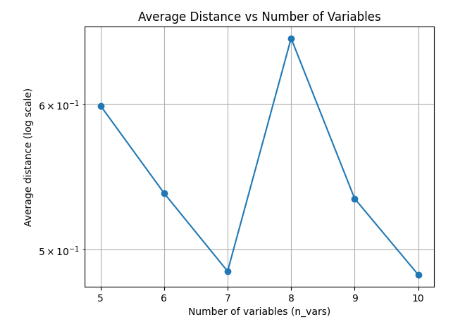

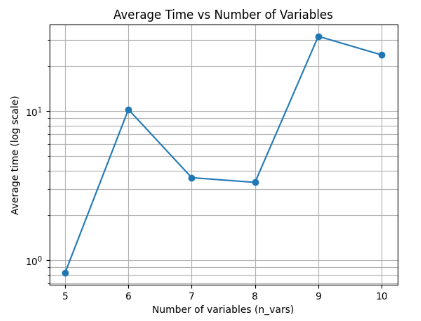

In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [5, 10, 15, 20]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_Ahat_exp = []
    dist_L1_Ades_exp = []
    delta_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n=n_vars,
                m=3,
                integer_vars_idx=random.sample(range(n_vars), 2),
                seed=42 + i,
                A_branch= 3
            )

            A_mat = instance["A_mat"]
            D_mat = instance["D_mat"]          # 👈 A_deseado
            b_vec = instance["b_vec"]
            c = instance["c"]

            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]

            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            A_branch_idx = instance["A_branch_idx"]

            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]

            # --------------------------------------------------
            # Sanity check factibilidad (LP continuo)
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(n_vars),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                tiempos_exp.append(np.nan)
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            # --------------------------------------------------
            # Solver Branch-and-Sandwich (A-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=10000,
                verbose=False
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # ----------------------------------------------
                # Norma L1 restringida a entradas branched
                # ----------------------------------------------
                d_Ahat = sum(
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                d_Ades = sum(
                    abs(D_mat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                dist_L1_Ahat_exp.append(d_Ahat)
                dist_L1_Ades_exp.append(d_Ades)
                delta_L1_exp.append(d_Ahat - d_Ades)

                gaps_exp.append(getattr(solution, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_Ahat_exp.append(np.nan)
            dist_L1_Ades_exp.append(np.nan)
            delta_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_A_hat_to_A_original": np.nanmean(dist_L1_Ahat_exp),
        "L1_dist_A_deseado_to_A_original": np.nanmean(dist_L1_Ades_exp),
        "delta_L1_hat_minus_deseado": np.nanmean(delta_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)


In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [25, 30, 35, 40]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_Ahat_exp = []
    dist_L1_Ades_exp = []
    delta_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n=n_vars,
                m= 3,
                integer_vars_idx=random.sample(range(n_vars), 2),
                seed=42 + i,
                A_branch= 3
            )

            A_mat = instance["A_mat"]
            D_mat = instance["D_mat"]          # 👈 A_deseado
            b_vec = instance["b_vec"]
            c = instance["c"]

            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]

            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            A_branch_idx = instance["A_branch_idx"]

            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]

            # --------------------------------------------------
            # Sanity check factibilidad (LP continuo)
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(n_vars),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                tiempos_exp.append(np.nan)
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            # --------------------------------------------------
            # Solver Branch-and-Sandwich (A-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=12000,
                verbose=False
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # ----------------------------------------------
                # Norma L1 restringida a entradas branched
                # ----------------------------------------------
                d_Ahat = sum(
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                d_Ades = sum(
                    abs(D_mat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                dist_L1_Ahat_exp.append(d_Ahat)
                dist_L1_Ades_exp.append(d_Ades)
                delta_L1_exp.append(d_Ahat - d_Ades)

                gaps_exp.append(getattr(solution, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_Ahat_exp.append(np.nan)
            dist_L1_Ades_exp.append(np.nan)
            delta_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_A_hat_to_A_original": np.nanmean(dist_L1_Ahat_exp),
        "L1_dist_A_deseado_to_A_original": np.nanmean(dist_L1_Ades_exp),
        "delta_L1_hat_minus_deseado": np.nanmean(delta_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)

In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = [45, 50]
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_Ahat_exp = []
    dist_L1_Ades_exp = []
    delta_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n=n_vars,
                m= 3,
                integer_vars_idx=random.sample(range(n_vars), 2),
                seed=42 + i,
                A_branch= 3
            )

            A_mat = instance["A_mat"]
            D_mat = instance["D_mat"]          # 👈 A_deseado
            b_vec = instance["b_vec"]
            c = instance["c"]

            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]

            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            A_branch_idx = instance["A_branch_idx"]

            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]

            # --------------------------------------------------
            # Sanity check factibilidad (LP continuo)
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(n_vars),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                tiempos_exp.append(np.nan)
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            # --------------------------------------------------
            # Solver Branch-and-Sandwich (A-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=8000,
                verbose=False
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # ----------------------------------------------
                # Norma L1 restringida a entradas branched
                # ----------------------------------------------
                d_Ahat = sum(
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                d_Ades = sum(
                    abs(D_mat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                dist_L1_Ahat_exp.append(d_Ahat)
                dist_L1_Ades_exp.append(d_Ades)
                delta_L1_exp.append(d_Ahat - d_Ades)

                gaps_exp.append(getattr(solution, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_Ahat_exp.append(np.nan)
            dist_L1_Ades_exp.append(np.nan)
            delta_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_A_hat_to_A_original": np.nanmean(dist_L1_Ahat_exp),
        "L1_dist_A_deseado_to_A_original": np.nanmean(dist_L1_Ades_exp),
        "delta_L1_hat_minus_deseado": np.nanmean(delta_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)

In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = range (1,6)
N_iter = 10
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_Ahat_exp = []
    dist_L1_Ades_exp = []
    delta_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n= 10,
                m= 3,
                integer_vars_idx=random.sample(range(10), 2),
                seed=42 + i,
                A_branch= n_vars
            )

            A_mat = instance["A_mat"]
            D_mat = instance["D_mat"]          # 👈 A_deseado
            b_vec = instance["b_vec"]
            c = instance["c"]

            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]

            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            A_branch_idx = instance["A_branch_idx"]

            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]

            # --------------------------------------------------
            # Sanity check factibilidad (LP continuo)
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(10),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                tiempos_exp.append(np.nan)
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            # --------------------------------------------------
            # Solver Branch-and-Sandwich (A-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=5000,
                verbose=False
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # ----------------------------------------------
                # Norma L1 restringida a entradas branched
                # ----------------------------------------------
                d_Ahat = sum(
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                d_Ades = sum(
                    abs(D_mat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                dist_L1_Ahat_exp.append(d_Ahat)
                dist_L1_Ades_exp.append(d_Ades)
                delta_L1_exp.append(d_Ahat - d_Ades)

                gaps_exp.append(getattr(solution, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_Ahat_exp.append(np.nan)
            dist_L1_Ades_exp.append(np.nan)
            delta_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_A_hat_to_A_original": np.nanmean(dist_L1_Ahat_exp),
        "L1_dist_A_deseado_to_A_original": np.nanmean(dist_L1_Ades_exp),
        "delta_L1_hat_minus_deseado": np.nanmean(delta_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)

In [ ]:
import time
import numpy as np
import pandas as pd
import random
from scipy.optimize import linprog
import sys

# ============================================================
# Experimentos
# ============================================================
experimentos = range (5,7)
N_iter = 1
resultados = []

# ============================================================
# Loop principal
# ============================================================
for n_vars in experimentos:
    tiempos_exp = []
    dist_L1_Ahat_exp = []
    dist_L1_Ades_exp = []
    delta_L1_exp = []
    gaps_exp = []
    n_success = 0

    print(f"\n▶ Ejecutando experimento con n = {n_vars}")

    for i in range(N_iter):
        # --------------------------------------------------
        # Barra de progreso
        # --------------------------------------------------
        completed = i + 1
        bar = "■" * completed + "□" * (N_iter - completed)
        print(f"\r n = {n_vars} | {bar} | {completed}/{N_iter}", end="")
        sys.stdout.flush()

        start_time = time.time()

        try:
            # --------------------------------------------------
            # Generar instancia
            # --------------------------------------------------
            instance = generate_instance(
                n= 10,
                m= 3,
                integer_vars_idx=random.sample(range(10), 2),
                seed=42 + i,
                A_branch= n_vars
            )

            A_mat = instance["A_mat"]
            D_mat = instance["D_mat"]          # 👈 A_deseado
            b_vec = instance["b_vec"]
            c = instance["c"]

            x_bounds = instance["x_bounds_original"]
            integer_vars = instance["integer_vars"]

            A_lower = instance["A_lower"]
            A_upper = instance["A_upper"]
            A_branch_idx = instance["A_branch_idx"]

            d_vec = instance["d_vec"]
            forward_builder = instance["forward_builder"]
            foil_builder = instance["foil_builder"]

            # --------------------------------------------------
            # Sanity check factibilidad (LP continuo)
            # --------------------------------------------------
            res = linprog(
                c=np.zeros(10),
                A_ub=-A_mat,
                b_ub=-b_vec,
                bounds=x_bounds,
                method="highs"
            )

            if not res.success:
                tiempos_exp.append(np.nan)
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)
                continue

            # --------------------------------------------------
            # Solver Branch-and-Sandwich (A-uncertainty)
            # --------------------------------------------------
            solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=20000,
                verbose=True
            )

            solution = solver.solve()
            elapsed = time.time() - start_time
            tiempos_exp.append(elapsed)

            # --------------------------------------------------
            # Sanity check WCE
            # --------------------------------------------------
            sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )

            if solution.A_hat is not None:
                # ----------------------------------------------
                # Norma L1 restringida a entradas branched
                # ----------------------------------------------
                d_Ahat = sum(
                    abs(solution.A_hat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                d_Ades = sum(
                    abs(D_mat[r, c] - A_mat[r, c])
                    for (r, c) in A_branch_idx
                )

                dist_L1_Ahat_exp.append(d_Ahat)
                dist_L1_Ades_exp.append(d_Ades)
                delta_L1_exp.append(d_Ahat - d_Ades)

                gaps_exp.append(getattr(solution, "gap", np.nan))
                n_success += 1
            else:
                dist_L1_Ahat_exp.append(np.nan)
                dist_L1_Ades_exp.append(np.nan)
                delta_L1_exp.append(np.nan)
                gaps_exp.append(np.nan)

        except Exception as e:
            print(f"\n[n={n_vars}, iter={i+1}] Error:", e)
            tiempos_exp.append(np.nan)
            dist_L1_Ahat_exp.append(np.nan)
            dist_L1_Ades_exp.append(np.nan)
            delta_L1_exp.append(np.nan)
            gaps_exp.append(np.nan)

    print()

    # --------------------------------------------------
    # Resultados agregados
    # --------------------------------------------------
    resultados.append({
        "n_vars": n_vars,
        "n_success": n_success,
        "time_avg": np.nanmean(tiempos_exp),
        "time_var": np.nanvar(tiempos_exp),
        "L1_dist_A_hat_to_A_original": np.nanmean(dist_L1_Ahat_exp),
        "L1_dist_A_deseado_to_A_original": np.nanmean(dist_L1_Ades_exp),
        "delta_L1_hat_minus_deseado": np.nanmean(delta_L1_exp),
        "gap_avg": np.nanmean(gaps_exp),
    })

# ============================================================
# DataFrame final
# ============================================================
df_resultados = pd.DataFrame(resultados)
print("\nResultados finales:")
print(df_resultados)

## Comparación con Big-M

El de Big-M solo funciona para una restricción.

In [ ]:
def solve_master_all_mutable_A_restricted(
    Y,
    a0, b0, c0,
    H_bounds,
    A_free_idx,          # 👈 NUEVO
    D_builder,
    M=1e6,
    output_flag=0
):
    """
    Master del Algoritmo 4
    - c libre
    - b libre
    - a solo libre en A_free_idx
    """

    n = len(c0)

    m = gp.Model("Master_All_Mutable_A_Restricted")
    m.Params.OutputFlag = output_flag
    m.Params.NonConvex = 2

    # ======================
    # Variables
    # ======================
    c = m.addVars(n, lb=H_bounds["c_lb"], ub=H_bounds["c_ub"], name="c")

    a = {}
    for i in range(n):
        if i in A_free_idx:
            a[i] = m.addVar(
                lb=H_bounds["a_lb"][i],
                ub=H_bounds["a_ub"][i],
                name=f"a[{i}]"
            )
        else:
            # a_i fijo
            a[i] = m.addVar(
                lb=a0[i],
                ub=a0[i],
                name=f"a[{i}]"
            )

    b = m.addVar(lb=H_bounds["b_lb"], ub=H_bounds["b_ub"], name="b")

    # x̂ ∈ D ∩ X
    x = D_builder(m)

    # z_y ∈ {0,1}
    z = {
        k: m.addVar(vtype=GRB.BINARY, name=f"z[{k}]")
        for k in range(len(Y))
    }

    # ======================
    # Restricción: âᵀ x̂ ≥ b̂
    # ======================
    m.addConstr(
        gp.quicksum(a[i] * x[i] for i in range(n)) >= b,
        name="feas_xhat"
    )

    # ======================
    # Cortes (10a)–(10c)
    # ======================
    for k, y in enumerate(Y):

        # (10a) optimalidad
        m.addConstr(
            gp.quicksum(c[i] * x[i] for i in range(n))
            <= gp.quicksum(c[i] * y[i] for i in range(n)) + M * z[k],
            name=f"opt_cut[{k}]"
        )

        # (10b) factibilidad lower
        m.addConstr(
            gp.quicksum(a[i] * y[i] for i in range(n)) >= b - M * z[k],
            name=f"feas_cut_lb[{k}]"
        )

        # (10c) factibilidad upper
        m.addConstr(
            gp.quicksum(a[i] * y[i] for i in range(n))
            <= b - 1 + M * (1 - z[k]),
            name=f"feas_cut_ub[{k}]"
        )

    # ======================
    # Métrica δ = L1 (solo en índices libres de A)
    # ======================
    abs_terms = []

    # c
    for i in range(n):
        t = m.addVar(lb=0.0)
        m.addConstr(t >= c[i] - c0[i])
        m.addConstr(t >= -(c[i] - c0[i]))
        abs_terms.append(t)

    # a (solo A_free_idx)
    for i in A_free_idx:
        t = m.addVar(lb=0.0)
        m.addConstr(t >= a[i] - a0[i])
        m.addConstr(t >= -(a[i] - a0[i]))
        abs_terms.append(t)

    # b
    tb = m.addVar(lb=0.0)
    m.addConstr(tb >= b - b0)
    m.addConstr(tb >= -(b - b0))
    abs_terms.append(tb)

    m.setObjective(gp.quicksum(abs_terms), GRB.MINIMIZE)
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        return None

    return {
        "a": np.array([a[i].X for i in range(n)]),
        "b": b.X,
        "c": np.array([c[i].X for i in range(n)]),
        "x": np.array([x[i].X for i in range(n)]),
        "delta": m.ObjVal
    }


In [ ]:
def solve_separation_all_mutable(a_hat, b_hat, c_hat, X_builder, output_flag=0):
    """
    min_y ĉᵀ y
    s.t. âᵀ y ≥ b̂
         y ∈ X
    """

    n = len(c_hat)

    m = gp.Model("Separation")
    m.Params.OutputFlag = output_flag

    y = X_builder(m)

    m.addConstr(
        gp.quicksum(a_hat[i] * y[i] for i in range(n)) >= b_hat
    )

    m.setObjective(
        gp.quicksum(c_hat[i] * y[i] for i in range(n)),
        GRB.MINIMIZE
    )

    m.optimize()

    if m.Status != GRB.OPTIMAL:
        return None, None

    return np.array([y[i].X for i in range(n)]), m.ObjVal



In [ ]:
def algorithm4_all_mutable_A_restricted(
    a0, b0, c0,
    A_free_idx,
    X_builder,
    D_builder,
    H_bounds,
    tol=1e-6,
    max_iter=100,
    output_flag=0
):
    Y = []
    optimal = False
    it = 0

    while not optimal and it < max_iter:
        it += 1

        sol = solve_master_all_mutable_A_restricted(
            Y=Y,
            a0=a0,
            b0=b0,
            c0=c0,
            H_bounds=H_bounds,
            A_free_idx=A_free_idx,
            D_builder=D_builder,
            output_flag=output_flag
        )

        if sol is None:
            return {"status": "MASTER_INFEASIBLE"}

        a_hat = sol["a"]
        b_hat = sol["b"]
        c_hat = sol["c"]
        x_hat = sol["x"]

        # Separation
        y_hat, val_y = solve_separation_all_mutable(
            a_hat, b_hat, c_hat,
            X_builder,
            output_flag=output_flag
        )

        val_x = float(np.dot(c_hat, x_hat))

        if val_y is not None and val_y < val_x - tol:
            Y.append(y_hat)
        else:
            optimal = True

    return {
        "status": "OPTIMAL",
        "a_hat": a_hat,
        "b_hat": b_hat,
        "c_hat": c_hat,
        "x_hat": x_hat,
        "iterations": it,
        "cuts": len(Y)
    }



In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# =========================================================
# 1. Generar instancia: UNA restricción, TODO A movible
# =========================================================
n = 10

inst = generate_instance(
    n=n,
    m=1,                    # 👈 UNA sola restricción
    A_branch=n,             # 👈 TODAS las entradas de A se mueven
    x_bounds=(0.0, 5.0),
    integer_vars_idx=list(range(n)),  # opcional
    A_bounds=(0.5, 3.0),
    seed=123
)

# ---------------------------------------------------------
# Extraer datos
# ---------------------------------------------------------
A_mat = inst["A_mat"]       # shape (1, n)
b_vec = inst["b_vec"]       # shape (1,)
c0 = inst["c"]

a0 = A_mat[0, :].copy()     # 👈 vector a original
b0 = float(b_vec[0])

A_lower = inst["A_lower"][0, :]
A_upper = inst["A_upper"][0, :]

x_bounds = inst["x_bounds_original"]
integer_vars = inst["integer_vars"]
# ---------------------------------------------------------
# Índices de A que pueden moverse (solo columnas)
# ---------------------------------------------------------
A_free_idx = sorted({j for (i, j) in inst["A_branch_idx"]})

# =========================================================
# 2. Definir H_bounds (Big-M domain)
# =========================================================
H_bounds = {
    "a_lb": A_lower,
    "a_ub": A_upper,
    "b_lb": b0 - 5.0,
    "b_ub": b0 + 5.0,
    "c_lb": c0 - 10.0,
    "c_ub": c0 + 10.0
}

# =========================================================
# 3. Builders para X y D
# =========================================================
def X_builder(model):
    x = [
        model.addVar(
            lb=x_bounds[i][0],
            ub=x_bounds[i][1],
            vtype=GRB.INTEGER if i in integer_vars else GRB.CONTINUOUS,
            name=f"x[{i}]"
        )
        for i in range(n)
    ]
    return x


def D_builder(model):
    # En este ejemplo: D = X (sin restricciones extra)
    return X_builder(model)

# =========================================================
# 4. Ejecutar Algoritmo 4 (A mutable con Big-M)
# =========================================================
res = algorithm4_all_mutable_A_restricted(
    a0=a0,
    b0=b0,
    c0=c0,
    A_free_idx=A_free_idx,   # 👈 ESTO FALTABA
    X_builder=X_builder,
    D_builder=D_builder,
    H_bounds=H_bounds,
    tol=1e-6,
    max_iter=100,
    output_flag=0
)

print("\n=== RESULTADO ===")
print("Status:", res["status"])
print("Iteraciones:", res["iterations"])
print("Cortes agregados:", res["cuts"])
print("a_hat:", res["a_hat"])
print("b_hat:", res["b_hat"])
print("c_hat:", res["c_hat"])
print("x_hat:", res["x_hat"])


A_mat = instance["A_mat"]
D_mat = instance["D_mat"]          # 👈 A_deseado
b_vec = instance["b_vec"]
c = instance["c"]

x_bounds = instance["x_bounds_original"]
integer_vars = instance["integer_vars"]

A_lower = instance["A_lower"]
A_upper = instance["A_upper"]
A_branch_idx = instance["A_branch_idx"]

d_vec = instance["d_vec"]
forward_builder = instance["forward_builder"]
foil_builder = instance["foil_builder"]


solver = FullBranchAndSandwichSolver_for_A_restricted(
                A=A_mat,
                b=b_vec,
                c=c,
                x_bounds=x_bounds,
                integer_vars=integer_vars,
                A_bounds=(A_lower, A_upper),
                D_mat=D_mat,
                d_vec=d_vec,
                forward_builder=forward_builder,
                foil_builder=foil_builder,
                A_branch_idx=A_branch_idx,
                epsilon_obj=1e-6,
                epsilon_f=1e-6,
                epsilon_A=1e-3,
                max_iterations=20000,
                verbose=False
            )

solution = solver.solve()
sanity_check_WCE_A(
                A_hat=solution.A_hat,
                solver=solver,
                tol=1e-6
            )
print (solution)
